Longtime readers will know I have an interest in using Bayesian [item response theory](https://en.wikipedia.org/wiki/Item_response_theory) (IRT) to model athlete skill in various situations:

1. NBA foul calls ([2017](https://austinrochford.com/posts/2017-04-04-nba-irt.html), [2018](https://austinrochford.com/posts/2018-02-04-nba-irt-2.html)) and
2. fights in the NHL ([2025](https://austinrochford.com/posts/irt-hockey.html)).

This post is the first in a series where we will apply Bayesian IRT models to placekicker skill in the NFL.  In this post, we will build a model of the non-player factors impacting the probability a field goal is made.  In a subsequent post, we will add kicker skill to this model.

Before we begin analyzing the data, we make the necessary Python imports and do some light configuration.

In [1]:
%matplotlib inline

In [2]:
import logging

from humanize import intword
from toolz import compose

In [3]:
import arviz as az
import numpy as np
import nutpie
import polars as pl
import preliz as pz
import pymc as pm
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import ticker
from pymc_extras.utils.spline import numpy_bspline_basis
from seaborn import objects as so
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler

In [4]:
import nflreadpy as nfl

In [5]:
sns.set(color_codes=True)

In [6]:
logging.getLogger("pytensor.graph.rewriting.basic").setLevel(logging.CRITICAL)

In [7]:
nfl.config.update_config(cache_mode="filesystem")

## Exploratory data analysis

### Load the data

We begin by loading NFL play-by-play data as a [Polars](https://pola.rs/) DataFrame using [nflreadpy](https://nflreadpy.nflverse.com/).

In [8]:
pbp_df = nfl.load_pbp(seasons=True)

We see that this data has over a million rows and a bit under four hundred columns.

In [9]:
print(f"{intword(pbp_df.shape[0])} x {pbp_df.shape[1]}")

1.3 million x 372


For documentation of each column's meaning, refer to nflverse's [data dictionary](https://nflreadr.nflverse.com/articles/dictionary_pbp.html).

### Unblocked field goals

Before exploring the non-player factors impacting field goal success, we reduce the data set to rows corresponding to field goal attempts.  We also reduce the number of columns to the twenty-four most relevant to modeling field goal success in this post and the next.

In [10]:
FG_COLS = [
    "play_id",
    "game_id",
    "home_team",
    "away_team",
    "season_type",
    "week",
    "posteam",
    "defteam",
    "half_seconds_remaining",
    "game_seconds_remaining",
    "game_half",
    "qtr",
    "field_goal_result",
    "kicker_player_name",
    "kicker_player_id",
    "kick_distance",
    "score_differential",
    "season",
    "weather",
    "roof",
    "surface",
    "temp",
    "wind",
    "game_stadium",
]

In [11]:
fg_df = pbp_df.filter(pl.col("field_goal_attempt") == 1).select(FG_COLS)

In [12]:
PCT_FORMATTER = lambda: ticker.PercentFormatter(xmax=1, decimals=1)
PCT_LIMIT = (0, 1.05)
PCT_LOCATOR = lambda: ticker.MultipleLocator(0.25)

We see that very few field goals are blocked, so we exclude these from our analysis.

In [13]:
MADE_LABEL = "Field goals made"

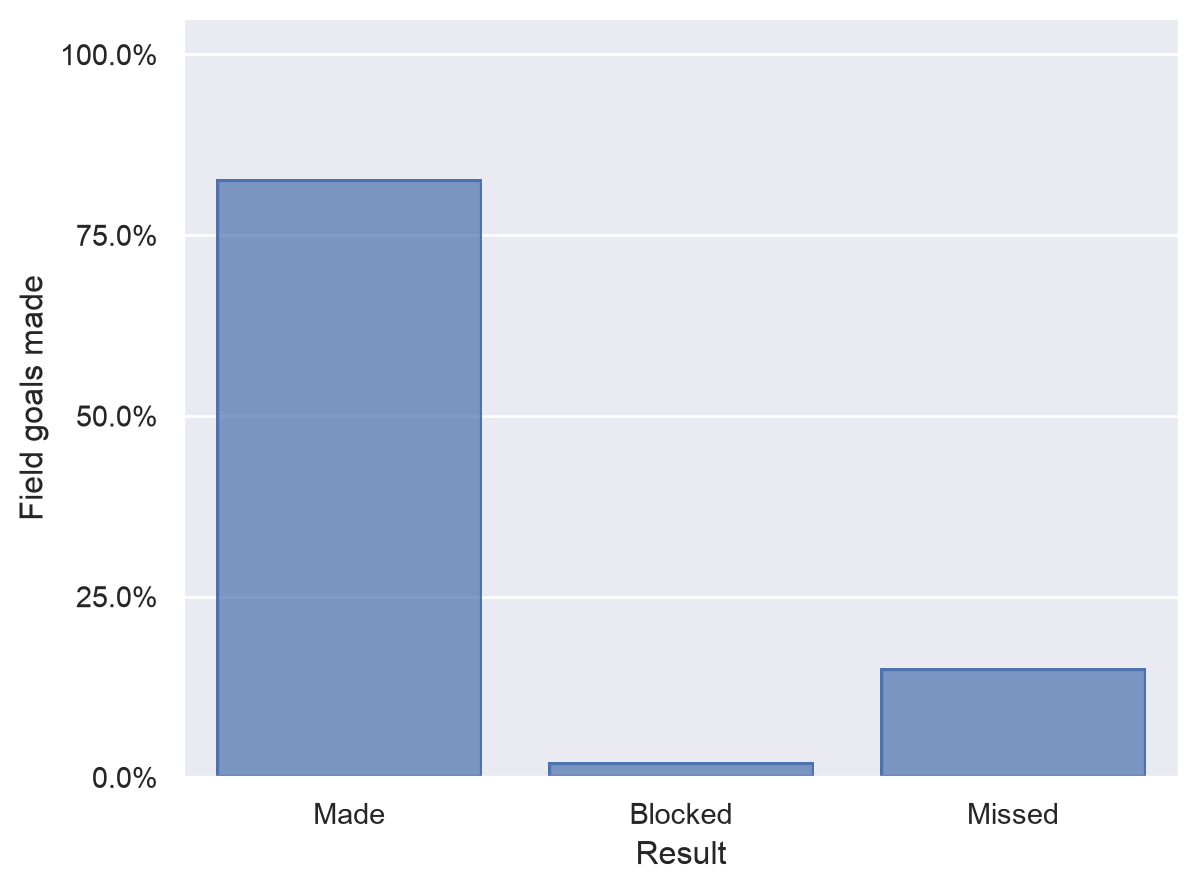

In [14]:
(
    so.Plot(
        fg_df.with_columns(pl.col("field_goal_result").str.to_titlecase()).rename(
            {"field_goal_result": "Result"}
        ),
        x="Result",
    )
    .add(so.Bar(), so.Hist(stat="probability"))
    .scale(
        y=so.Continuous().tick(locator=PCT_LOCATOR()).label(formatter=PCT_FORMATTER())
    )
    .label(y=MADE_LABEL)
    .limit(y=PCT_LIMIT)
)

In [15]:
fg_df = fg_df.filter(pl.col("field_goal_result") != "blocked").with_columns(
    made=pl.col("field_goal_result") == "made"
)

Doing so leaves us with about 27,000 field goals spanning the 1999-2025 NFL seasons.

In [16]:
print(intword(fg_df.shape[0]))

27.2 thousand


In [17]:
fg_df.select(
    pl.col("season").min().alias("first"), pl.col("season").max().alias("last")
)

first,last
i32,i32
1999,2025


### Distance

We begin our exploration of the factors that impact field goal success with the most obvious, distance.  To facilitate visualization, we group field goal attempts into equally-sized bins, then we plot the success rate within each bin (after smoothing a bit by taking the rolling mean across nearby bins).

In [18]:
fg_df = (
    fg_df.with_columns(
        q=pl.col("kick_distance").qcut(30, allow_duplicates=True, include_breaks=True),
    )
    .unnest("q")
    .drop("category")
    .rename({"breakpoint": "bin_max"})
    .with_columns(
        bin_mean=pl.col("kick_distance").mean().over("bin_max").cast(pl.Int64)
    )
)

In [19]:
def ensure_list(maybe_list):
    return maybe_list if isinstance(maybe_list, list) else [maybe_list]


def rolling_mean_by(df, *, name, by, window_size, over=None):
    # centered, row-based window; `by` values are near-evenly spaced
    # (bin_mean, season) so this approximates a centered window over them,
    # avoiding the ~window_size/2 lag a trailing window introduces
    expr = pl.col(name).rolling_mean(window_size, center=True, min_samples=1)
    sort_by = [by]

    if over is not None:
        over = ensure_list(over)
        expr = expr.over(over)
        sort_by += over

    return df.sort(sort_by).with_columns(expr)

In [20]:
DIST_MAJOR_LOCATOR = lambda: ticker.MultipleLocator(5)

In [21]:
DIST_LABEL = "Distance (yards)"

In [22]:
def plot_made_by_dist(df, *, color, color_label, title=None, order=None):
    color_scale = so.Nominal(order=order) if order else so.Nominal()

    return (
        so.Plot(
            df.group_by(color, "bin_mean")
            .agg(pl.col("made").mean())
            .pipe(
                rolling_mean_by, name="made", by="bin_mean", window_size=5, over=color
            ),
            x="bin_mean",
            y="made",
            color=color,
        )
        .add(so.Line())
        .scale(
            x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()),
            y=so.Continuous()
            .tick(locator=PCT_LOCATOR())
            .label(formatter=PCT_FORMATTER()),
            color=color_scale,
        )
        .label(x=DIST_LABEL, y=MADE_LABEL, color=color_label, title=title)
    )

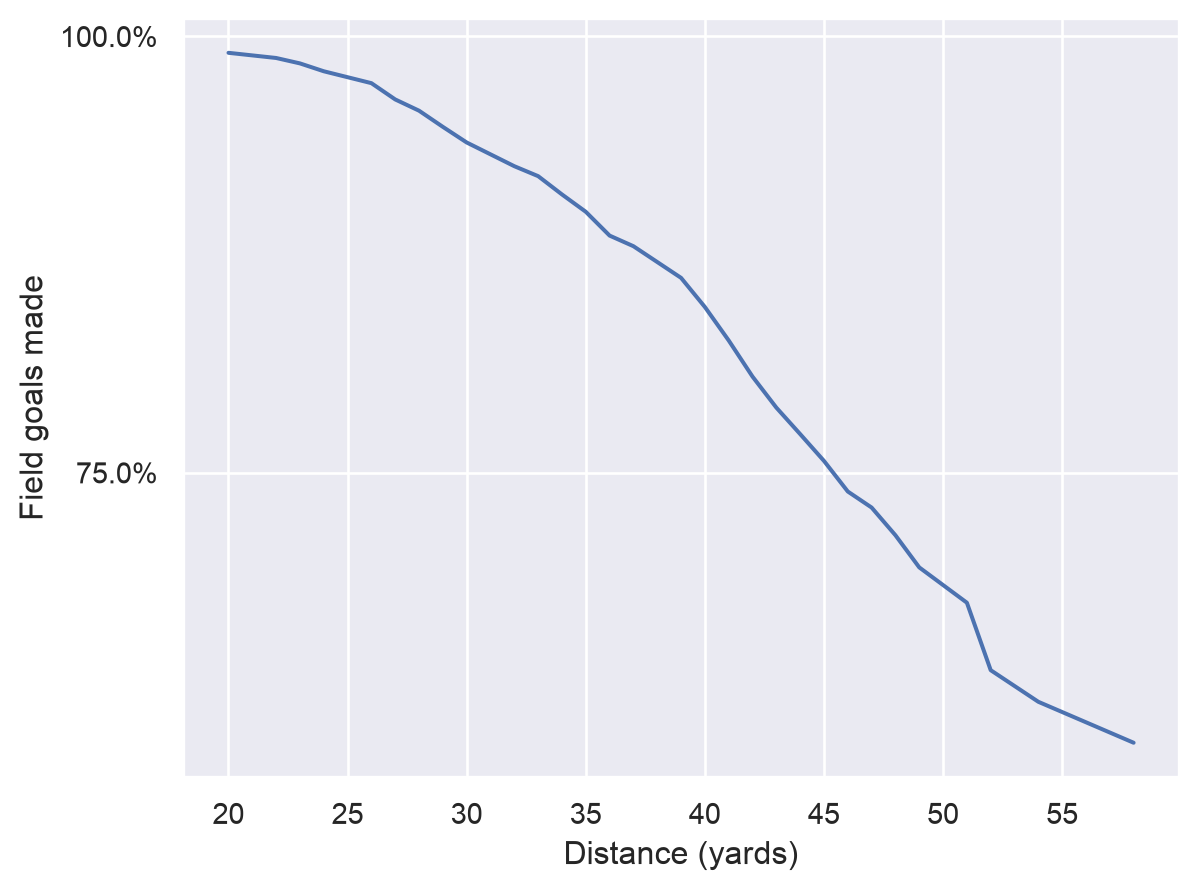

In [23]:
(
    so.Plot(
        fg_df.group_by("bin_mean")
        .agg(pl.col("made").mean())
        .pipe(rolling_mean_by, name="made", by="bin_mean", window_size=5),
        x="bin_mean",
        y="made",
    )
    .add(so.Line())
    .scale(
        x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()),
        y=so.Continuous().tick(locator=PCT_LOCATOR()).label(formatter=PCT_FORMATTER()),
    )
    .label(x=DIST_LABEL, y=MADE_LABEL)
)

We see the expected pattern, that longer field goals have lower success rates.

### Season

Certainly the average skill of NFL players has increased over time.  Below we visualize how this increase has impacted field goal success across seasons.

In [24]:
THRESHES = [0.5, 0.75, 0.9]

In [25]:
SEASON_LABEL = "Season"
SEASON_MAJOR_LOCATOR = lambda: ticker.MultipleLocator(5)

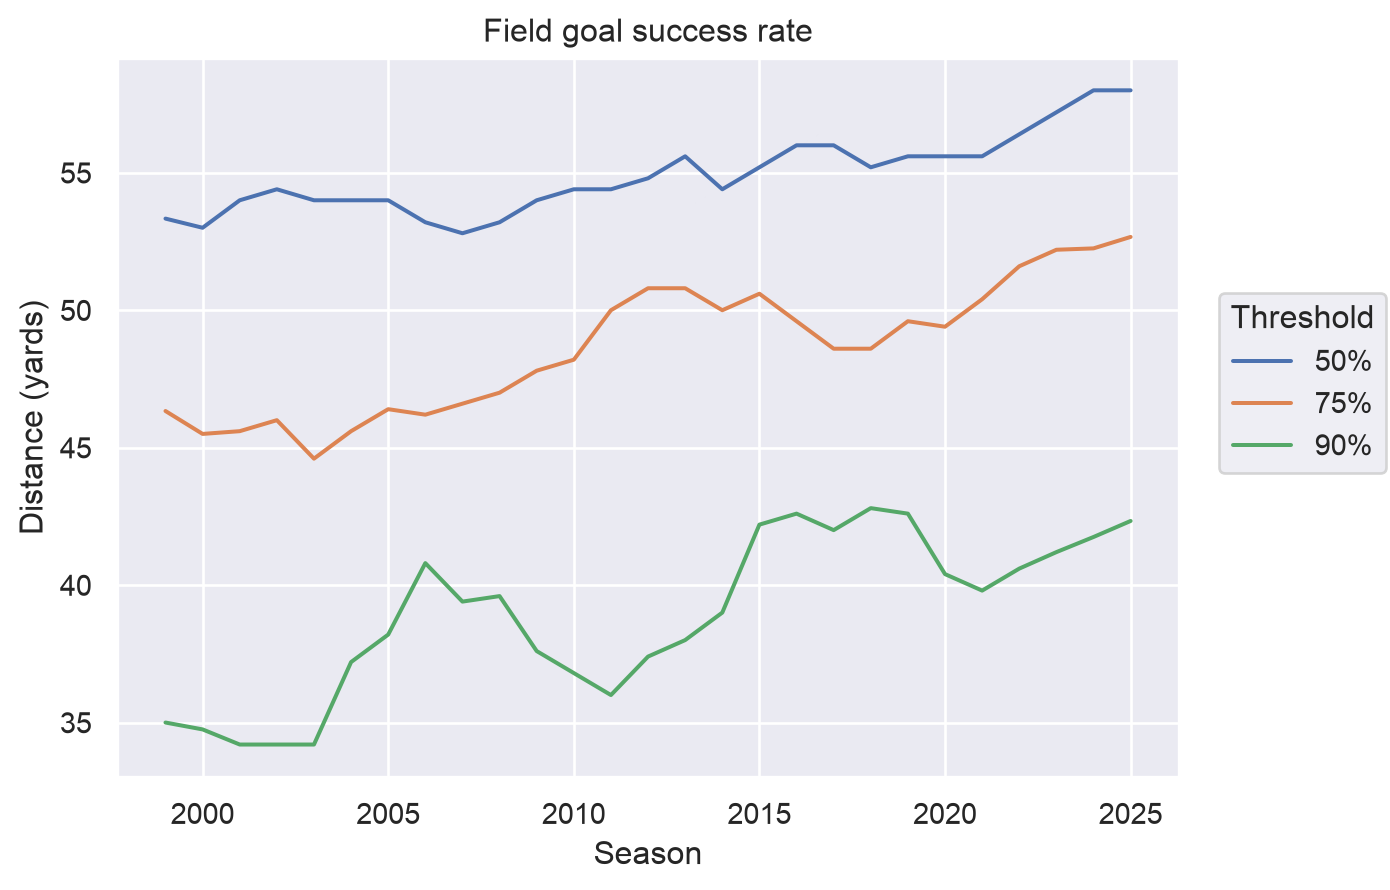

In [26]:
(
    so.Plot(
        fg_df.group_by("bin_mean", "season")
        .agg(pl.col("made").mean())
        .join(pl.DataFrame({"thresh": THRESHES}), how="cross")
        .filter(pl.col("made") >= pl.col("thresh"))
        .group_by("season", "thresh")
        .agg(pl.col("bin_mean").max())
        .pipe(
            rolling_mean_by, name="bin_mean", by="season", window_size=5, over="thresh"
        )
        .with_columns(
            pl.col("thresh").map_elements(lambda x: f"{x:.0%}", return_dtype=pl.String),
        ),
        x="season",
        y="bin_mean",
        color="thresh",
    )
    .add(so.Line())
    .scale(
        x=so.Continuous().tick(locator=SEASON_MAJOR_LOCATOR()),
        y=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()),
        color=so.Nominal(),
    )
    .label(
        x=SEASON_LABEL, y=DIST_LABEL, color="Threshold", title="Field goal success rate"
    )
)

Each line in this chart represents the distance at which NFL placekickers exceed the given threshold for field goal success across the seasons in our data.  We see that each threshold's distance has grown over the years, so accounting for season in our model will be important.

### Stadium exposure

One of the most important factors impacting kick success is obviously the weather (wind, rain, snow, etc.).

In [27]:
fg_df["wind", "weather"]

wind,weather
i32,str
3,null
3,null
3,null
3,null
3,null
…,…
7,"""Temp: 67° F, Humidity: 50%, Wi…"
7,"""Temp: 67° F, Humidity: 50%, Wi…"
7,"""Temp: 67° F, Humidity: 50%, Wi…"


Unfortunately, the data we get on wind does not indicate direction relative to the attempted kick, so we cannot include this factor in our models.  We can, however, include whether the game is exposed to the weather or not (in a dome with a closed roof).

In [28]:
fg_df = fg_df.with_columns(is_exposed=pl.col("roof").is_in(["open", "outdoors"]))

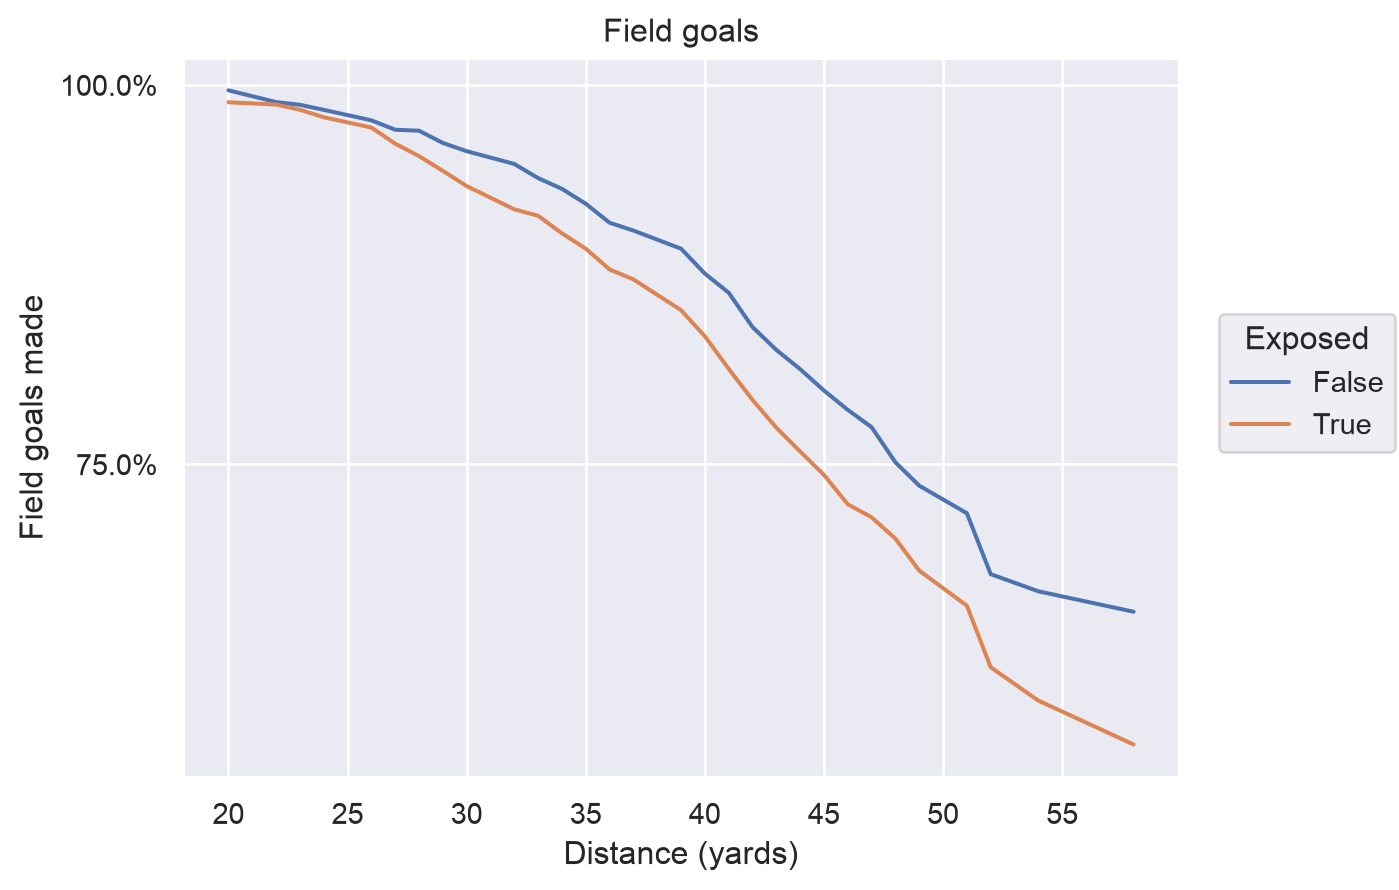

In [29]:
plot_made_by_dist(fg_df, color="is_exposed", color_label="Exposed", title="Field goals")

We see that, outside of fairly short kicks of less than 30 yards, exposure to the elements seems to make a difference, so we will include this in our models.

### Field surface

Another factor about the stadium that may impact kick success is the type of surface the game is played on.  We first reduce the many surfaces present in the data to a binary distinction, whether or not the game is being played on artificial turf.  We also drop a very small number of attempts on unknown surface.

In [30]:
fg_df["surface"].value_counts()

surface,count
str,u32
"""dessograss""",197
"""astroplay""",453
"""astroturf""",1851
"""a_turf""",380
"""""",181
"""grass""",14945
"""grass """,326
"""fieldturf""",6686
"""sportturf""",1307


In [31]:
fg_df = (
    fg_df.with_columns(
        surface=pl.col("surface").str.strip_chars().replace("", None),
    )
    .drop_nulls("surface")
    .with_columns(is_turf=~pl.col("surface").is_in(["grass", "dessograss"]))
)

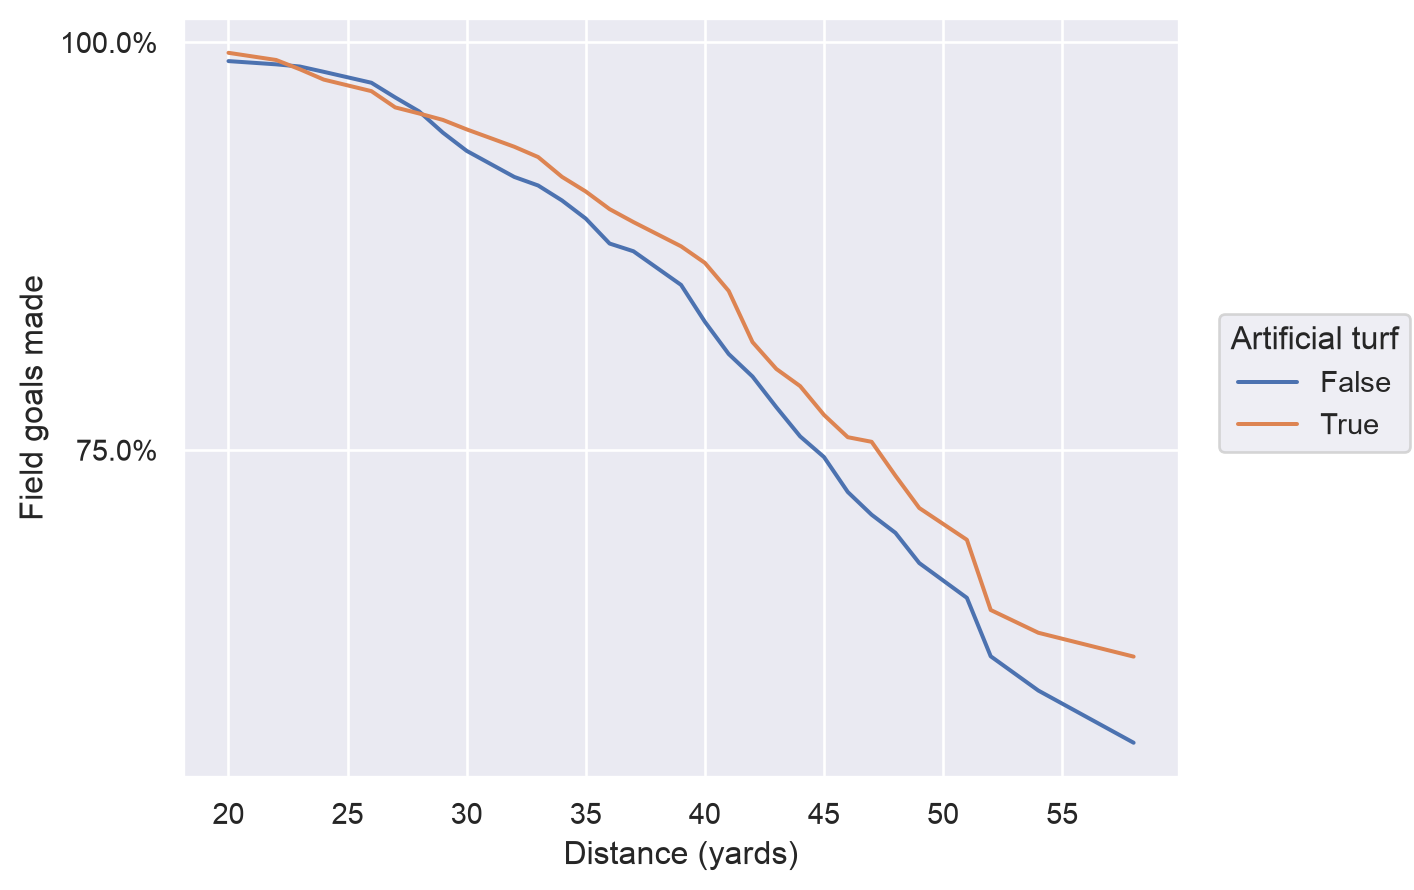

In [32]:
plot_made_by_dist(fg_df, color="is_turf", color_label="Artificial turf")

We see that, above 30 yards, kicks on turf appear to succeed a bit more often than those on grass.  We will include this factor in a model.

### Home field

We now investigate whether or not there is a home field advantage effect on field goal success.

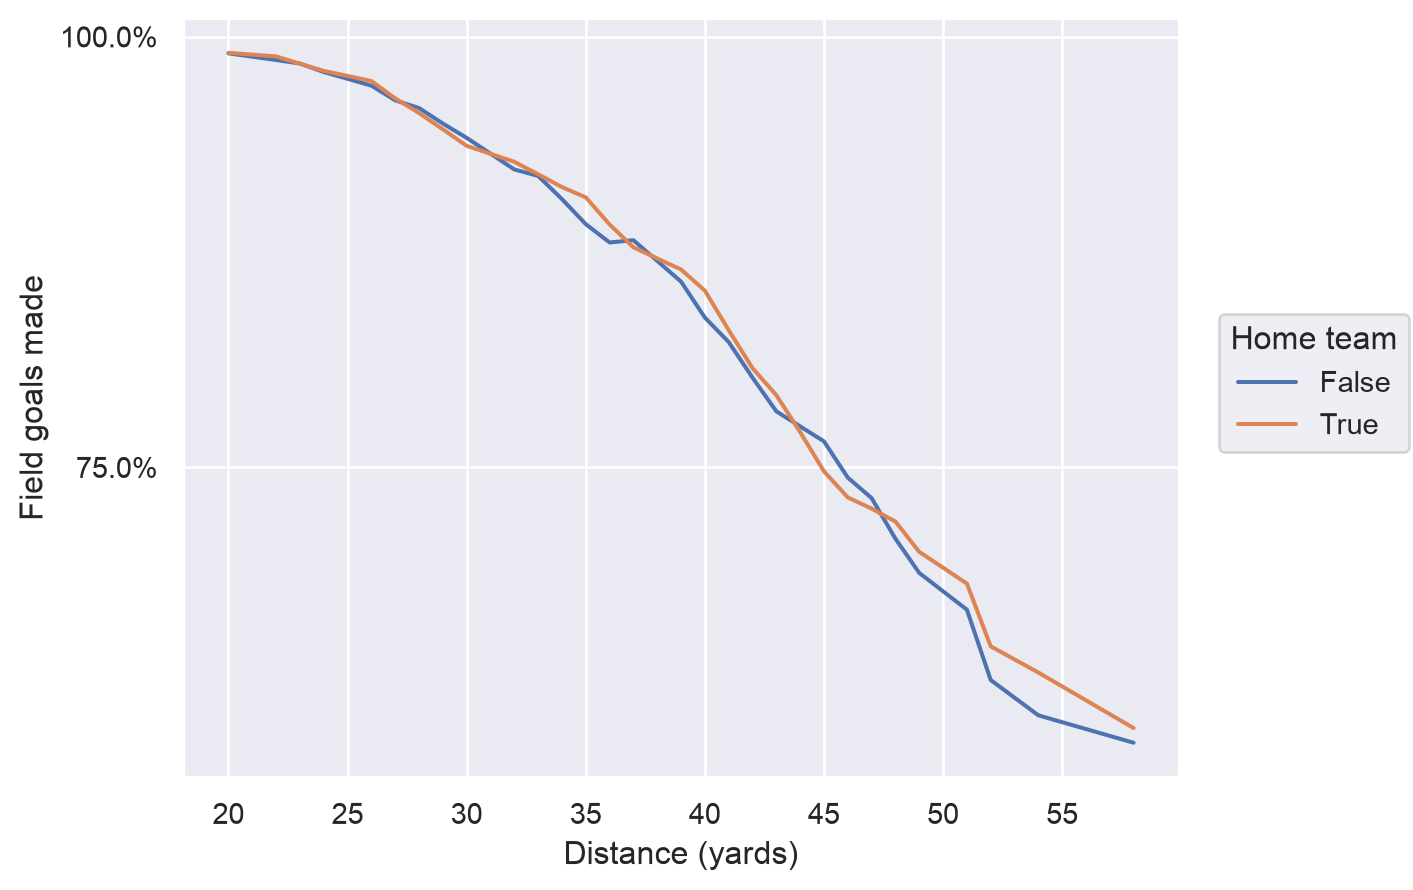

In [33]:
plot_made_by_dist(
    fg_df.with_columns(home_kick=pl.col("home_team") == pl.col("posteam")),
    color="home_kick",
    color_label="Home team",
)

This plot shows no discernible home field advantage.

### Score difference

We now investigate whether or not the score difference in a game impacts field goal success rate.

In [34]:
CLOSE_GAME_MARGIN = 3

fg_df = fg_df.with_columns(
    is_close=pl.col("score_differential").abs() <= CLOSE_GAME_MARGIN,
    score_status=(
        pl.when(pl.col("score_differential") == 0)
        .then(pl.lit("Tied"))
        .when(pl.col("score_differential") > 0)
        .then(pl.lit("Leading"))
        .otherwise(pl.lit("Trailing"))
    ),
)

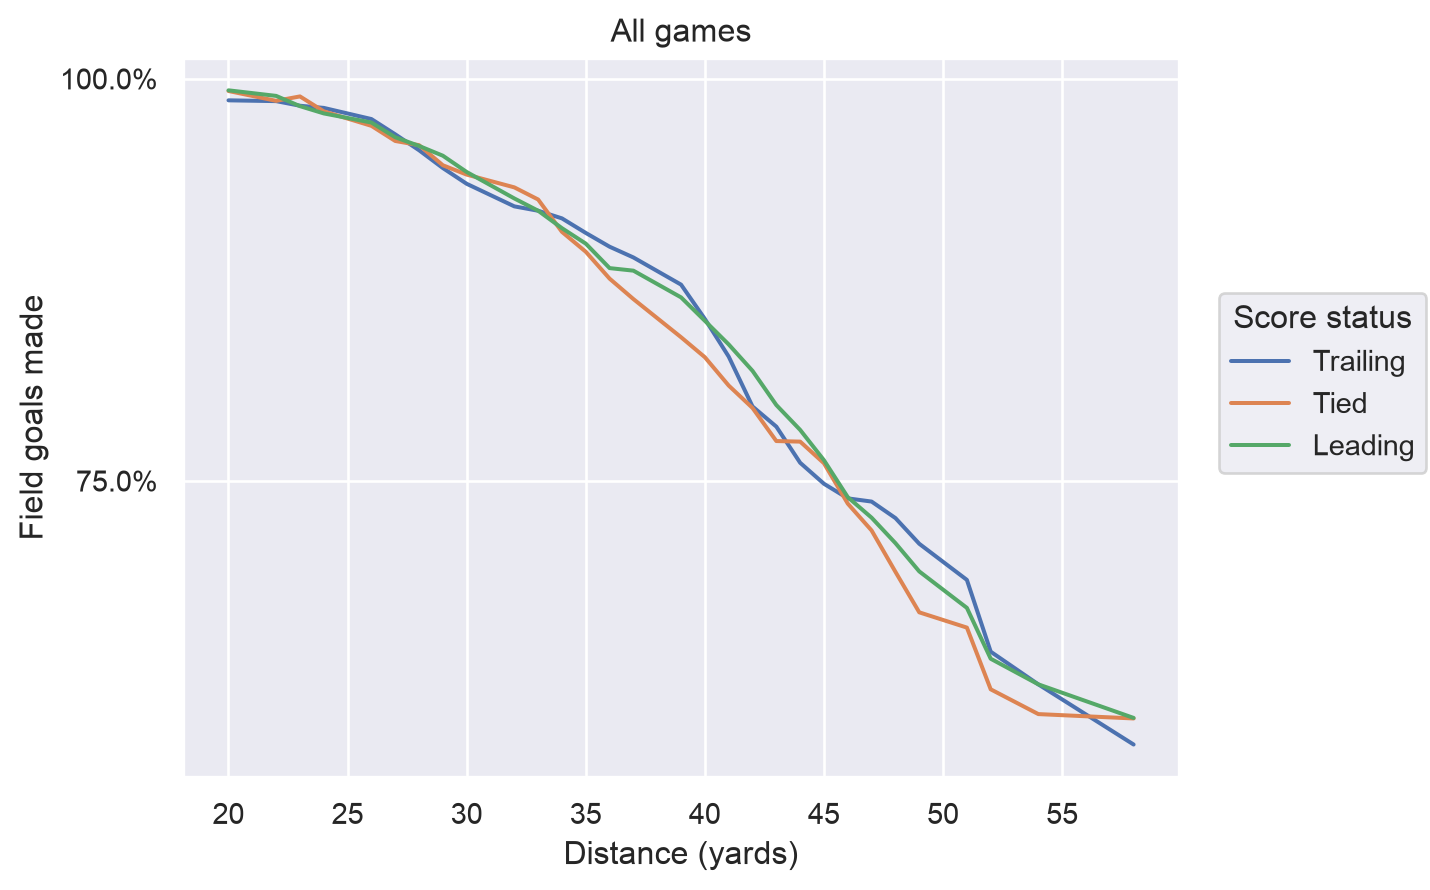

In [35]:
plot_made_by_dist(
    fg_df,
    color="score_status",
    color_label="Score status",
    title="All games",
    order=["Trailing", "Tied", "Leading"],
)

The above plot shows that whether the kicking team is leading, tied, or trailing does not seem to have much of an impact on field goal success.  The following plot shows that this remains the case even when the teams' scores are close, differing by at most a field goal.

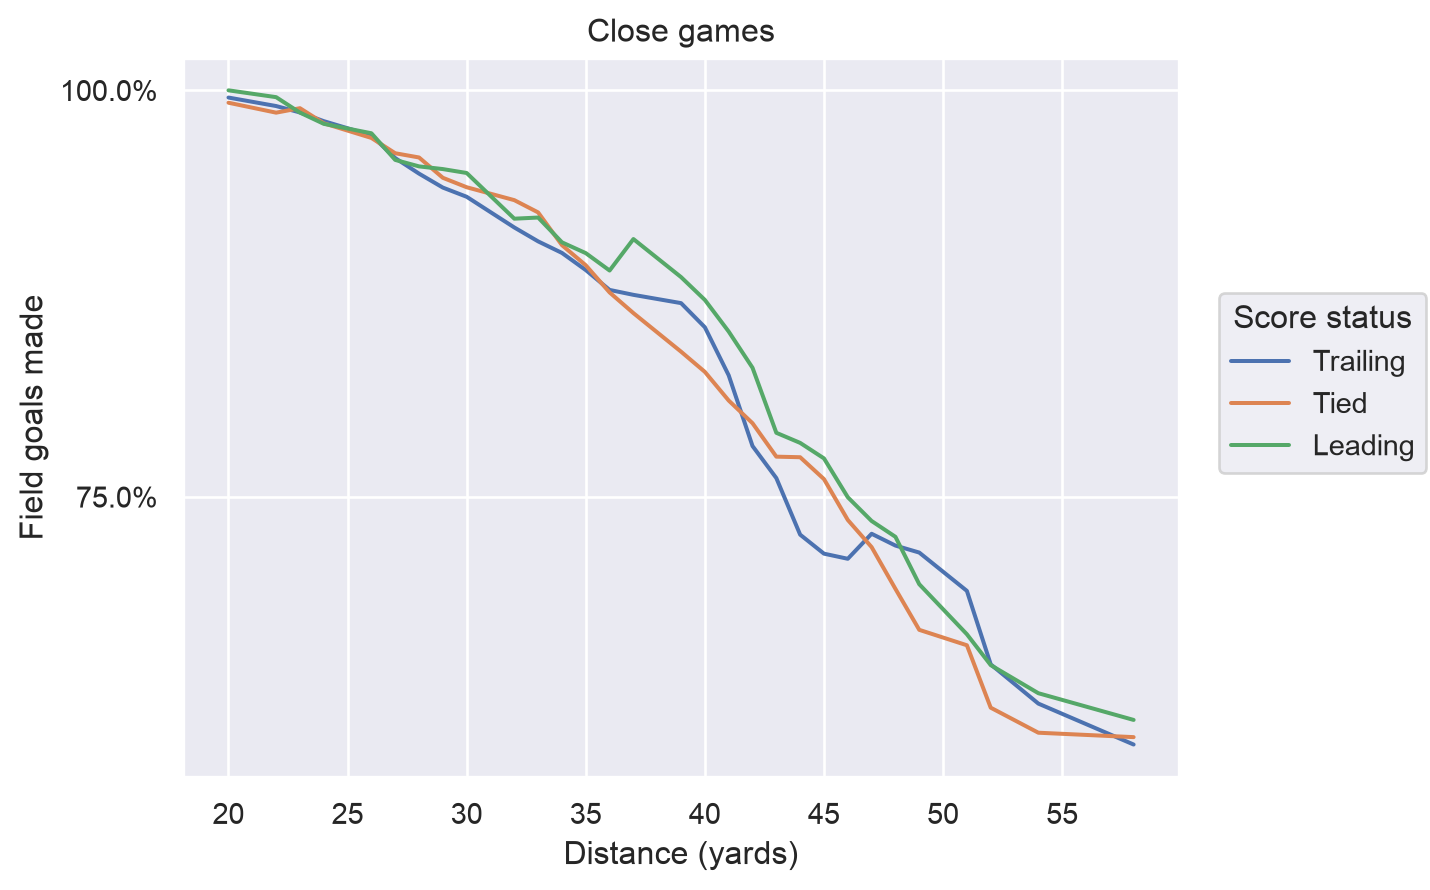

In [36]:
plot_made_by_dist(
    fg_df.filter(pl.col("is_close")),
    color="score_status",
    color_label="Score status",
    title="Close games",
    order=["Trailing", "Tied", "Leading"],
)

We will therefore not include score difference in our model.

### Quarter

The following plot shows that the quarter of the game in which a field goal is attempted does not show a strong influence on its success.  Therefore we will not include it in our models.

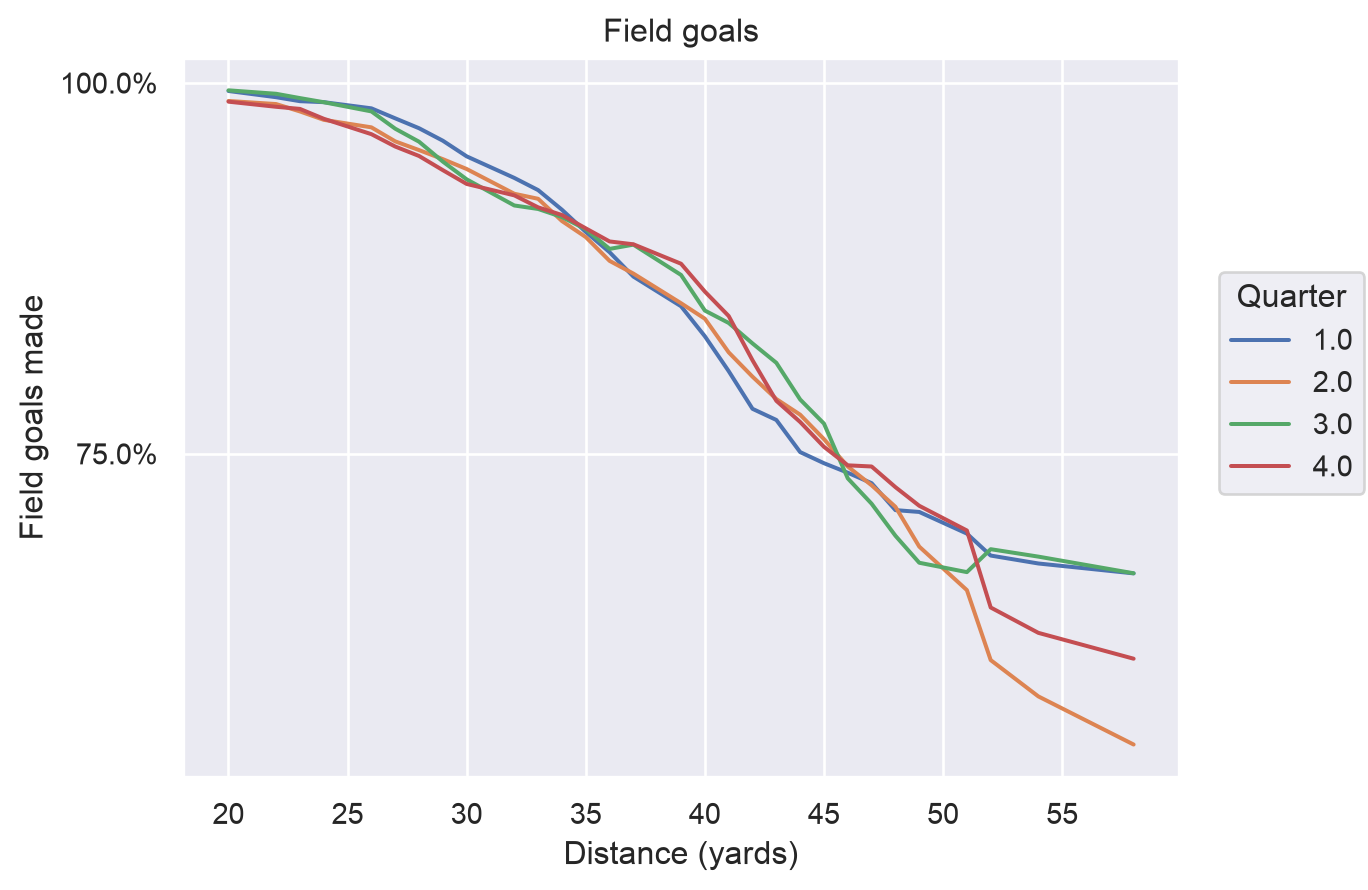

In [37]:
plot_made_by_dist(
    fg_df.filter(pl.col("qtr") <= 4),
    color="qtr",
    color_label="Quarter",
    title="Field goals",
)

### Regular vs. post season

The following plot shows that whether the game is in the regular season or postseason does not strongly influence field goal success. Therefore we will not include it in our models.

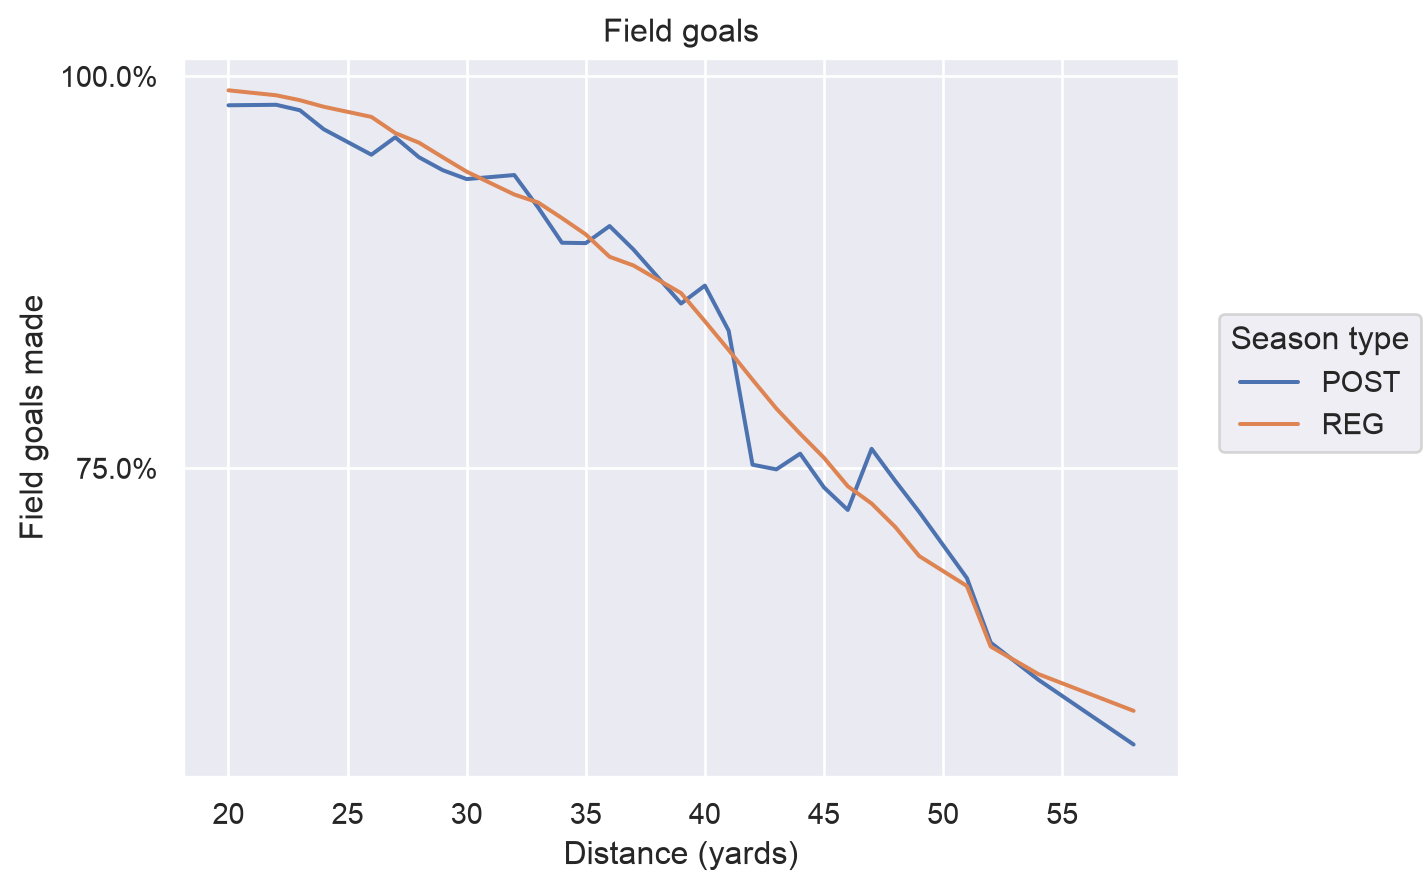

In [38]:
plot_made_by_dist(
    fg_df, color="season_type", color_label="Season type", title="Field goals"
)

### Stadium normalization and elevation

We will also investigate the extent to which individual stadiums are easier or harder to kick in.  To do this, we must first normalize stadium names that correspond to the same building but have changed over the years due to new sponsorship, agreements, etc.

In [39]:
fg_df.filter(pl.col("game_stadium").str.contains("at Mile High"))[
    "game_stadium"
].value_counts()

game_stadium,count
str,u32
"""Sports Authority Field at Mile…",270
"""Empower Field at Mile High""",242
"""Invesco Field at Mile High""",310


I had Claude build a [script](https://austinrochford.com/resources/fg_irt/get_stadium_elevations.py) to both do this normalization and look up each stadium's approximate elevation, in case there is an elevation effect similar to [home runs in baseball](https://sabr.org/journal/article/high-altitude-offense-an-empirical-examination-of-the-relationship-between-runs-scored-and-stadium-elevation/).

In [40]:
STADIUM_DATA_PATH = "https://austinrochford.com/resources/fg_irt/stadiums.csv"

In [41]:
stadium_df = pl.read_csv(
    STADIUM_DATA_PATH, columns=["game_stadium", "building", "elevation_ft"]
).rename({"building": "stadium"})

In [42]:
fg_df = fg_df.join(stadium_df, on="game_stadium", how="left").drop("game_stadium")

In [43]:
ELEV_LABEL = "Elevation (ft)"
ELEV_SCALE = "log"

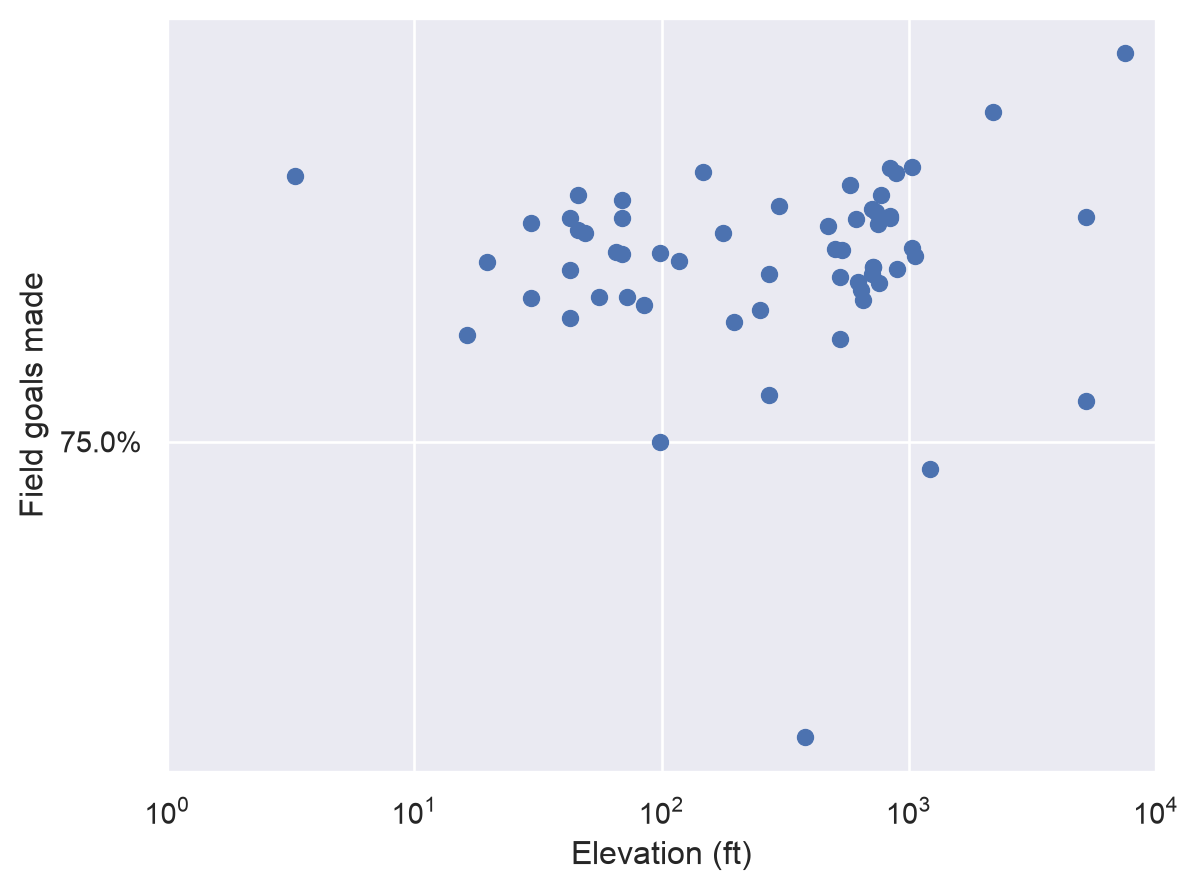

In [44]:
(
    so.Plot(
        fg_df.with_columns(pl.col("made").cast(pl.Float64)), x="elevation_ft", y="made"
    )
    .add(so.Dot(), so.Agg(), group="stadium")
    .scale(
        x=ELEV_SCALE,
        y=so.Continuous().tick(locator=PCT_LOCATOR()).label(formatter=PCT_FORMATTER()),
    )
    .label(x=ELEV_LABEL, y=MADE_LABEL)
    .limit(x=(1, 10_000))
)

If we squint hard, there might be a relationship between log elevation and success rate, but, if so, it is quite small.  We will investigate this in a model.

### Icing the kicker

[Icing the kicker](https://en.wikipedia.org/wiki/Icing_the_kicker) is a time-honored tradition in the NFL, where, before some high-leverage kicks, the defending team's coach will call a timeout while the field goal unit is lined up, in an attempt to disrupt the kicker's preparation.  We can use the play-by-play data to identify the approximately 6% of field goal attempts immediately preceded by a timeout by the defensive team.

In [45]:
fg_df = fg_df.join(
    pbp_df.sort(["game_id", "qtr", "play_id"])
    .with_columns(
        prev_timeout_team=pl.col("timeout_team").shift(1).over("game_id", "qtr")
    )
    .filter(pl.col("field_goal_attempt") == 1)
    .with_columns(iced=pl.col("prev_timeout_team").eq_missing(pl.col("defteam")))
    .select("play_id", "game_id", "iced"),
    on=["play_id", "game_id"],
)

In [46]:
print(f"{fg_df['iced'].mean():.1%}")

6.1%


Plotting the success rate for iced vs. non-iced attempts, we see that there may be a small effect at longer distances.  We will explore this possibility further in the final model of this post.

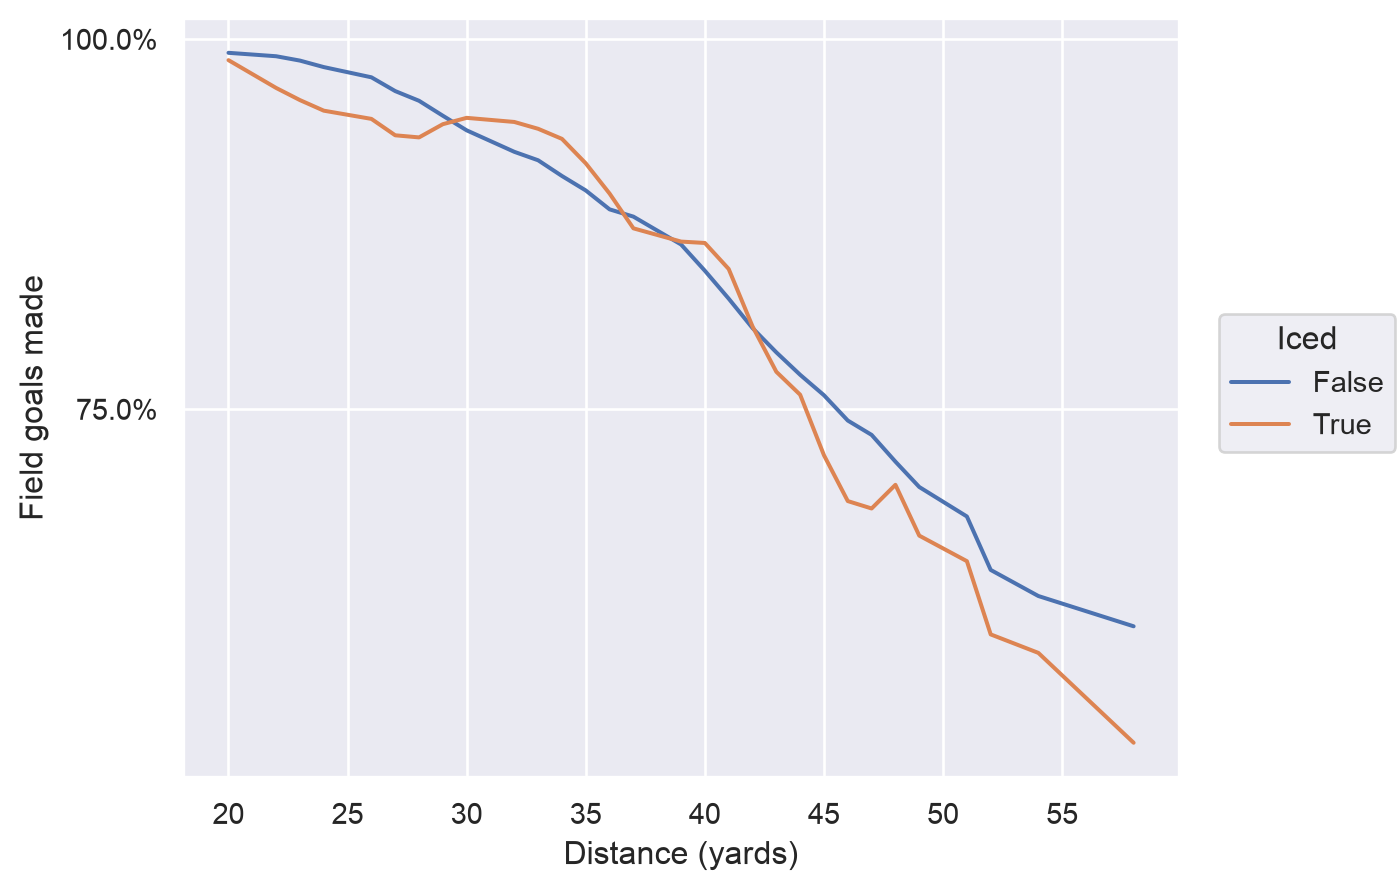

In [47]:
plot_made_by_dist(fg_df, color="iced", color_label="Iced")

### Creating enums

Finally, we turn appropriate columns into [Polars enums](https://docs.pola.rs/api/python/stable/reference/api/polars.datatypes.Enum.html) to facilitate feature engineering.

In [48]:
ENUM_COL_MAP = {
    "team": ["home_team", "away_team", "posteam", "defteam"],
    "field_goal_result": ["field_goal_result"],
    "kicker_player_name": ["kicker_player_name"],
    "season": ["season"],
    "roof": ["roof"],
    "surface": ["surface"],
    "stadium": ["stadium"],
}

In [49]:
enums = {}

for enum, names in ENUM_COL_MAP.items():
    categories = set()

    for name in names:
        categories |= set(fg_df[name].drop_nulls().cast(pl.String).unique())

    enums[enum] = pl.Enum(sorted(categories))

    for name in names:
        fg_df = fg_df.with_columns(pl.col(name).cast(pl.String).cast(enums[enum]))

## Modeling

### Logistic regression

We begin our modeling of field goal success with a simple baseline model, [logistic regression](https://en.wikipedia.org/wiki/Logistic_regression).

We first do some light data engineering, notably min/max scaling kick distance to be in the range zero to one.

In [50]:
make_2d_col = compose(np.transpose, np.atleast_2d, np.asarray)


def make_1d_transform(x, transform):
    return make_pipeline(
        FunctionTransformer(make_2d_col, np.squeeze),
        transform(),
        FunctionTransformer(np.squeeze, make_2d_col),
    ).fit(x)

In [51]:
dist_scaler = make_1d_transform(fg_df["kick_distance"].to_numpy(), MinMaxScaler)
DATA = {"dist_std": dist_scaler.transform(fg_df["kick_distance"].to_numpy())}

In [52]:
DATA["made"] = fg_df["made"].to_numpy()

Next we define a few helper functions that are a bit overengineered for this baseline model, but will save a lot of typing later for more complex models.

In [53]:
def unpack_value_dims(value_dims):
    match value_dims:
        case (value, dims):
            pass
        case value:
            dims = "obs"

    return value, dims


def make_data(**data):
    """
    Keyword args should be either:
    * name=value (for dims="obs")
    * name=(value, dims)
    """
    containers = {}

    for name, value_dims in data.items():
        value, dims = unpack_value_dims(value_dims)
        containers[name] = pm.Data(name, value, dims=dims)

    return containers

In [54]:
def make_coefs(*names):
    return {name: pm.Normal(name, 0, 2.5) for name in names}

First we make data containers to facilitate posterior predictive sampling.

In [55]:
with pm.Model() as logit_model:
    data = make_data(**DATA)

Our linear predictor will be a function of distance, with intercept and slope given by

$$\beta_0, \beta_{\text{dist}} \sim N(0, 2.5^2).$$

In [56]:
with logit_model:
    coefs = make_coefs("β0", "β_dist")

We then define the probability a field goal is made as

$$
\begin{align*}
    \eta_i
        & = \beta_0 + \beta_{\text{dist}} \cdot x_{\text{dist}, i} \\
    p_{\text{made}, i}
        & = \frac{1}{1 + \exp(-\eta_i)}.
\end{align*}
$$

Here $i$ is the index of the attempt in the data, and $x_{\text{dist}, i}$ is the (scaled) distance of the $i$-th attempt.

In [57]:
with logit_model:
    η = coefs["β0"] + coefs["β_dist"] * data["dist_std"]
    p_made = pm.Deterministic("p_made", pm.math.sigmoid(η), dims="obs")

Finally, the observed success of the $i$-th kick is Bernoulli-distributed with success probability $p_{\text{made}, i}.$

In [58]:
with logit_model:
    pm.Bernoulli("made_obs", p_made, observed=data["made"], dims="obs")

We sample from this model's posterior distribution.  Note that we are using Nutpie's [Jax](https://docs.jax.dev/en/latest/) backend for both log probability and gradient evaluations. In testing, the Jax backend proved to be 50%-300% faster than the default [Numba](https://numba.pydata.org/) backend depending on the model.

In [59]:
COMPILE_KWARGS = {"backend": "jax", "gradient_backend": "jax"}
SEED = 123456789

In [60]:
def sample(model, seed=SEED, **sample_kwargs):
    compiled = nutpie.compile_pymc_model(model, **COMPILE_KWARGS)

    trace = nutpie.sample(compiled, seed=seed, **sample_kwargs)
    pm.compute_log_likelihood(trace, model=model, progressbar=False)
    loo = az.loo(trace, pointwise=True)

    return trace, loo

In [61]:
traces = {}
loos = {}

traces["logit"], loos["logit"] = sample(logit_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.54,7
,1400,0,0.49,3
,1400,0,0.49,1
,1400,0,0.56,3
,1400,0,0.57,3
,1400,0,0.52,15


First we check the [Gelman-Rubin statistics](https://en.wikipedia.org/wiki/Gelman-Rubin_statistic), $\hat{R}$, to diagnose any sampling issues.  We exclude variables ending in the suffix `_unid`, as in future models there will be some unidentified latent random variables whose $\hat{R}$ will be expected to exceed the 1.01 threshold.  We also exclude `p_made` for convenience, as it is a deterministic function of other random variables and its $\hat{R}$ is slow to compute.

In [62]:
def plot_ax(plotter):
    (ax,) = plotter._figure.axes
    return ax

In [63]:
# match strings that don't end in "_unid" and are not exactly "p_made"
RHAT_EXCLUDE_REGEX = r"^(?!p_made$).*(?<!_unid)$"

RHAT_KWARGS = {"var_names": RHAT_EXCLUDE_REGEX, "filter_vars": "regex"}


def plot_rhat(trace):
    rhat_df = (
        az.rhat(trace, **RHAT_KWARGS)
        .max()
        .to_dataset()
        .to_dataarray(dim="variable")
        .to_dataframe(name="rhat")
        .reset_index()
        .pipe(pl.from_pandas)
    )

    plotter = (
        so.Plot(rhat_df, x="rhat", y="variable")
        .add(so.Bar())
        .scale(x=so.Continuous().tick(every=0.01))
        .limit(x=(0.999, 1.02))
        .label(x=r"$\hat{R}$", y=None)
        .plot()
    )
    plot_ax(plotter).axvline(1.01, c="k", ls="--")

    return plotter

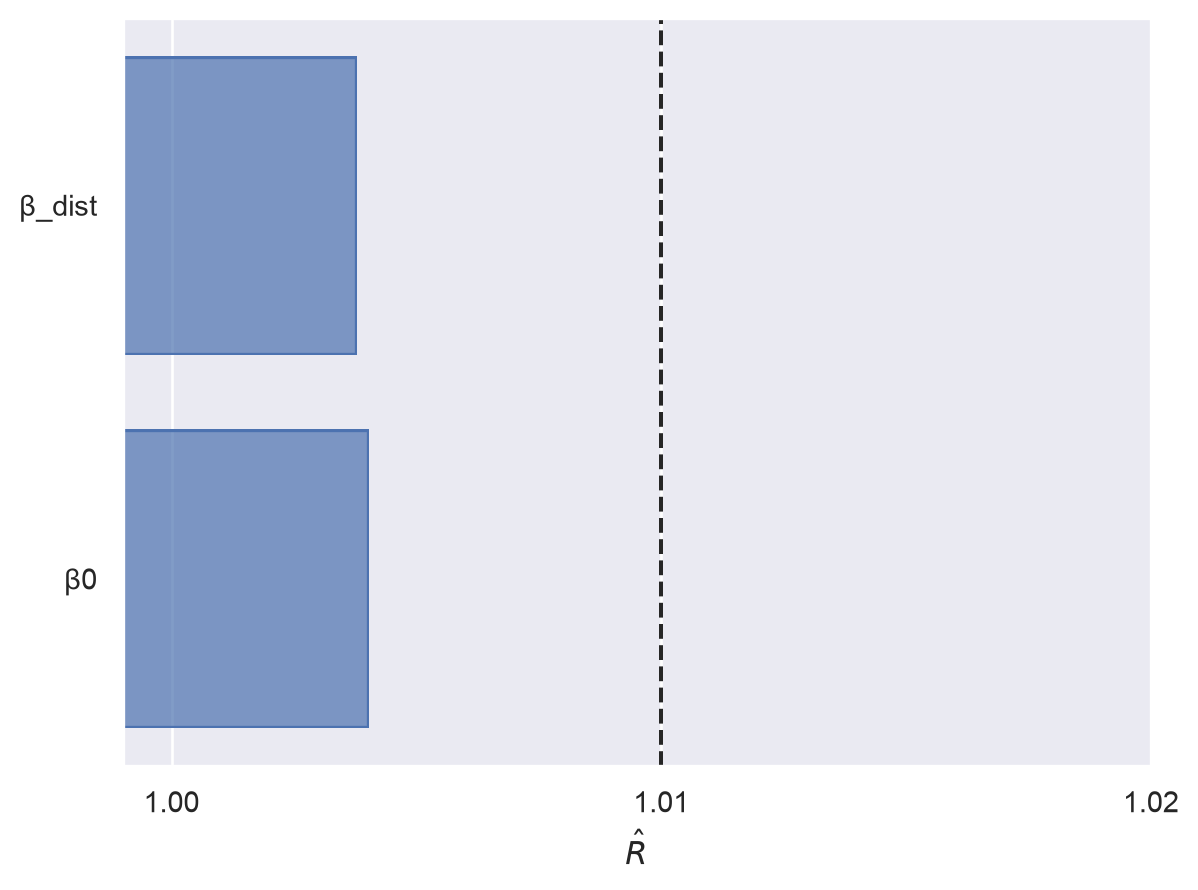

In [64]:
plot_rhat(traces["logit"])

#### Residuals

We now explore the model's [binned residuals](https://bookdown.org/jefftemplewebb/IS-6489/logistic-regression.html#assessing-logistic-model-fit), standardized across the distance bins we introduced for EDA.

In [65]:
def add_pred_resid(name, df, trace):
    return df.with_columns(
        **{
            f"{name}_pred": trace.posterior["p_made"]
            .mean(dim=("chain", "draw"))
            .to_numpy()
        }
    ).with_columns(pl.col("made").sub(pl.col(f"{name}_pred")).alias(f"{name}_resid"))

In [66]:
fg_df = add_pred_resid("logit", fg_df, traces["logit"])

In [67]:
def bin_resid(name, df, *, by="bin_mean"):
    return (
        df.group_by(by)
        .agg(
            pl.col("made").mean(),
            pl.col(f"{name}_pred").mean().alias("p_hat"),
            pl.len().alias("n"),
        )
        .with_columns(
            (
                (pl.col("made") - pl.col("p_hat"))
                / (pl.col("p_hat") * (1 - pl.col("p_hat")) / pl.col("n")).sqrt()
            ).alias(f"{name}_std_resid")
        )
        .drop("p_hat", "n")
    )

In [68]:
STD_RESID_LABEL = "Success probability\nstandardized residual"
RESID_LABEL = "Success probability\nresidual"

In [69]:
def add_ax_lines(plotter=None, *, val=2, horiz=True, ax=None):
    if ax is None:
        if plotter is None:
            raise ValueError("one of plotter or ax must not be None")
        else:
            ax = plot_ax(plotter)

    axline = ax.axhline if horiz else ax.axvline

    axline(-val, c="k", ls="--")
    axline(val, c="k", ls="--")

    return plotter


def plot_std_resid(
    name,
    df,
    *,
    x="bin_mean",
    x_label=DIST_LABEL,
    y_line=2,
    color=None,
    color_label=None,
    ax=None,
):
    plot_kwargs = {"x": x, "y": f"{name}_std_resid"}

    if color is None:
        by = x
    else:
        by = [x, color]
        plot_kwargs["color"] = color

    plot = (
        so.Plot(bin_resid(name, df, by=by), **plot_kwargs)
        .add(so.Dot(), so.Agg())
        .label(x=x_label, y=STD_RESID_LABEL, color=color_label)
    )

    if ax is None:
        return add_ax_lines(plot.plot(), val=y_line)
    else:
        plot = plot.on(ax).plot()
        add_ax_lines(val=y_line, ax=ax)

        return plot

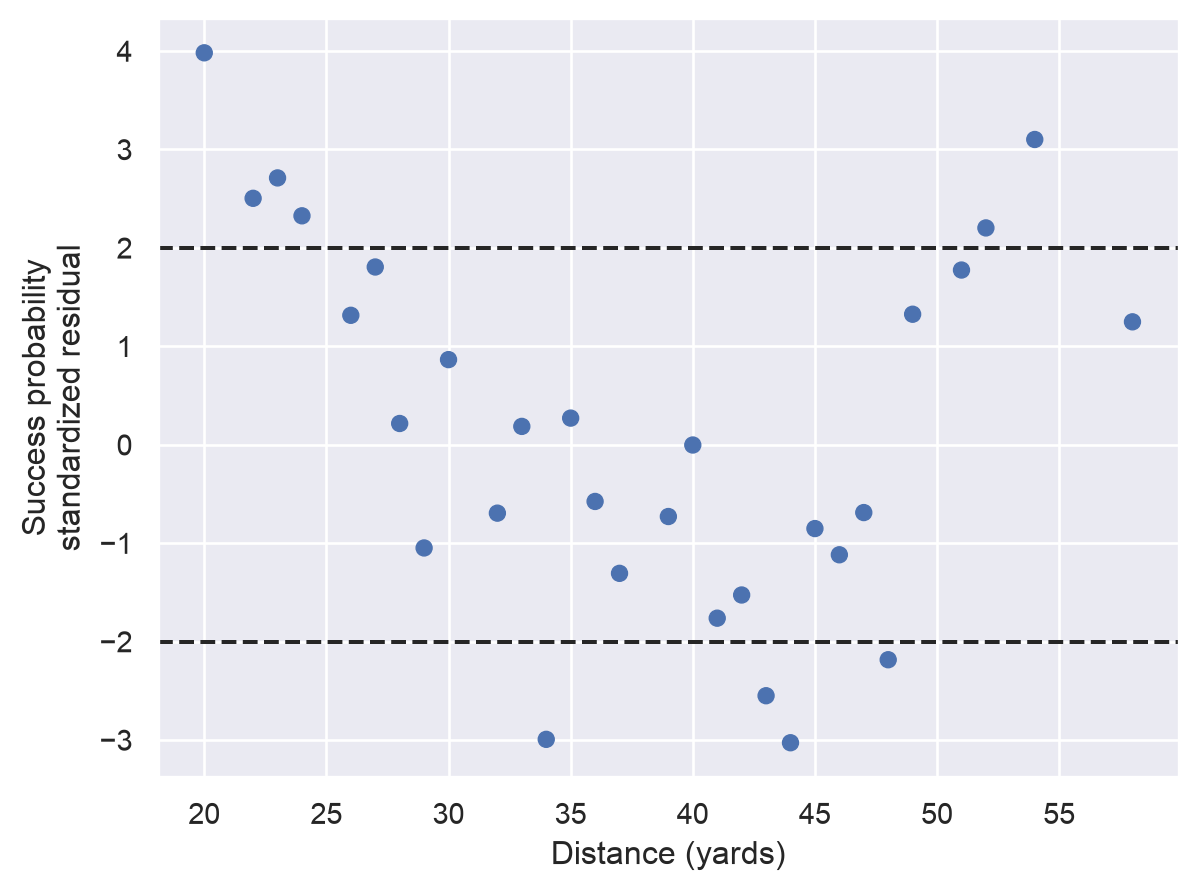

In [70]:
plot_std_resid("logit", fg_df)

We see that there is a clear pattern; the success probability is underestimated at low distances, overestimated at middling distances, and again underestimated at long distances.  The pattern indicates that a more flexible relationship between attempt distance and success probability is needed.  We will introduce this using [splines](https://en.wikipedia.org/wiki/Smoothing_spline) in the next model.

We also see that a number of the binned residuals exceed the two-standard deviation threshold.  We will look to reduce the number of such residuals in future models.

#### Predictions

Before defining a more flexible spline model, we visualize the predictions of the baseline model across a range of distances.  First we introduce a few functions that will make out-of-sample predictions simpler going forward.

In [71]:
def reindex_array(da, *, obs_dim="obs", **coords):
    da = da.assign_coords({name: (obs_dim, values) for name, values in coords.items()})
    coord_names = list(coords)

    if len(coord_names) == 1:
        return da.swap_dims({obs_dim: coord_names[0]})
    else:
        return da.set_index({obs_dim: coord_names}).unstack(obs_dim)


def sample_posterior_predictive(trace, *, seed=SEED, coords=None):
    pm.sample_posterior_predictive(
        trace,
        var_names="p_made",
        predictions=True,
        random_seed=seed,
        extend_inferencedata=True,
    )

    if coords:
        trace["predictions"]["p_made"] = reindex_array(
            trace["predictions"]["p_made"], **coords
        )

In [72]:
def make_pp_df(*pp_data):
    fst, *rest = pp_data
    df = pl.DataFrame(fst)

    for data in rest:
        df = df.join(pl.DataFrame(data), how="cross")

    return df


def enum_cols(enum, name, values):
    s = pl.Series(values, dtype=enum)
    return {f"{name}_val": s.to_physical(), name: s}

In [73]:
def set_data(df):
    data = {}
    model = pm.modelcontext(None)

    for var in model.data_vars:
        if var.name in df:
            data[var.name] = df[var.name].to_numpy()
        else:
            value, _ = unpack_value_dims(DATA[var.name])
            data[var.name] = np.empty(df.shape[0], dtype=value.dtype)

    pm.set_data(data)

In [74]:
PP_N = 100
PP_DIST = np.linspace(fg_df["kick_distance"].min(), fg_df["kick_distance"].max(), PP_N)
PP_DIST_STD = dist_scaler.transform(PP_DIST)
PP_DIST_DATA = {
    "dist_std": PP_DIST_STD,
    "dist": PP_DIST,
}

In [75]:
pp_df = make_pp_df(PP_DIST_DATA)

Next we sample from the model's posterior predictive distribution across the distance grid.

In [76]:
with logit_model:
    set_data(pp_df)
    sample_posterior_predictive(
        traces["logit"],
        coords=pp_df[["dist"]].to_dict(as_series=False),
    )

Sampling: []


Output()

Finally, we visualize these predictions.

In [77]:
def to_polars(dt):
    ds = dt.to_dataset()
    (name,) = ds.data_vars
    da = ds[name]
    dims = da.dims

    mesh = np.meshgrid(*(ds.coords[dim].to_numpy() for dim in dims), indexing="ij")
    columns = dict(zip(dims, (m.ravel() for m in mesh)))
    columns[name] = da.to_numpy().ravel()

    return pl.DataFrame(columns)

In [78]:
def made_to_float(df):
    return df.with_columns(pl.col("made").cast(pl.Float64))

In [79]:
def plot_axis_ticks(
    plot, *, x_locator=None, x_formatter=None, y_locator=None, y_formatter=None
):
    """Apply real matplotlib locators/formatters post-render.

    Works around a seaborn bug where so.Est()-based layers leave the y-axis
    PseudoAxis incompletely initialized if a matplotlib Locator/Formatter is
    passed through .scale() instead of applied directly to the rendered axes

    See https://github.com/mwaskom/seaborn/issues/3585 for details
    """
    plotter = plot.plot()
    ax = plot_ax(plotter)

    if x_locator is not None:
        ax.xaxis.set_major_locator(x_locator)
    if x_formatter is not None:
        ax.xaxis.set_major_formatter(x_formatter)
    if y_locator is not None:
        ax.yaxis.set_major_locator(y_locator)
    if y_formatter is not None:
        ax.yaxis.set_major_formatter(y_formatter)

    return plotter

In [80]:
def add_posterior_ev(
    plot,
    *,
    data=None,
    ci=True,
    color=None,
    color_by=None,
    linestyle_by=None,
    label=None,
):
    color_kwargs = {} if color is None else {"color": color}
    variables = {}

    if color_by is not None:
        variables["color"] = color_by

    if linestyle_by is not None:
        variables["linestyle"] = linestyle_by

    plot = plot.add(
        so.Line(**color_kwargs), so.Agg(), data=data, label=label, **variables
    )

    if ci:
        plot = plot.add(
            so.Band(**color_kwargs), so.Est(errorbar=("pi", 95)), data=data, **variables
        )

    return plot

In [81]:
POSTERIOR_EV_LABEL = "Posterior expected value"

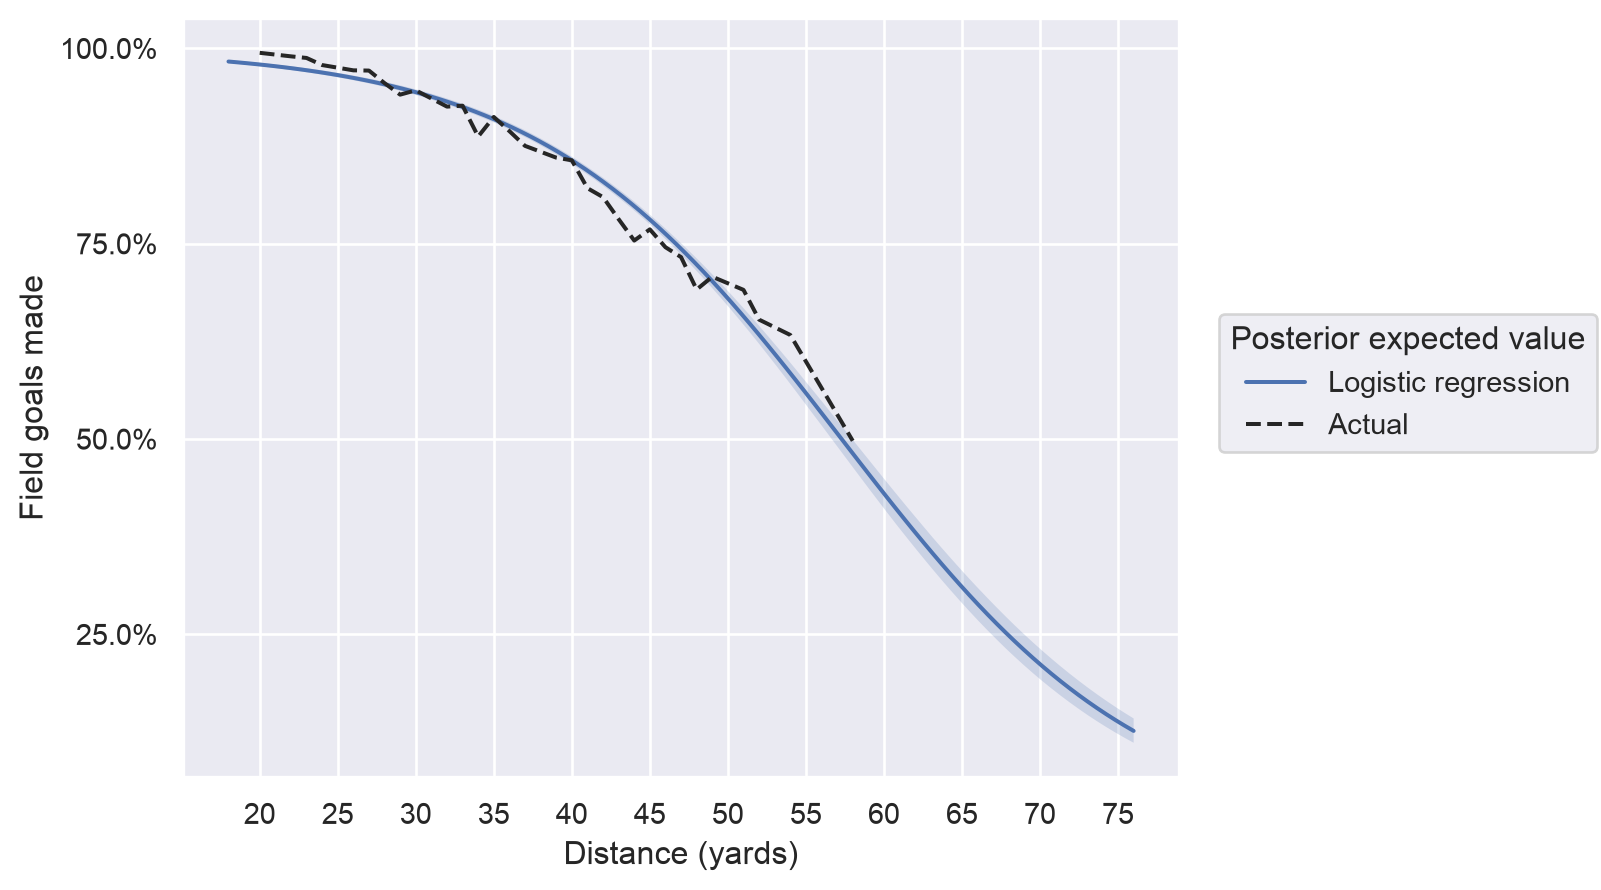

In [82]:
plot = so.Plot(traces["logit"].predictions.pipe(to_polars), x="dist", y="p_made")
plot = add_posterior_ev(plot, label="Logistic regression")
plot = (
    plot.add(
        so.Line(color="k", linestyle="--"),
        so.Agg(),
        data=fg_df.pipe(made_to_float),
        x="bin_mean",
        y="made",
        label="Actual",
    )
    .scale(x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()))
    .label(x=DIST_LABEL, y=MADE_LABEL, legend=POSTERIOR_EV_LABEL)
)

plot_axis_ticks(
    plot,
    y_locator=PCT_LOCATOR(),
    y_formatter=PCT_FORMATTER(),
)

We do indeed see the pattern predicted by the binned residuals: our model underestimates the success probability of short and long kicks, while overestimating the success probability of mid-range kicks.

### Spline

The above residuals and predictions indicate a need for a more flexible relationship between distance and kick success.  We will achieve this using smoothing splines, specifically cubic B-splines as implemented in [pymc_extras](https://www.pymc.io/projects/extras/en/stable/_modules/pymc_extras/utils/spline.html).

Since we use a spline with a nonlinear ([sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function)) link function, this and all subsequent models are [generalized additive models](https://en.wikipedia.org/wiki/Generalized_additive_model) (GAMs).

For a detailed overview of Bayesian smoothing splines, see this previous [post](https://austinrochford.com/posts/2021-08-11-splines-hetero.html) and gist of [mine](https://gist.github.com/AustinRochford/d640a240af12f6869a7b9b592485ca15).

We use twelve basis points, which, together with a cubic spline, result in 12 - 3 + 1 = 10 knots.  Per a seminal [paper](https://projecteuclid.org/journals/statistical-science/volume-11/issue-2/Flexible-smoothing-with-B-splines-and-penalties/10.1214/ss/1038425655.full) of Eilers and Marx, all we need to do is choose enough basis functions that the shape of the spline can flex where the data indicates it should. In our observed data range of 18-76 yard attempts, this results in a knot roughly every six yards, which should be sufficient for our purposes.

First we build the cubic B-spline basis for (standardized) distance.

In [83]:
K_BASIS = 12

In [84]:
DATA["dist_basis_val"] = (
    numpy_bspline_basis(DATA["dist_std"], K_BASIS, degree=3),
    ("obs", "dist_basis"),
)

In [85]:
COORDS = {"dist_basis": np.arange(K_BASIS)}

As above, we first initialize the data containers and intercept for this model.

In [86]:
with pm.Model(coords=COORDS) as spline_model:
    data = make_data(**DATA)

    coefs = make_coefs("β0")

Next we build functions to specify a [Gaussian random walk](https://en.wikipedia.org/wiki/Random_walk#Gaussian_random_walk) prior on the spline coefficients.  For more details on this prior, consult [§5.6.1](https://bayesiancomputationbook.com/markdown/chp_05.html#choosing-knots-and-prior-for-splines) of Martin, Kumar, and Lao's excellent book [_Bayesian Modeling and Computation in Python_](https://bayesiancomputationbook.com/welcome.html), which is available freely online.

Note that because we include a separate intercept $\beta_0$, we must transform the raw GRW coefficients to have zero-mean for the model to be identified.

In [87]:
def zero_mean(x, *, axis):
    return x - x.mean(axis=axis, keepdims=True)


def dist_spline_coef(name, *, dims="dist_basis"):
    σ = pm.HalfNormal(f"σ_{name}", 2.5)
    coef_unid = pm.GaussianRandomWalk(
        f"{name}_unid", 0, σ, init_dist=pm.Normal.dist(0, 2.5), dims=dims
    )

    return pm.Deterministic(name, zero_mean(coef_unid, axis=0), dims=dims)

Now we specify the prior on the spline coefficients and build the spline function $f(x_{\text{dist}, i})$.

In [88]:
with spline_model:
    w = dist_spline_coef("w")
    f_dist = data["dist_basis_val"] @ w

As before, we let

$$\eta_i = \beta_0 + f(x_{\text{dist}, i})$$

and use the sigmoid function to turn this predictor into the probability of success.

In [89]:
with spline_model:
    η = coefs["β0"] + f_dist
    p_made = pm.Deterministic("p_made", pm.math.sigmoid(η), dims="obs")

    pm.Bernoulli("made_obs", p_made, observed=data["made"], dims="obs")

Now we sample from this model's posterior distribution.

In [90]:
traces["spline"], loos["spline"] = sample(spline_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.13,31
,1400,0,0.12,31
,1400,0,0.13,31
,1400,0,0.10,127
,1400,0,0.12,19
,1400,0,0.11,63


The $\hat{R}$ statistics show no cause for concern.

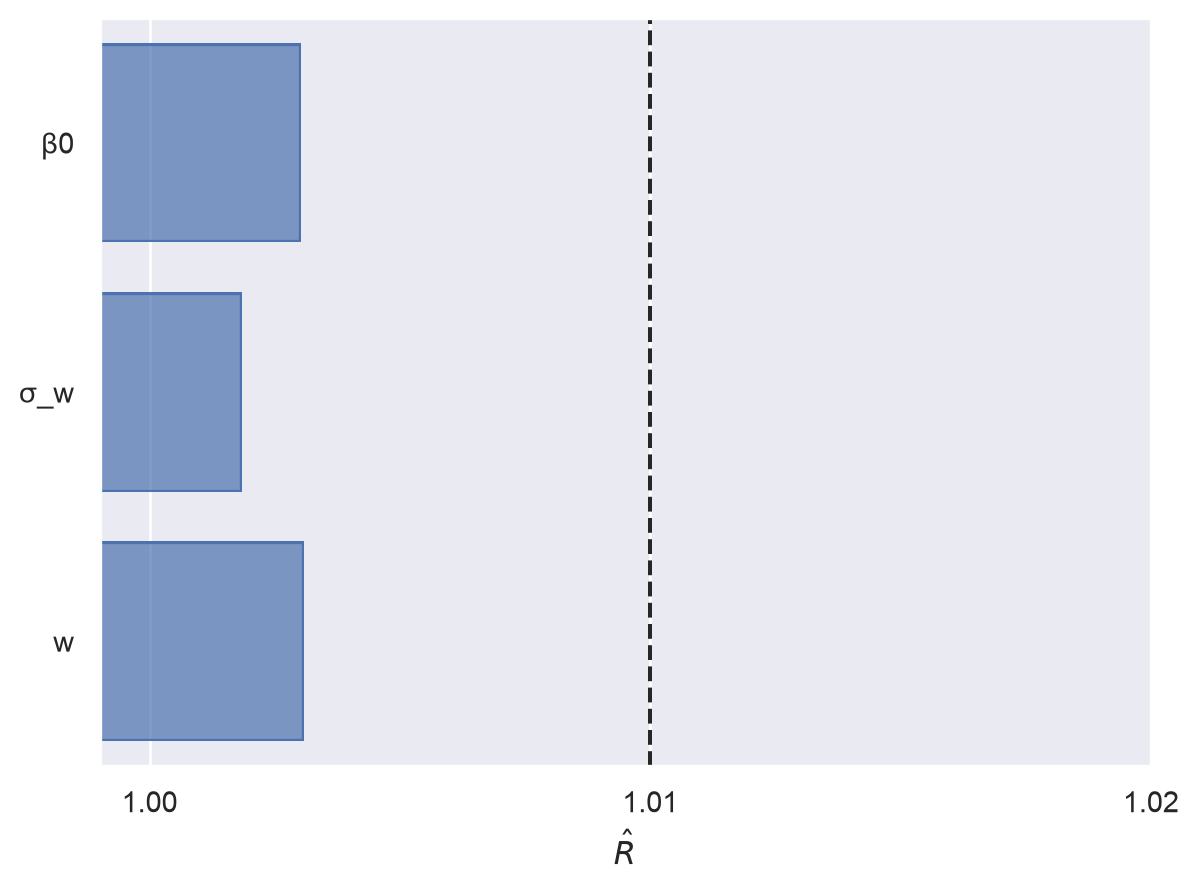

In [91]:
plot_rhat(traces["spline"])

#### Residuals

We now explore this model's binned residuals, first sampling from the posterior predictive distribution at the observed data points.

In [92]:
fg_df = add_pred_resid("spline", fg_df, traces["spline"])

With this more flexible relationship, we see no obvious relationship between kick distance and binned residual, and only one residual is more than two standard deviations from zero.

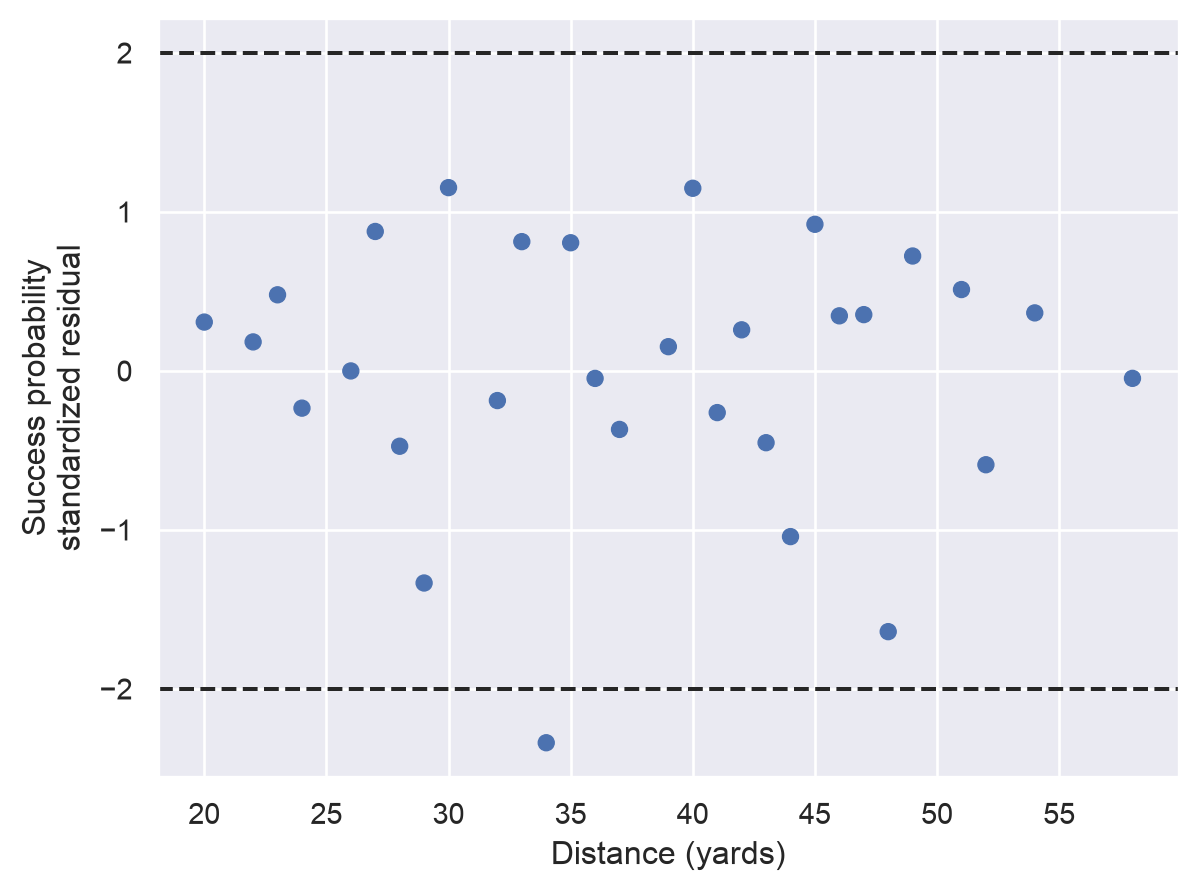

In [93]:
plot_std_resid("spline", fg_df)

Based on our initial EDA, we expect whether or not the game is being played exposed to the elements and whether or not it is being played on turf to impact the probability of success.  Each of the following two binned residual plots confirms that our model should improve by taking these factors into account.

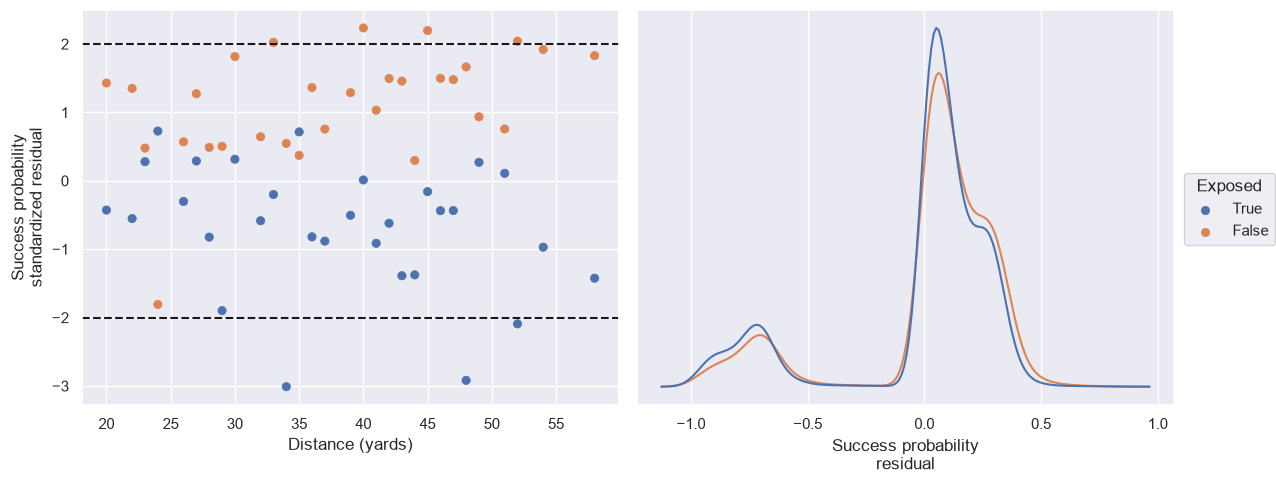

In [94]:
fig, (dist_ax, hist_ax) = plt.subplots(ncols=2, figsize=(12, 5))

(
    so.Plot(fg_df, x="spline_resid", color="is_exposed")
    .add(so.Line(), so.KDE(common_norm=False), legend=False)
    .on(hist_ax)
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=RESID_LABEL)
    .plot()
)

plot_std_resid("spline", fg_df, color="is_exposed", color_label="Exposed", ax=dist_ax)
fig.tight_layout();

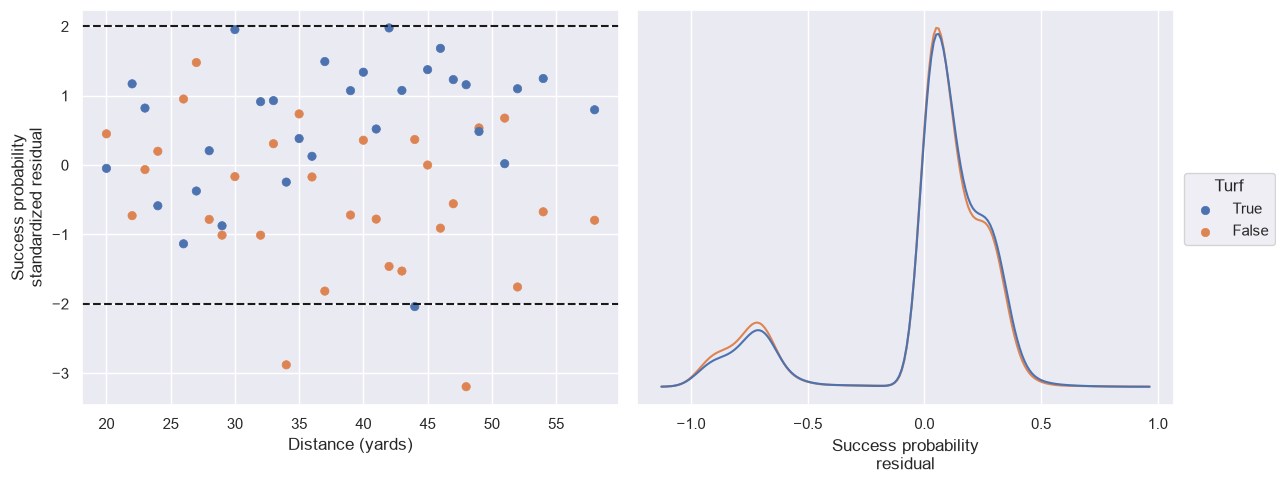

In [95]:
fig, (dist_ax, hist_ax) = plt.subplots(ncols=2, figsize=(12, 5))

(
    so.Plot(fg_df, x="spline_resid", color="is_turf")
    .add(so.Line(), so.KDE(common_norm=False), legend=False)
    .on(hist_ax)
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=RESID_LABEL)
    .plot()
)

plot_std_resid("spline", fg_df, color="is_turf", color_label="Turf", ax=dist_ax)
fig.tight_layout();

#### Model comparison

Now that we have more than one model, we will begin comparing them using ArviZ's [`compare`](https://python.arviz.org/projects/stats/en/stable/api/generated/arviz_stats.compare.html) function, which implements Bayesian leave-one-out cross-validation as described in the [2017 paper](https://arxiv.org/abs/1507.04544) of Vehtari, Gelman, and Gabry.

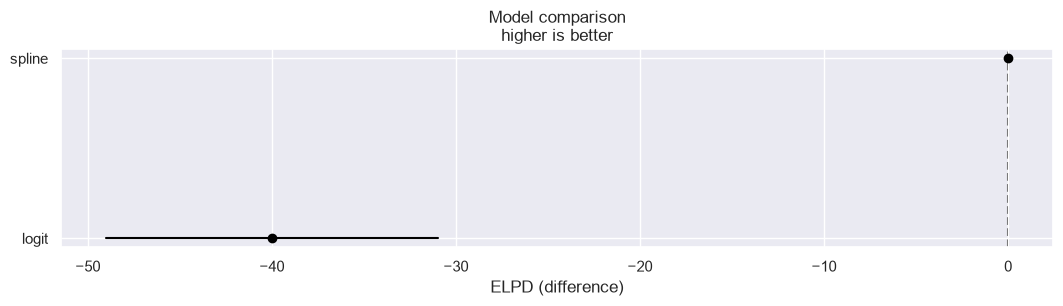

In [96]:
az.plot_compare(az.compare(loos));

The above plot of the ELPD (expected log pointwise predictive density) shows that the spline model is substantially better than the logistic regression model, as expected.

#### Predictions

Now that we have sampled from this model, explored its residuals, and compared it to the previous model, we turn to visualizing its predictions.

We use the same machinery as before to sample from the posterior predictive distribution along a grid of plausible kick distances.

In [97]:
PP_DIST_DATA["dist_basis_val"] = numpy_bspline_basis(PP_DIST_STD, K_BASIS, degree=3)

In [98]:
pp_df = make_pp_df(PP_DIST_DATA)

In [99]:
with spline_model:
    set_data(pp_df)

    sample_posterior_predictive(
        traces["spline"],
        coords=pp_df[["dist"]].to_dict(as_series=False),
    )

Sampling: []


Output()

We see visual confirmation of what the model comparisons have already shown: that the spline model much better captures the relationship between kick distance and success rate.

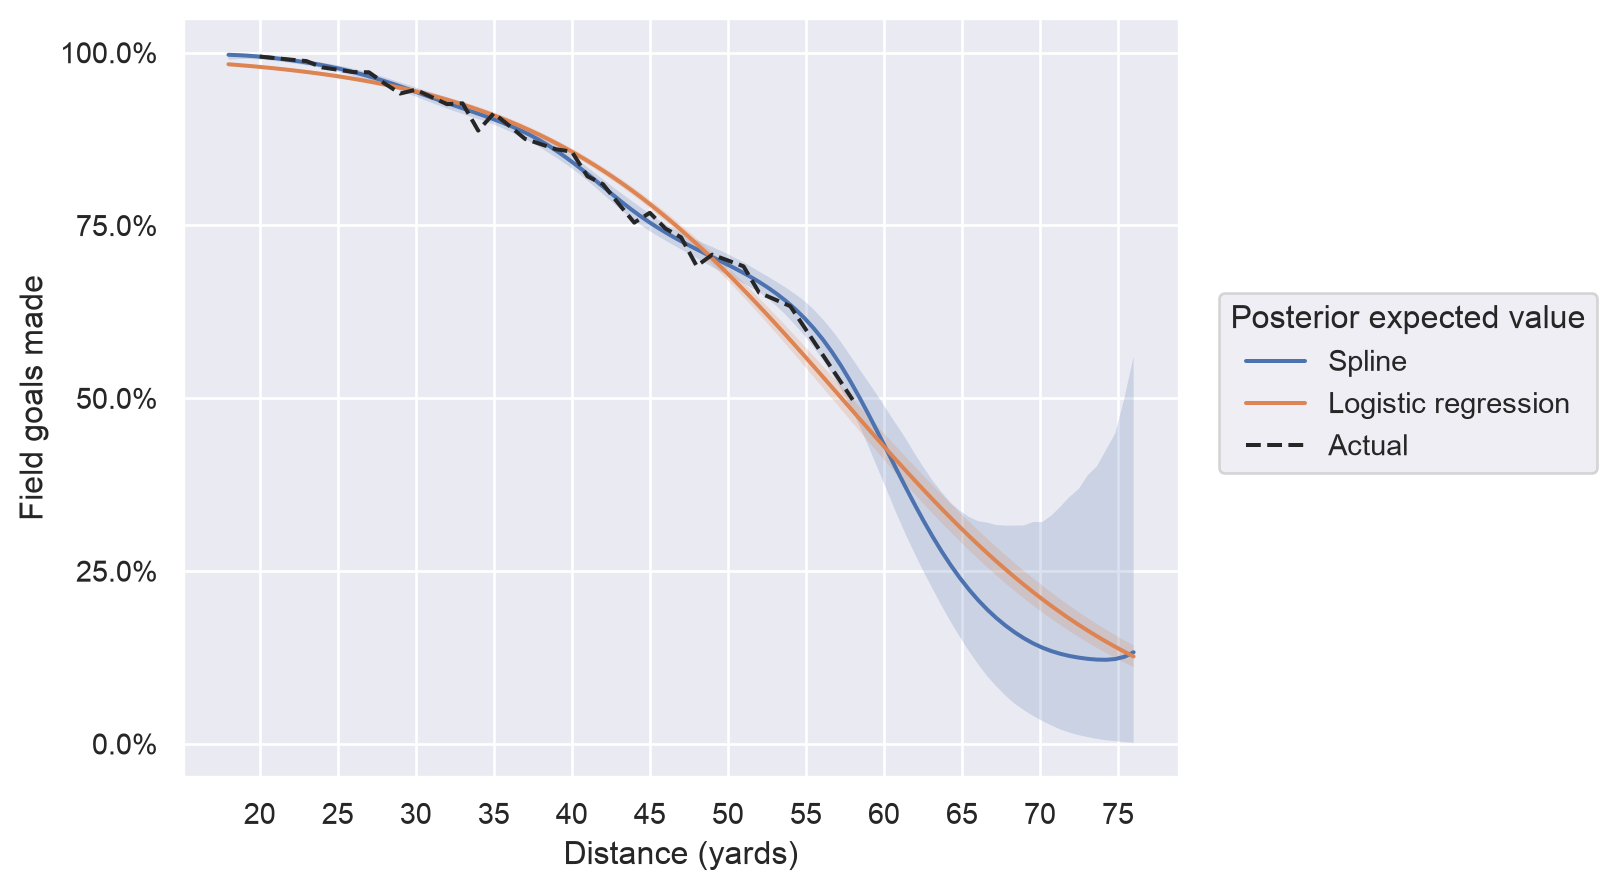

In [100]:
plot = so.Plot(traces["spline"].predictions.pipe(to_polars), x="dist", y="p_made")
plot = add_posterior_ev(plot, label="Spline")
plot = add_posterior_ev(
    plot,
    data=traces["logit"].predictions.pipe(to_polars),
    color="C1",
    label="Logistic regression",
)

plot_axis_ticks(
    plot.add(
        so.Line(color="k", linestyle="--"),
        so.Agg(),
        data=fg_df.pipe(made_to_float),
        x="bin_mean",
        y="made",
        label="Actual",
    )
    .scale(x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()))
    .label(x=DIST_LABEL, y=MADE_LABEL, legend=POSTERIOR_EV_LABEL),
    y_locator=PCT_LOCATOR(),
    y_formatter=PCT_FORMATTER(),
)

Interestingly, we see that the spline model shows much more uncertainty for extremely long kicks (above about 60 yards).  This uncertainty is appropriate, given how few kicks of those lengths have been observed, as shown in the following plot.

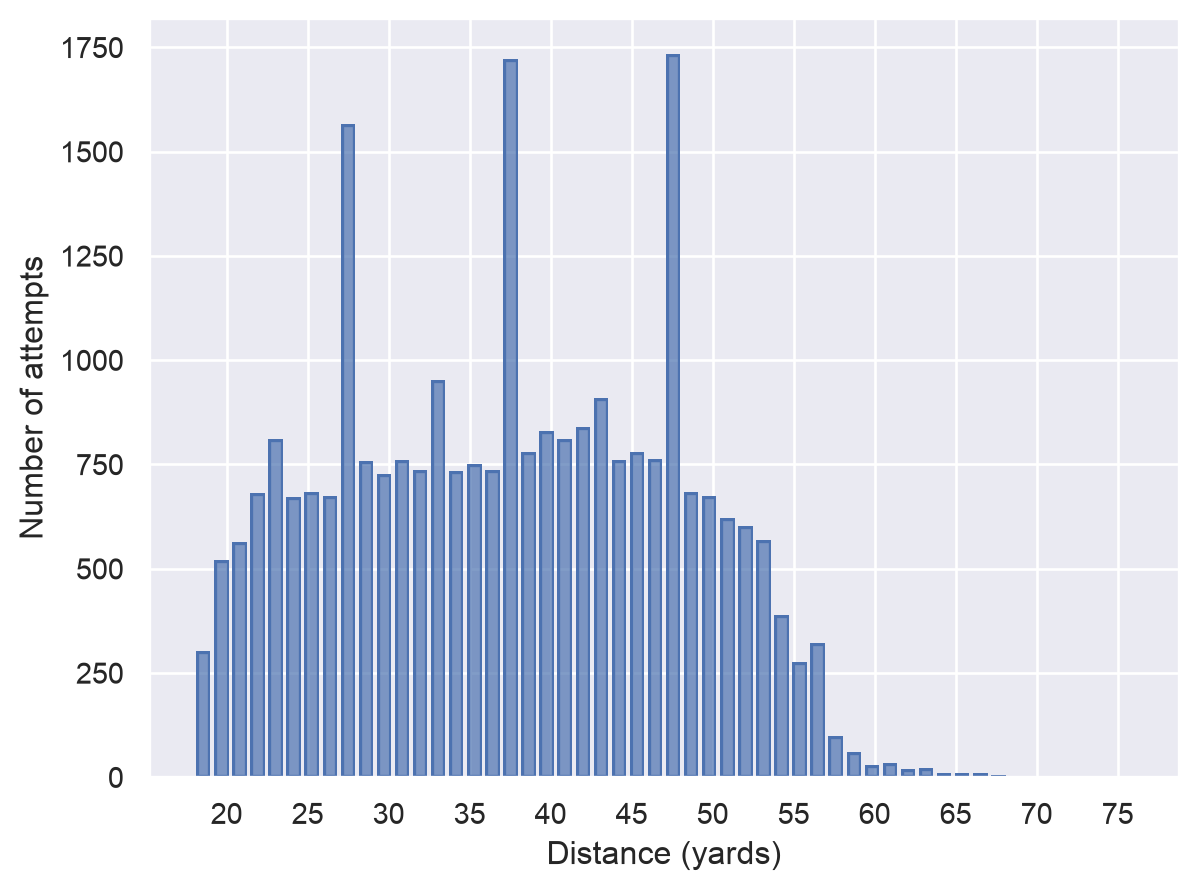

In [101]:
(
    so.Plot(fg_df, x="kick_distance")
    .add(so.Bar(), so.Hist())
    .scale(x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()))
    .label(x=DIST_LABEL, y="Number of attempts")
)

Both the logistic regression and the spline model have one intercept, but while the logistic regression model only has one slope parameter, the spline model has one parameter per basis function for twelve parameters (in addition to the intercept).  The following plot adds the basis functions.

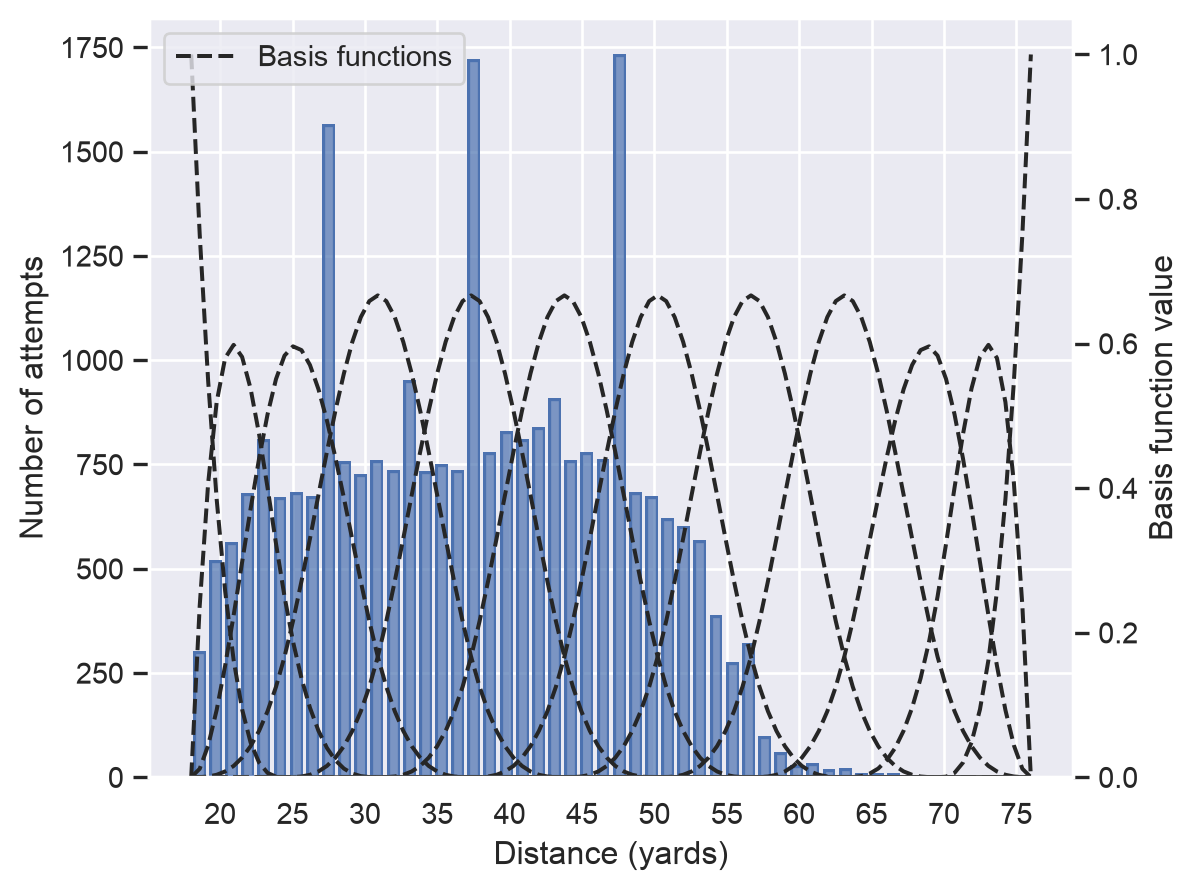

In [102]:
plotter = (
    so.Plot(fg_df, x="kick_distance")
    .add(so.Bar(), so.Hist())
    .scale(x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()))
    .label(x=DIST_LABEL, y="Number of attempts")
    .plot()
)

ax = plot_ax(plotter)

basis_val = numpy_bspline_basis(PP_DIST_STD, K_BASIS, degree=3)
basis_ax = ax.twinx()

for i in range(K_BASIS):
    basis_ax.plot(
        PP_DIST,
        basis_val[:, i],
        c="k",
        ls="--",
        label="Basis functions" if i == 0 else None,
    )

basis_ax.set_ylim(bottom=0)
basis_ax.set_ylabel("Basis function value")
basis_ax.grid(False)

basis_ax.legend(loc="upper left")

plotter

The coefficients corresponding to basis functions whose support contains fewer observed kicks will have higher posterior uncertainty, resulting in the higher uncertainty in the spline model's predictions at longer distances.

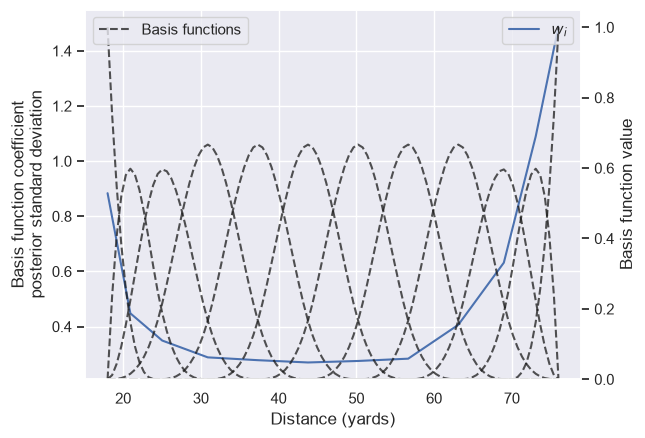

In [103]:
_, ax = plt.subplots()

w_dist = PP_DIST[numpy_bspline_basis(PP_DIST_STD, K_BASIS, degree=3).argmax(axis=0)]

ax.plot(
    w_dist,
    traces["spline"].posterior["w"].std(dim=("chain", "draw")),
    label="$w_i$",
)

ax.set_xlabel(DIST_LABEL)
ax.set_ylabel("Basis function coefficient\nposterior standard deviation")
ax.legend(loc="upper right")

basis_ax = ax.twinx()

for i in range(K_BASIS):
    basis_ax.plot(
        PP_DIST,
        basis_val[:, i],
        c="k",
        ls="--",
        alpha=0.75,
        label="Basis functions" if i == 0 else None,
    )

basis_ax.set_ylim(bottom=0)
basis_ax.set_ylabel("Basis function value")
basis_ax.grid(False)

basis_ax.legend(loc="upper left");

### Environment

We now extend the spline model to include the exposure and field surface factors identified in our EDA and that we confirmed to be correlated with residuals in the previous section.

In [104]:
DATA["exposed"] = fg_df["is_exposed"].to_numpy()
DATA["turf"] = fg_df["is_turf"].to_numpy()

This environmental model includes all the factors from the spline model.

In [105]:
with pm.Model(coords=COORDS) as env_model:
    data = make_data(**DATA)

    coefs = make_coefs("β0")

    w = dist_spline_coef("w")
    f_dist = data["dist_basis_val"] @ w

It also adds coefficients

$$\beta_{\text{exposed}}, \beta_{\text{turf}} \sim N(0, 2.5^2).$$

In [106]:
with env_model:
    coefs.update(make_coefs("β_exposed", "β_turf"))

Finally, the linear predictor is defined as

$$\eta_i = \beta_0 + \beta_{\text{exposed}} \cdot x_{\text{exposed}, i} + \beta_{\text{turf}} \cdot x_{\text{turf}, i} + f(x_{\text{dist}, i}).$$

In [107]:
with env_model:
    # fmt: off
    η = sum([
        coefs["β0"],
        coefs["β_exposed"] * data["exposed"],
        coefs["β_turf"] * data["turf"],
        f_dist
    ])
    # fmt: on

The probability of success and likelihood of the observed data are defined as in the previous two models.

In [108]:
with env_model:
    p_made = pm.Deterministic("p_made", pm.math.sigmoid(η), dims="obs")

    pm.Bernoulli("made_obs", p_made, observed=data["made"], dims="obs")

We now sample from the model's posterior distribution.

In [109]:
traces["env"], loos["env"] = sample(env_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.13,31
,1400,0,0.12,319
,1400,0,0.11,31
,1400,0,0.11,255
,1400,0,0.12,31
,1400,0,0.13,223


The $\hat{R}$ statistics show no cause for concern.

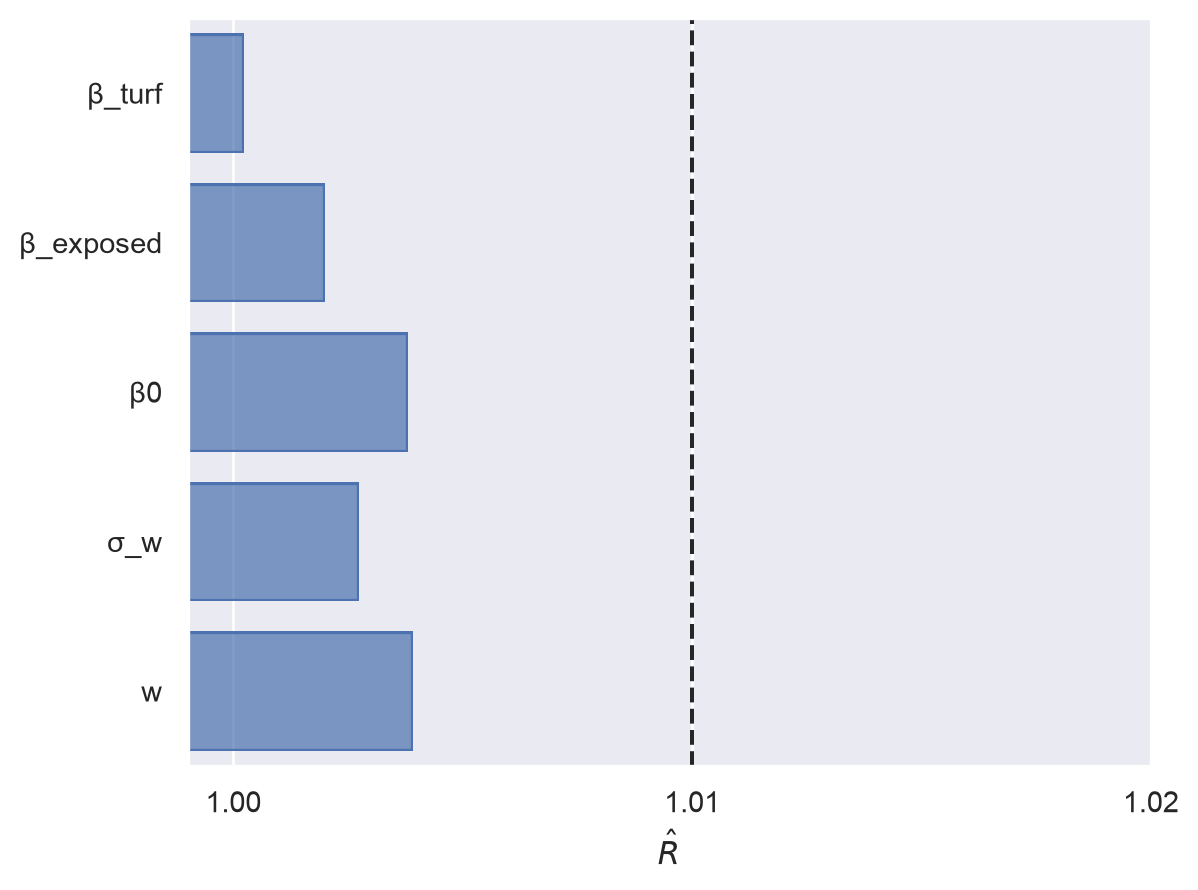

In [110]:
plot_rhat(traces["env"])

#### Residuals

We again look at this model's binned residuals.

In [111]:
fg_df = add_pred_resid("env", fg_df, traces["env"])

We again see no correlation between kick distance and binned residual, and only one residual is more than two standard deviations from zero.

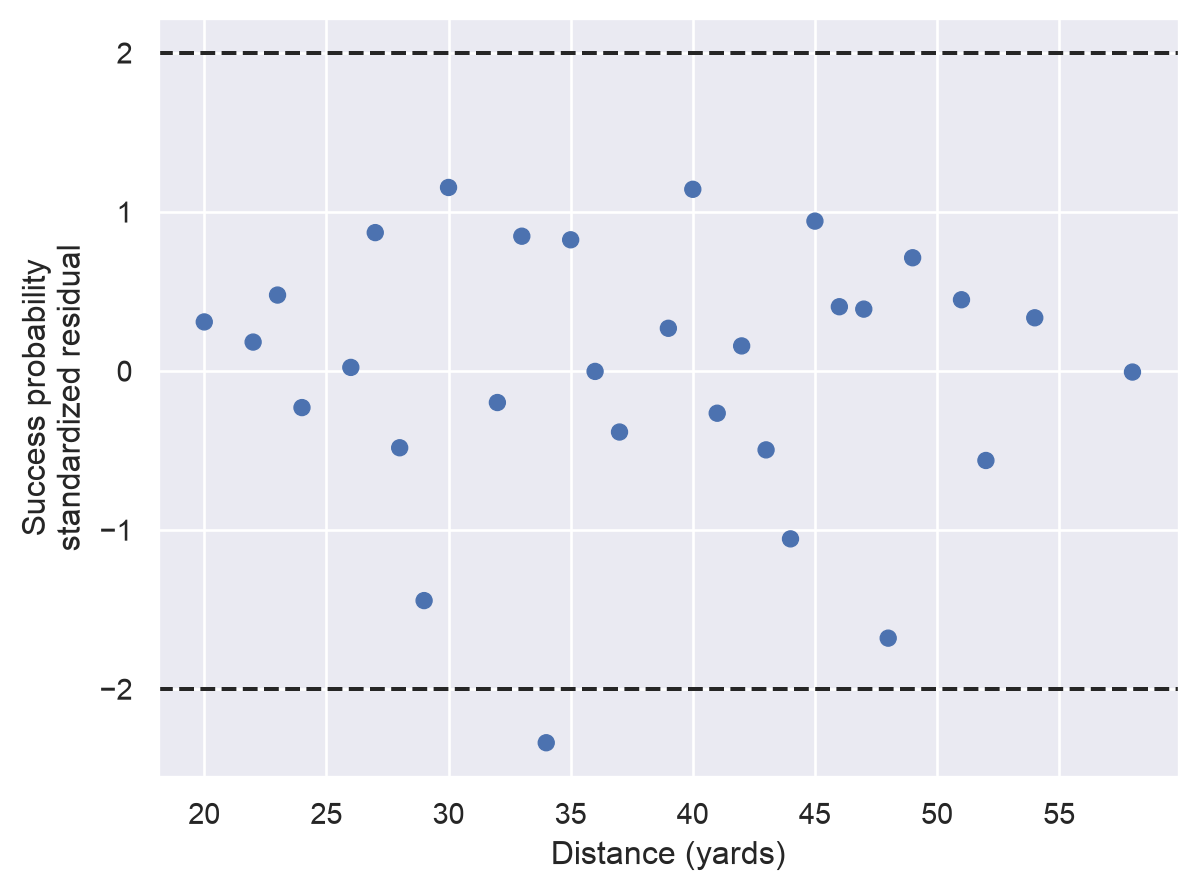

In [112]:
plot_std_resid("env", fg_df)

We see that there is no longer a noticeable pattern when we break down residuals by environmental exposure or field surface, as desired.

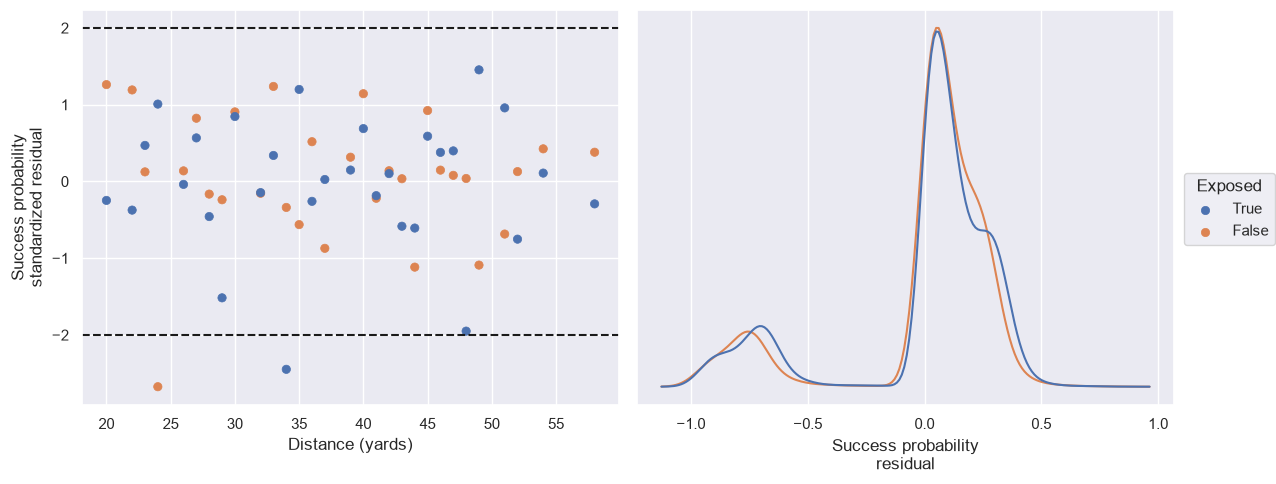

In [113]:
fig, (dist_ax, hist_ax) = plt.subplots(ncols=2, figsize=(12, 5))

(
    so.Plot(fg_df, x="env_resid", color="is_exposed")
    .add(so.Line(), so.KDE(common_norm=False), legend=False)
    .on(hist_ax)
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=RESID_LABEL)
    .plot()
)

plot_std_resid("env", fg_df, color="is_exposed", color_label="Exposed", ax=dist_ax)
fig.tight_layout();

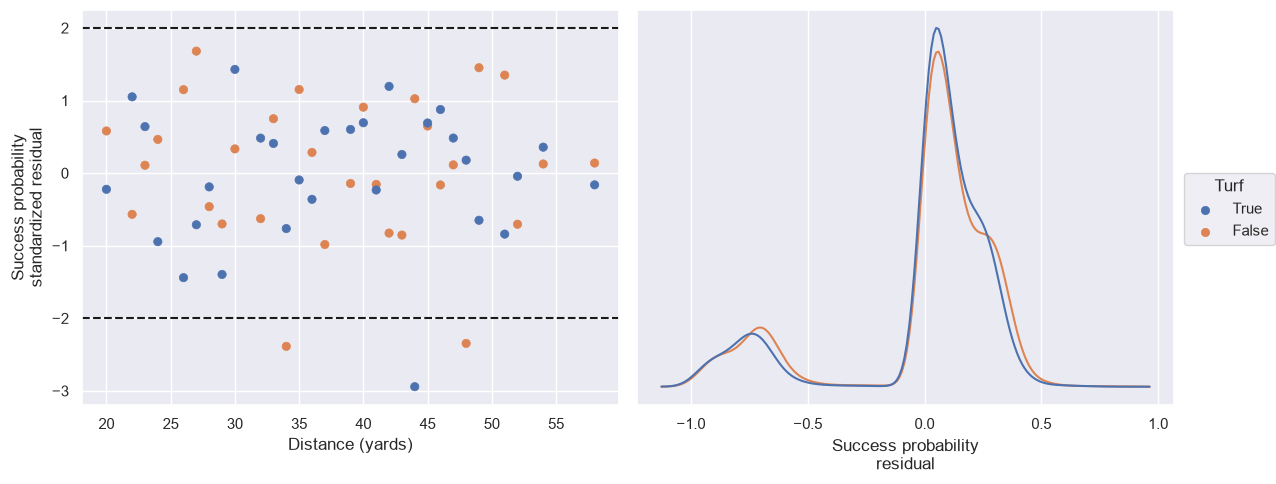

In [114]:
fig, (dist_ax, hist_ax) = plt.subplots(ncols=2, figsize=(12, 5))

(
    so.Plot(fg_df, x="env_resid", color="is_turf")
    .add(so.Line(), so.KDE(common_norm=False), legend=False)
    .on(hist_ax)
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=RESID_LABEL)
    .plot()
)

plot_std_resid("env", fg_df, color="is_turf", color_label="Turf", ax=dist_ax)
fig.tight_layout();

Finally, we look at this model's residuals binned by season.

In [115]:
season_to_int = pl.col("season").cast(pl.String).str.to_integer()

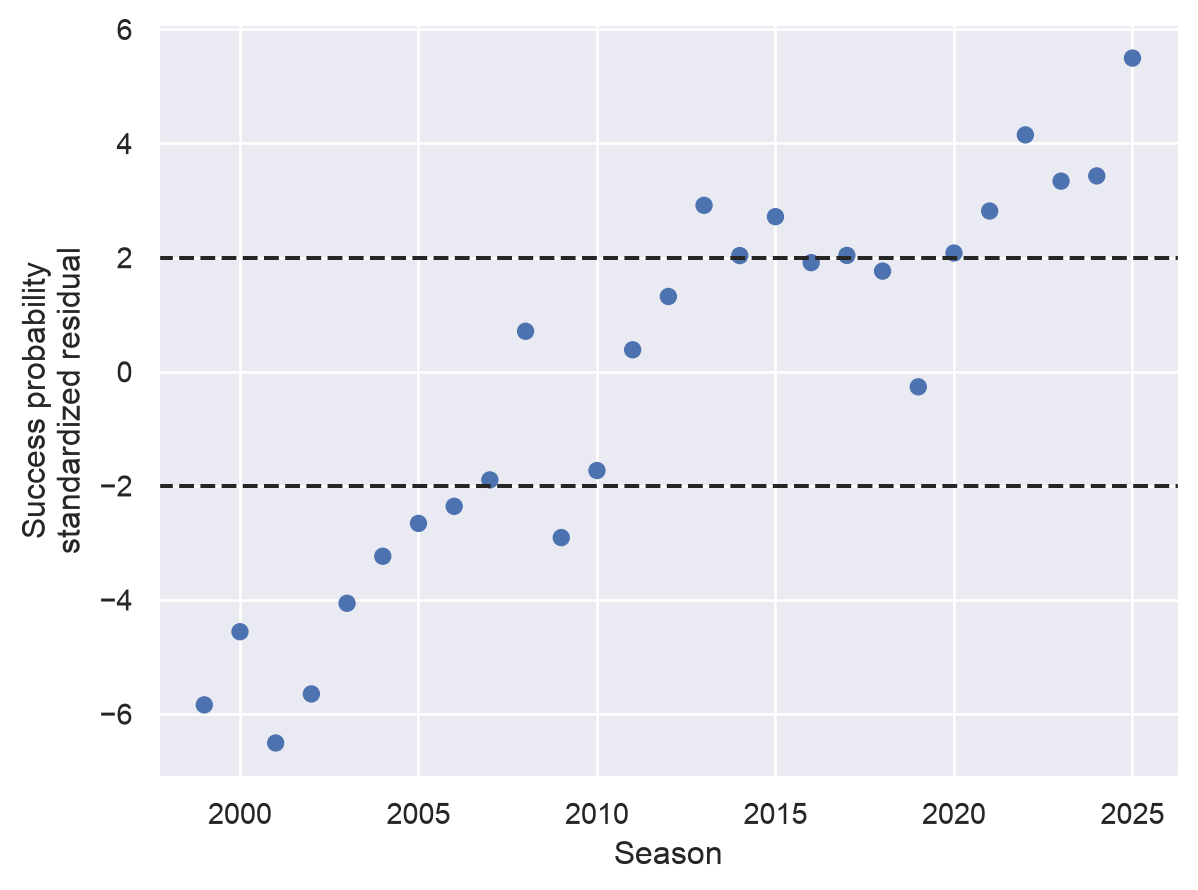

In [116]:
add_ax_lines(
    so.Plot(
        bin_resid("env", fg_df, by="season").with_columns(season_to_int).sort("season"),
        x="season",
        y="env_std_resid",
    )
    .add(so.Dot())
    .scale(x=so.Continuous().tick(locator=SEASON_MAJOR_LOCATOR()))
    .label(x=SEASON_LABEL, y=STD_RESID_LABEL)
    .plot()
)

There is an obvious trend in the per-season residuals, where the model overestimates the success probability for early seasons and underestimates it for late seasons.  We will address this trend in our next model.

#### Model comparison

We now compare our three models using LOO-CV again.

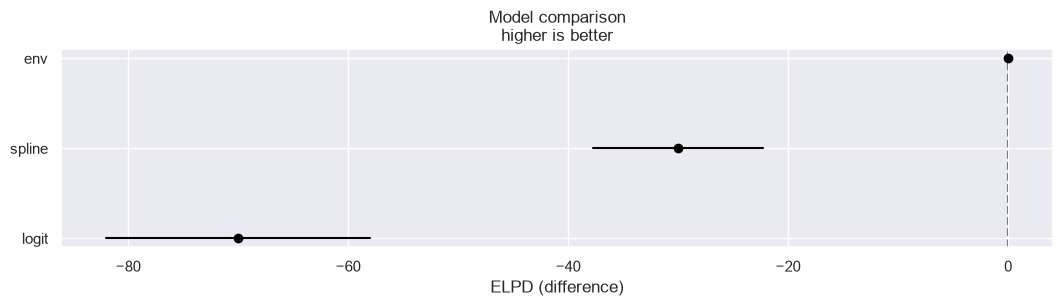

In [117]:
az.plot_compare(az.compare(loos));

We see that the environmental model has a substantially better ELPD than the previous two models.

#### Interpretation

We see the posterior distribution of the coefficient for exposure is well-separated from zero, and that, while the surface coefficient's 95% credible interval contains zero, it is near the lower boundary.

These posterior distributions indicate that the effect of exposure on success probability is likely stronger than that of the playing surface, which seems plausible.

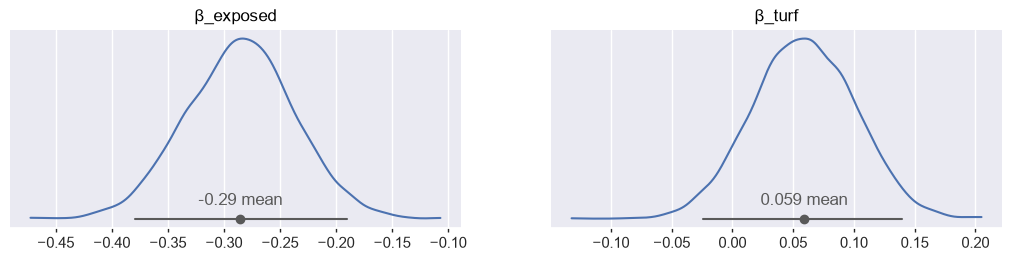

In [118]:
az.plot_dist(traces["env"], var_names=["β_exposed", "β_turf"], ci_prob=0.95);

#### Predictions

The following plot shows the predicted success rates for all combinations of exposure and field surface.

In [119]:
pp_df = make_pp_df(
    PP_DIST_DATA,
    {"exposed": [False, True]},
    {"turf": [False, True]},
)

In [120]:
with env_model:
    set_data(pp_df)

    sample_posterior_predictive(
        traces["env"],
        coords=pp_df[["dist", "exposed", "turf"]].to_dict(as_series=False),
    )

Sampling: []


Output()

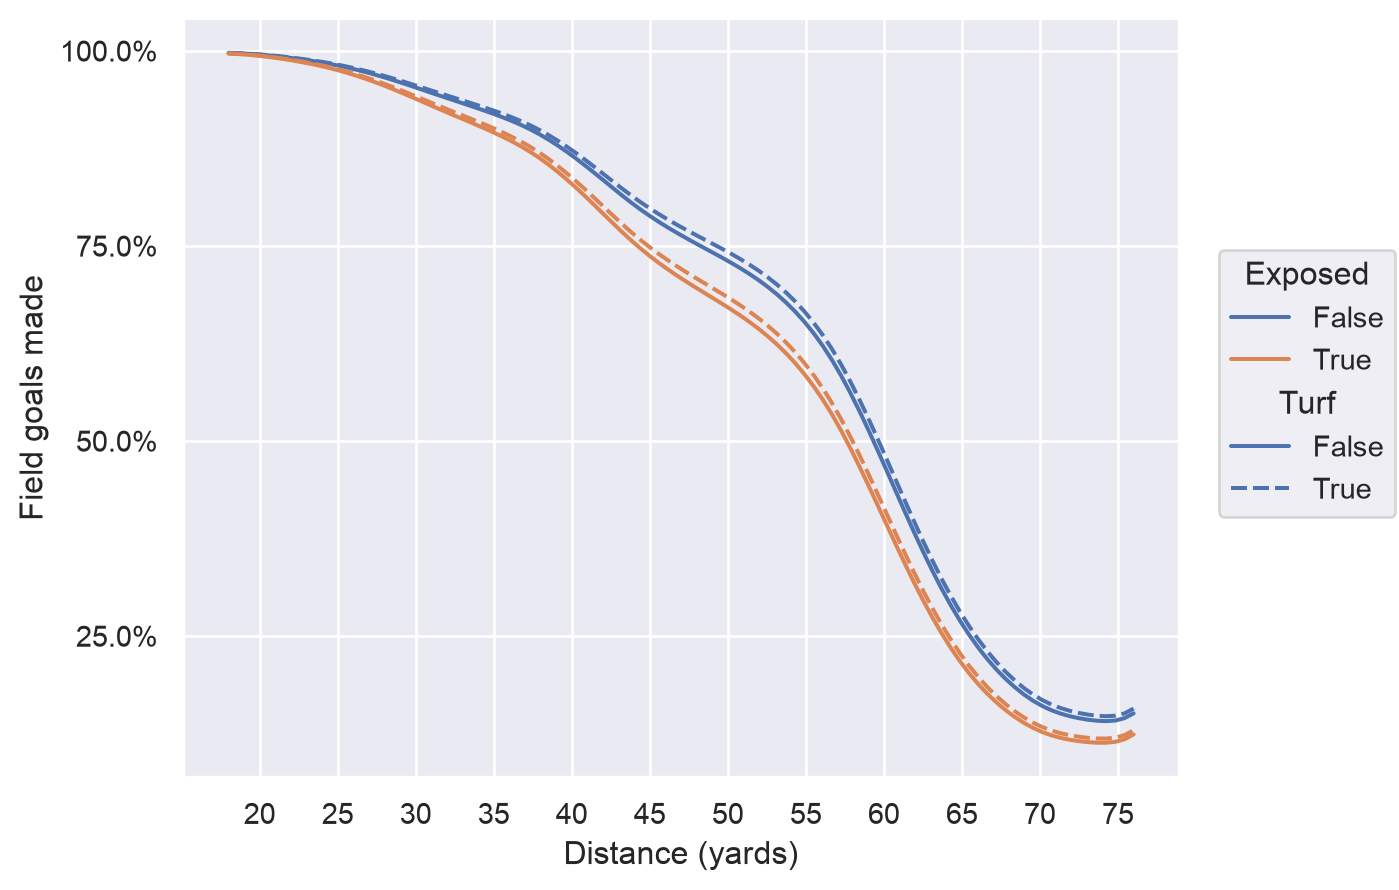

In [121]:
plot = so.Plot(traces["env"].predictions.pipe(to_polars), x="dist", y="p_made")
plot = add_posterior_ev(plot, ci=False, color_by="exposed", linestyle_by="turf")
plot = plot.scale(
    x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()), color=so.Nominal()
).label(x=DIST_LABEL, y=MADE_LABEL, color="Exposed", linestyle="Turf")

plot_axis_ticks(plot, y_locator=PCT_LOCATOR(), y_formatter=PCT_FORMATTER())

It confirms our conjecture in the previous section that exposure matters more than the type of surface.

### Season

We now turn to modeling the general improvement in success rate over time by adding season-level variation to the previous model.  First we add the necessary data to our containers.

In [122]:
COORDS["season"] = enums["season"].categories.to_list()

In [123]:
DATA["season_val"] = fg_df["season"].to_physical().to_numpy()

We will also use smoothing splines to model the season-level deviation from the average relationship between kick distance and success rate.  We will use fewer basis functions (six) for the season-level deviation than for the average function (twelve).  We will also model the evolution of the basis function coefficients season-over-season as an [AR(1) process](https://en.wikipedia.org/wiki/Autoregressive_model#Example:_An_AR(1)_process) instead of a Gaussian random walk.  We make this change for two reasons:

1. an AR(1) process (with $|\varphi| < 1$) has bounded variance regardless of the number of steps, and
2. we want the season-over-season evolution to be gradual and tied to the previous season's value less strongly than a GRW does.

In [124]:
K_SEASON_BASIS = 6

season_basis = numpy_bspline_basis(np.linspace(0, 1, K_BASIS), K_SEASON_BASIS)

COORDS["season_basis"] = np.arange(K_SEASON_BASIS)

To choose the prior on the autoregressive parameter, $\varphi$, we use [PreliZ](https://preliz.readthedocs.io/en/latest/index.html) to find the [maximum entropy](https://en.wikipedia.org/wiki/Principle_of_maximum_entropy) [Beta distribution](https://en.wikipedia.org/wiki/Beta_distribution) that places 95% of its probability mass between $\sqrt{0.25}$ and $\sqrt{0.9}$.  These constraints encode our a priori belief that there is a 95% chance that between 25% and 90% of the current season's deviation is explained by the previous season's, which seems quite reasonable.

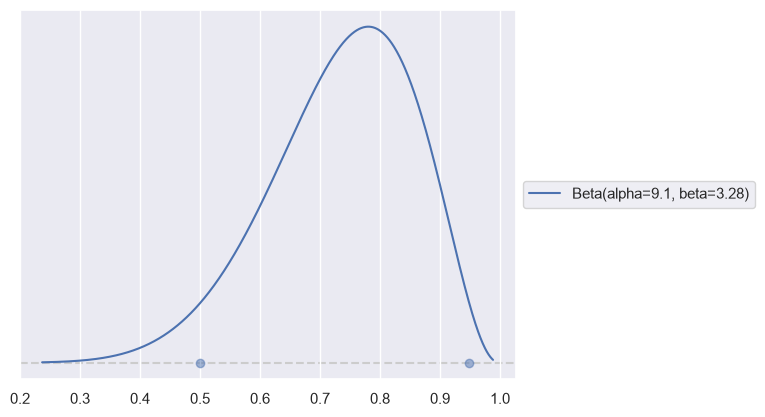

In [125]:
φ_prior, _ = pz.maxent(pz.Beta(), np.sqrt(0.25), np.sqrt(0.9), 0.95)

We see that we get (approximately)

$$\varphi \sim \text{Beta}(9.1, 3.3).$$

The following function implements this AR(1)-driven per season deviation.

In [126]:
def deviation_coef(name, basis):
    η = pm.HalfNormal(f"η_{name}", 0.5)
    φ = φ_prior.to_pymc(f"φ_{name}")
    σ = pm.Deterministic(f"σ_{name}", η * pm.math.sqrt(1 - φ**2))

    model = pm.modelcontext(None)
    n_season = len(model.coords[name])
    coef_unid = pm.AR(
        f"α_{name}_unid",
        φ,
        σ,
        init_dist=pm.Normal.dist(0, η),
        steps=n_season - 1,
        dims=(f"{name}_basis", name),
    )
    coef = pm.Deterministic(
        f"α_{name}", zero_mean(coef_unid, axis=1), dims=(f"{name}_basis", name)
    )

    return pm.Deterministic(f"w_{name}", (basis @ coef).T, dims=(name, "dist_basis"))

We now turn to defining the model.  The intercept, environmental coefficients, and baseline distance spline are all defined as before.

In [127]:
with pm.Model(coords=COORDS) as season_model:
    data = make_data(**DATA)

    coefs = make_coefs("β0", "β_exposed", "β_turf")
    w0 = dist_spline_coef("w0")

Note that we are now calling the baseline distance spline coefficients $w_0$.

We now define the season-level deviation from this baseline $w_{\text{season}}$ as described above and let the overall spline coefficients be

$$w = w_0 + w_{\text{season}}.$$

In [128]:
with season_model:
    w_season = deviation_coef("season", season_basis)

    w = pm.Deterministic("w", w0 + w_season, dims=("season", "dist_basis"))
    f_dist = (data["dist_basis_val"] * w[data["season_val"]]).sum(axis=1)

With these definitions in place, the rest of the model is defined as above.

In [129]:
with season_model:
    # fmt: off
    η = sum([
        coefs["β0"],
        coefs["β_exposed"] * data["exposed"],
        coefs["β_turf"] * data["turf"],
        f_dist
    ])
    # fmt: on
    p_made = pm.Deterministic("p_made", pm.math.sigmoid(η), dims="obs")

    pm.Bernoulli("made_obs", p_made, observed=data["made"], dims="obs")

We now sample from this model's posterior distribution.

In [130]:
traces["season"], loos["season"] = sample(season_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.11,447
,1400,0,0.11,383
,1400,0,0.11,255
,1400,0,0.11,415
,1400,0,0.12,127
,1400,0,0.12,127


We see that the $\hat{R}$ statistic for $\sigma_{\text{season}}$ is slightly elevated, but not a cause for real concern.

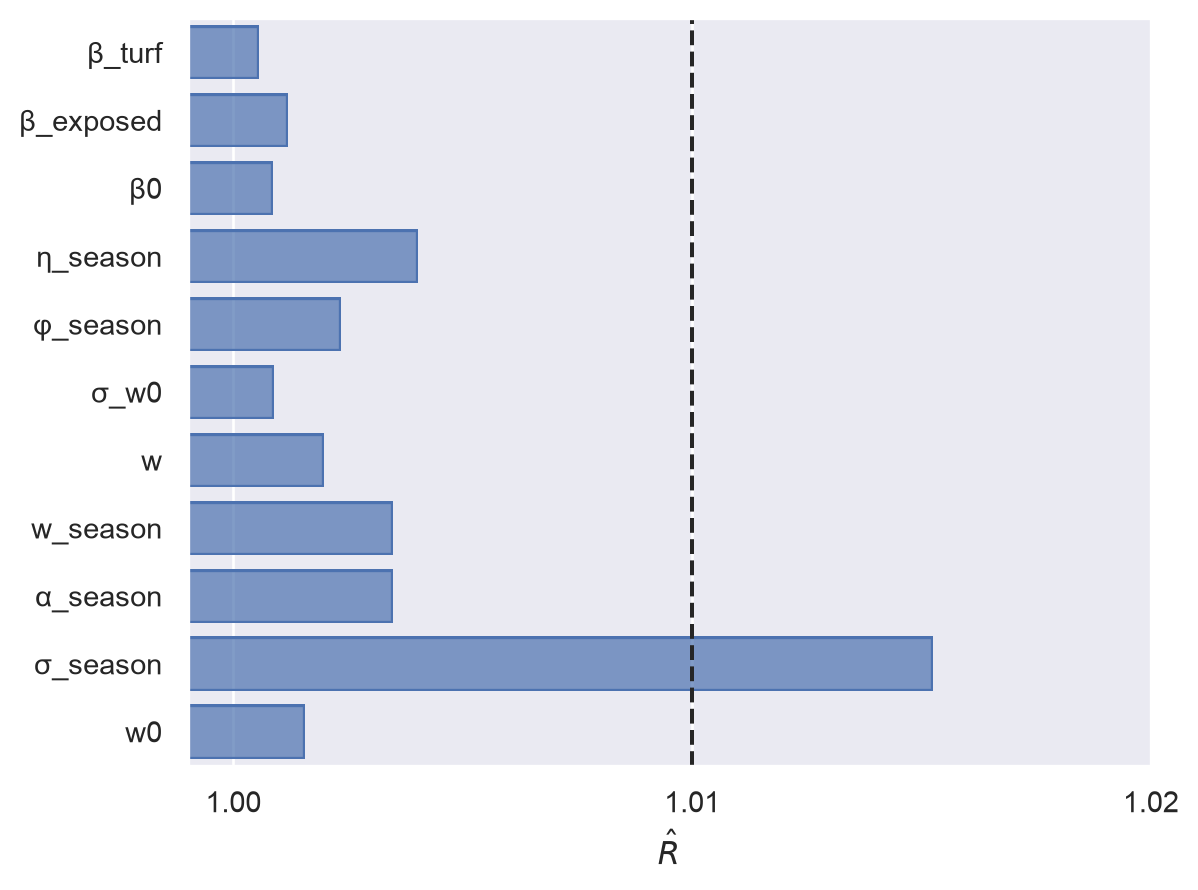

In [131]:
plot_rhat(traces["season"])

#### Residuals

We now compare this model's per-season binned residuals to those of the prior model.

In [132]:
fg_df = add_pred_resid("season", fg_df, traces["season"])

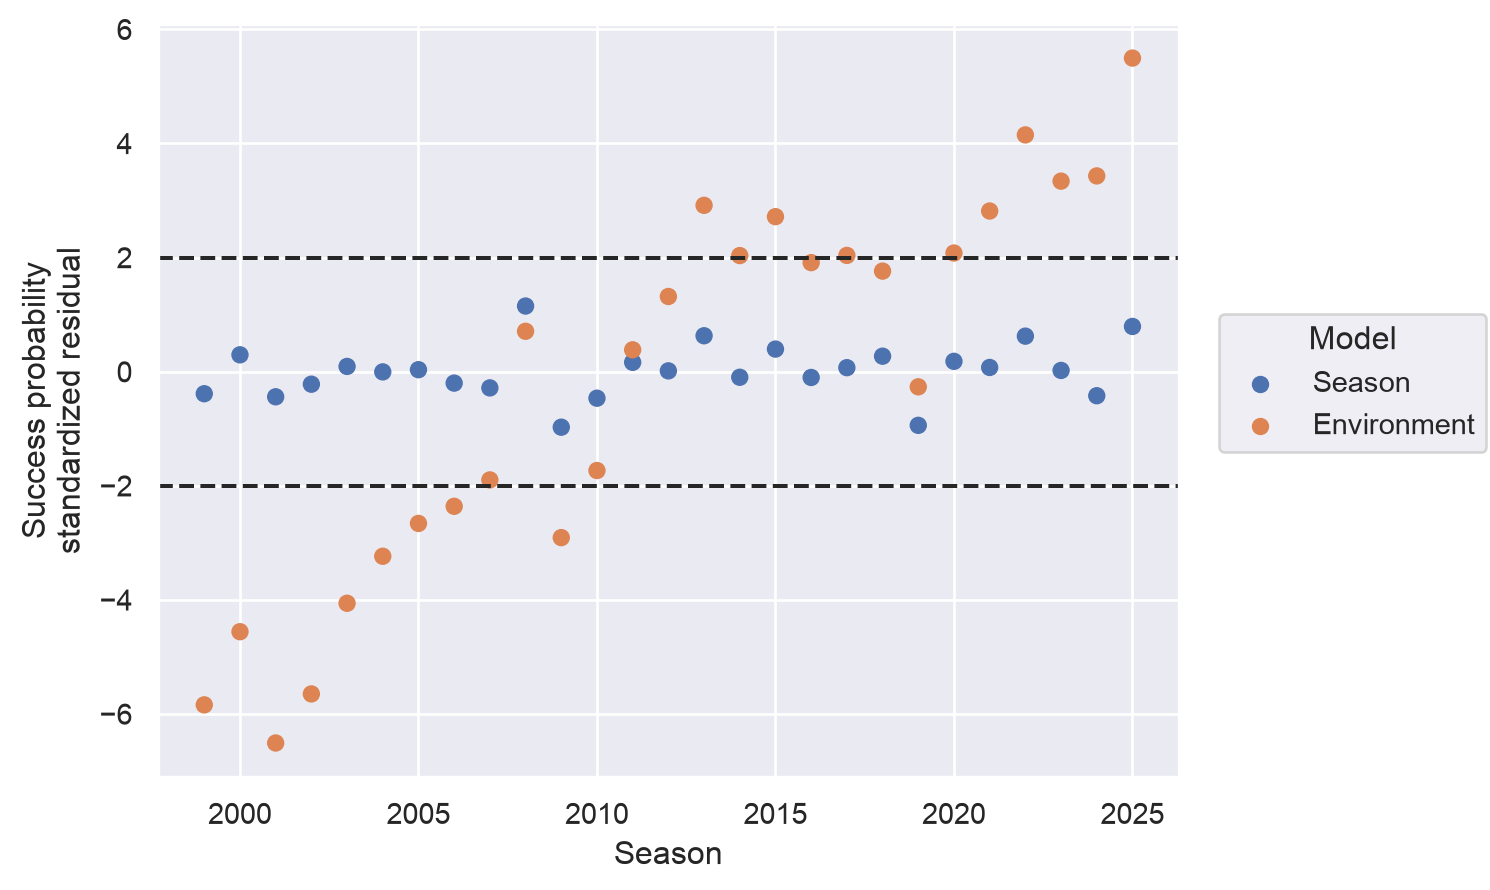

In [133]:
add_ax_lines(
    so.Plot(
        bin_resid("season", fg_df, by="season")
        .with_columns(season_to_int)
        .sort("season"),
        x="season",
        y="season_std_resid",
    )
    .add(so.Dot(), label="Season")
    .add(
        so.Dot(color="C1"),
        data=bin_resid("env", fg_df, by="season")
        .with_columns(season_to_int)
        .sort("season"),
        x="season",
        y="env_std_resid",
        label="Environment",
    )
    .scale(x=so.Continuous().tick(locator=SEASON_MAJOR_LOCATOR()))
    .label(x=SEASON_LABEL, y=STD_RESID_LABEL, legend="Model")
    .plot()
)

As hoped, we see that the relationship between season and residual has all but disappeared.

To motivate the next model, we plot the density of binned residuals over each stadium in our data.

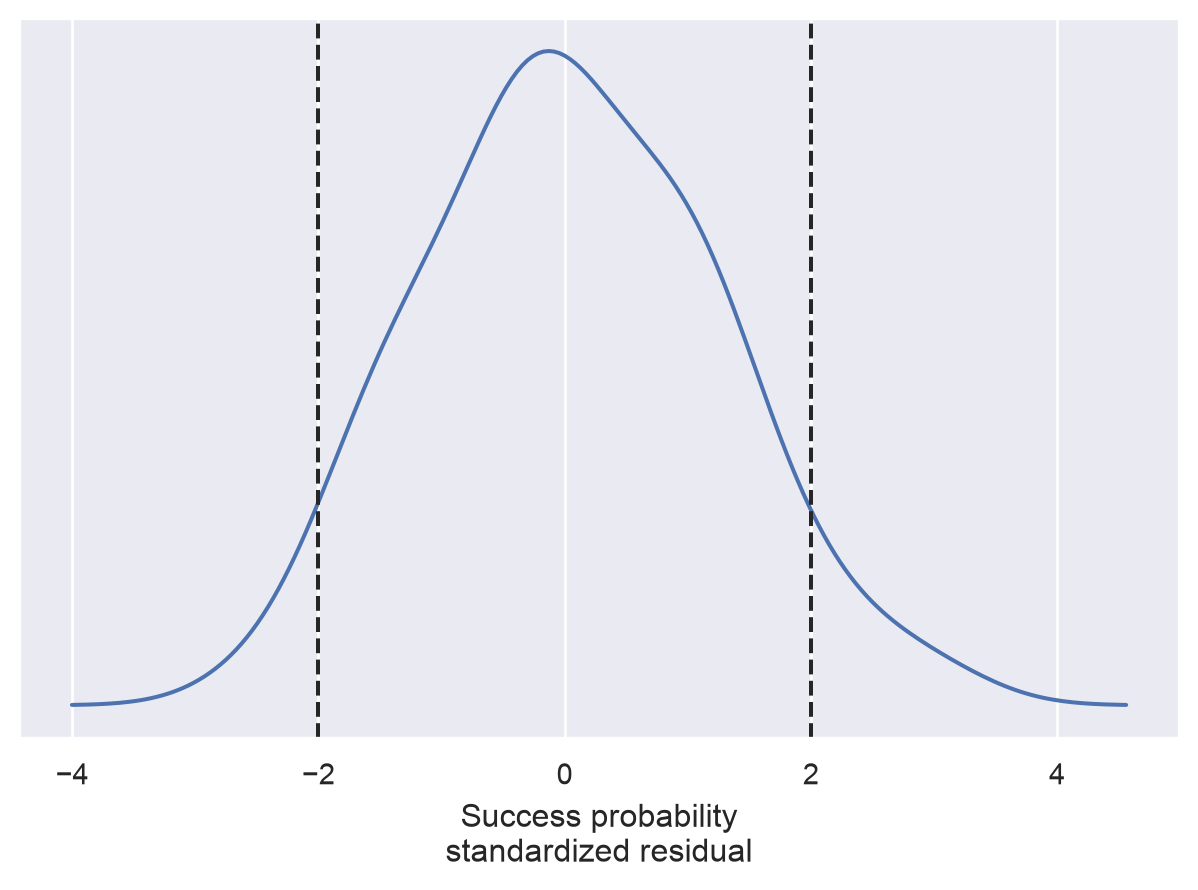

In [134]:
add_ax_lines(
    so.Plot(
        bin_resid("season", fg_df, by="stadium"),
        x="season_std_resid",
    )
    .add(so.Line(), so.KDE())
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=STD_RESID_LABEL)
    .plot(),
    horiz=False,
)

We will look to shrink the tails beyond $\pm 2$ in the next model.

We do not see any particular pattern in the binned residuals by elevation, so we do not expect the elevation coefficient to add much in our next model.

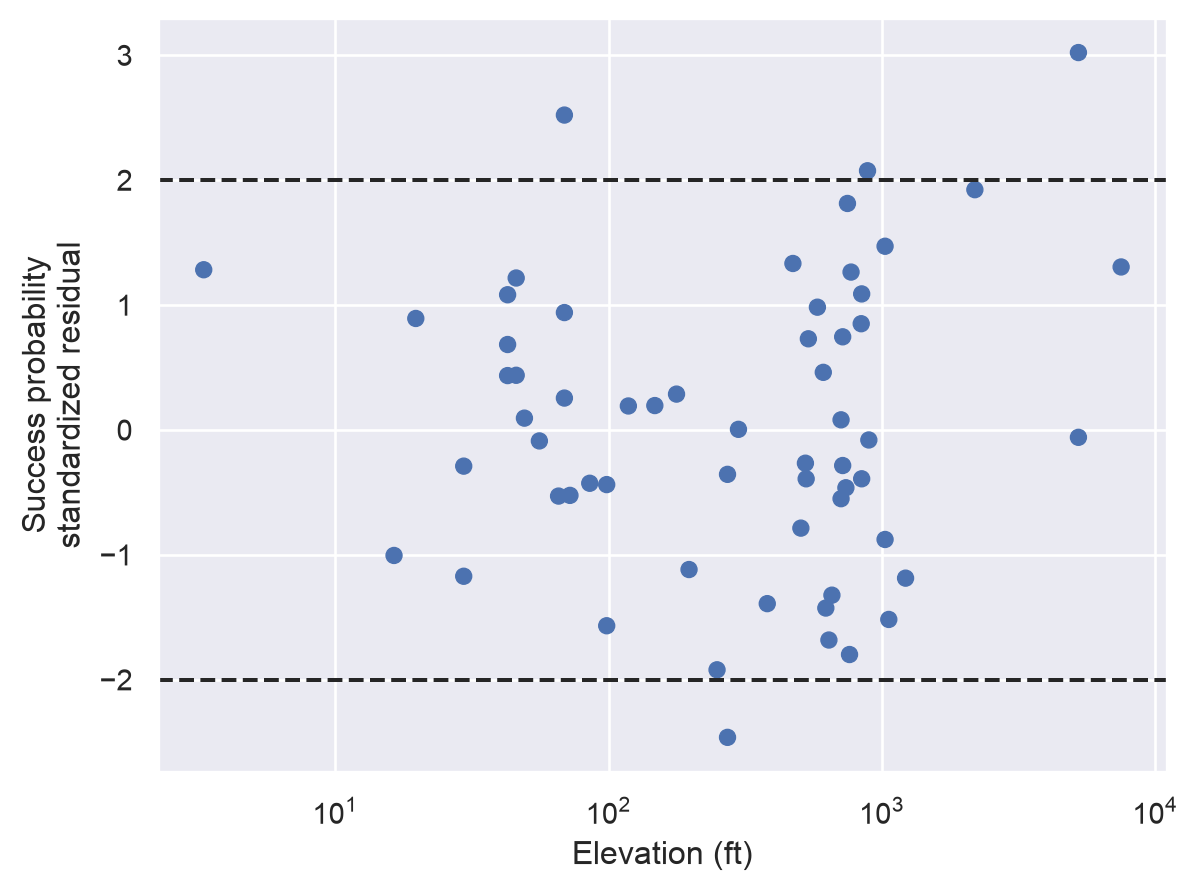

In [135]:
add_ax_lines(
    so.Plot(
        bin_resid("season", fg_df, by=["stadium", "elevation_ft"]),
        x="elevation_ft",
        y="season_std_resid",
    )
    .add(so.Dot())
    .scale(x=ELEV_SCALE)
    .label(x=ELEV_LABEL, y=STD_RESID_LABEL)
    .plot()
)

#### Model comparison

We now compare our four models using LOO-CV again.

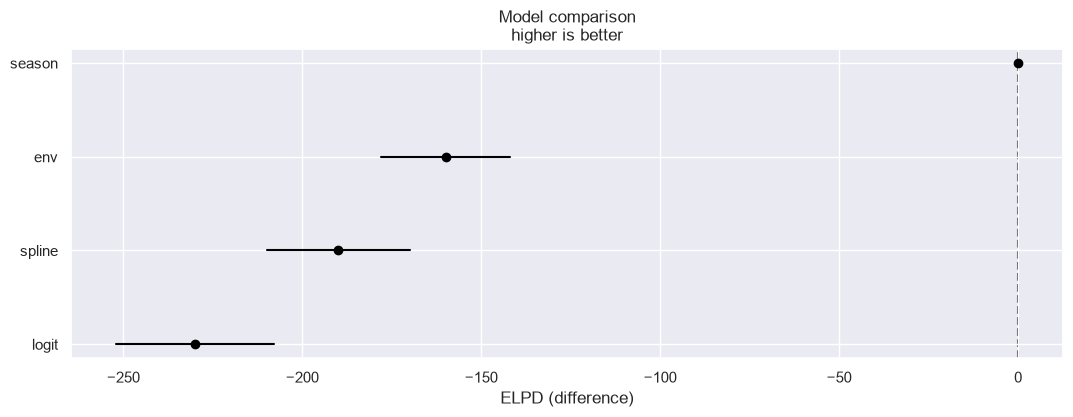

In [136]:
az.plot_compare(az.compare(loos));

We see that the season model is a substantial improvement in ELPD over each of the preceding models.

#### Predictions

Finally, we sample from the model's posterior predictive distribution to see how per-season success rate has changed over time.

In [137]:
pp_df = make_pp_df(
    PP_DIST_DATA,
    enum_cols(enums["season"], "season", enums["season"].categories),
    {"exposed": [True]},
    {"turf": [False]},
)

In [138]:
with season_model:
    set_data(pp_df)

    sample_posterior_predictive(
        traces["season"],
        coords=pp_df["dist", "season"].to_dict(as_series=False),
    )

Sampling: []


Output()

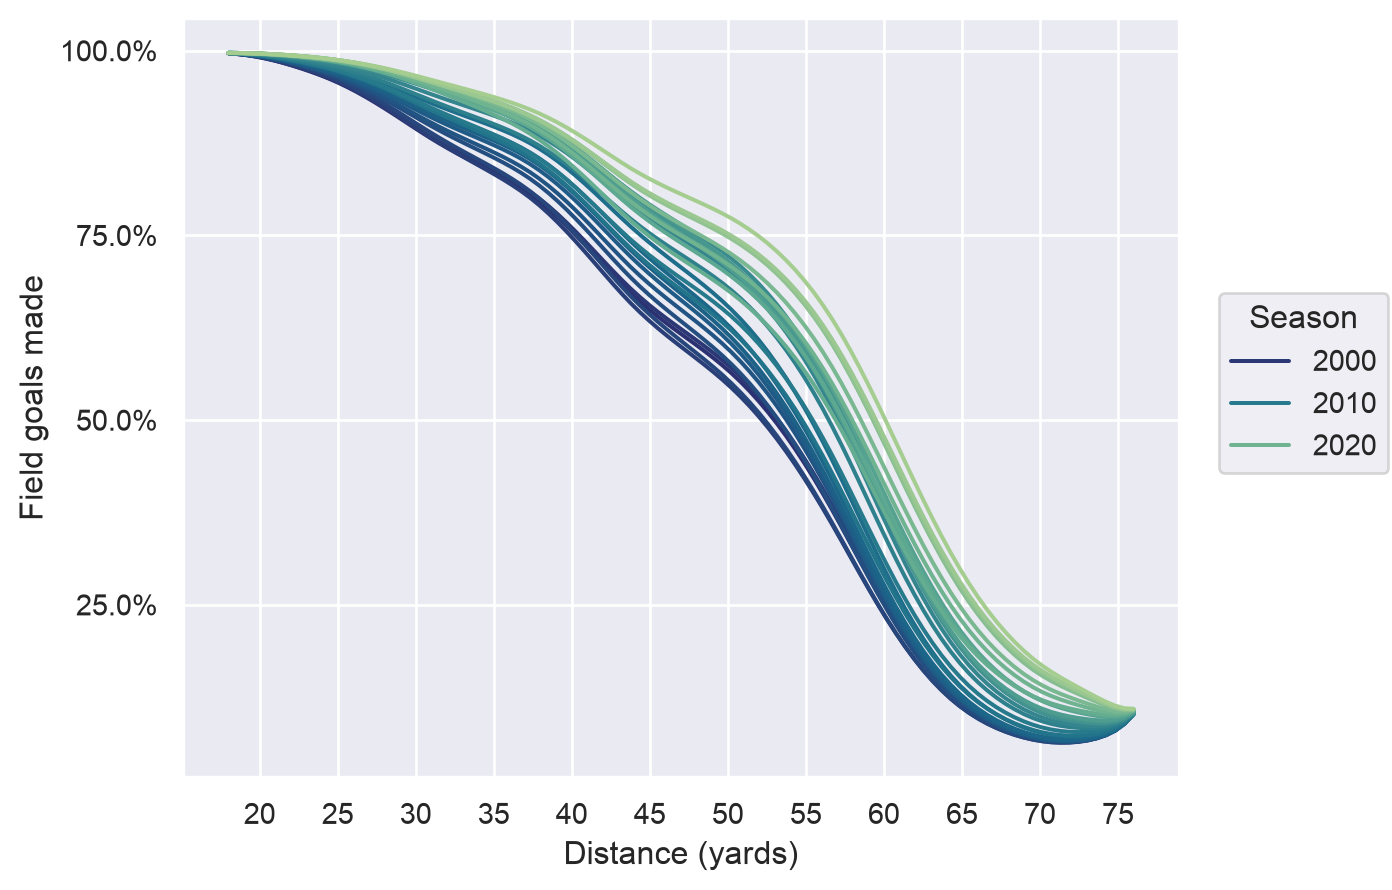

In [139]:
(
    so.Plot(
        traces["season"]
        .predictions.pipe(to_polars)
        .with_columns(pl.col("season").cast(pl.Int64)),
        x="dist",
        y="p_made",
        color="season",
    )
    .add(so.Line(), so.Agg())
    .scale(
        x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()),
        y=so.Continuous().tick(locator=PCT_LOCATOR()).label(formatter=PCT_FORMATTER()),
        color=so.Continuous("crest_r"),
    )
    .label(x=DIST_LABEL, y=MADE_LABEL, color="Season")
)

We see that outside of the shortest distances, success rates have increased substantially over the twenty-seven years present in our data.

The following plot specifically shows the difference in predicted success rate from the 1999 to 2025 seasons.  We see that the improvement in success rate increases steadily to between 55 and 60 yards, after which it declines, but still shows marked improvement.

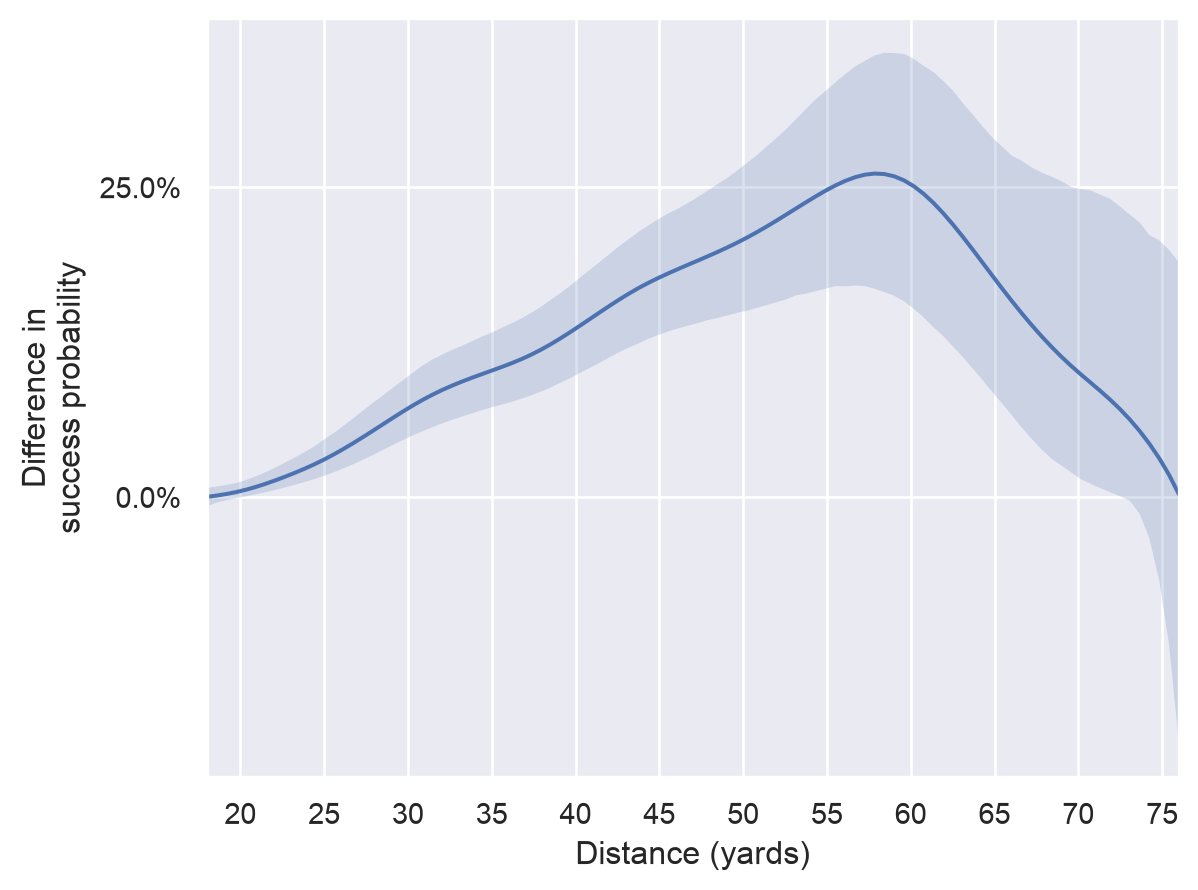

In [140]:
season_df = traces["season"].predictions.pipe(to_polars)
min_season, max_season = min(COORDS["season"]), max(COORDS["season"])

plot = so.Plot(
    season_df.filter(pl.col("season") == max_season)
    .join(
        season_df.filter(pl.col("season") == min_season),
        on=["chain", "draw", "dist"],
        suffix="_min",
    )
    .with_columns((pl.col("p_made") - pl.col("p_made_min")).alias("p_made")),
    x="dist",
    y="p_made",
)
plot = add_posterior_ev(plot)
plot_axis_ticks(
    plot.scale(x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()))
    .label(x=DIST_LABEL, y="Difference in\nsuccess probability")
    .limit(x=(PP_DIST.min(), PP_DIST.max())),
    y_locator=PCT_LOCATOR(),
    y_formatter=PCT_FORMATTER(),
)

### Stadium

We now add stadium and elevation factors to our model.  First we do some light data engineering.

In [141]:
COORDS["stadium"] = enums["stadium"].categories.to_list()
DATA["stadium_val"] = fg_df["stadium"].to_physical().to_numpy()

In [142]:
log_elev_scaler = make_1d_transform(
    stadium_df.unique("stadium")["elevation_ft"].log().to_numpy(), StandardScaler
)
DATA["log_elev_std"] = log_elev_scaler.transform(fg_df["elevation_ft"].log().to_numpy())

Much of the model remains the same, with the addition of a coefficient for (standardized log) elevation.

In [143]:
with pm.Model(coords=COORDS) as stadium_model:
    data = make_data(**DATA)

    coefs = make_coefs("β0", "β_exposed", "β_turf", "β_elev")

    w0 = dist_spline_coef("w0")
    w_season = deviation_coef("season", season_basis)

    w = pm.Deterministic("w", w0 + w_season, dims=("season", "dist_basis"))
    f_dist = (data["dist_basis_val"] * w[data["season_val"]]).sum(axis=1)

For stadium-specific effects, we use a zero-mean hierarchical normal distribution with a [non-centered parameterization](https://mc-stan.org/docs/2_29/stan-users-guide/reparameterization.html#non-centered-parameterization),

$$
\begin{align*}
    \sigma_{\text{stadium}}
        & \sim \text{Half-}N(0, 2.5^2) \\
    \beta_{\text{stadium}, j}
        & \sim N(0, \sigma_{\text{stadium}}^2).
\end{align*}
$$

In [144]:
def hierarchical_normal(name, *, μ=None, dims):
    if μ is None:
        μ = pm.Normal(f"μ_{name}", 0, 2.5)

    Δ = pm.Normal(f"Δ_{name}", 0, 1, dims=dims)
    σ = pm.HalfNormal(f"σ_{name}", 2.5)

    return pm.Deterministic(name, μ + Δ * σ, dims=dims)

In [145]:
with stadium_model:
    coefs["β_stadium"] = hierarchical_normal("β_stadium", μ=0, dims="stadium")

Finally, the linear predictor is defined as

$$\eta_i = \beta_0 + \beta_{\text{exposed}} \cdot x_{\text{exposed}, i} + \beta_{\text{turf}} \cdot x_{\text{turf}, i} + \beta_{\text{stadium}, j(i)} + \beta_{\text{elev}} \cdot x_{\text{elev}, i} + f(x_{\text{dist}, i}),$$

where $j(i)$ is the index of the stadium the $i$-th kick took place in.  The rest of the model is defined as above.

In [146]:
with stadium_model:
    # fmt: off
    η = sum([
        coefs["β0"],
        coefs["β_elev"] * data["log_elev_std"],
        coefs["β_exposed"] * data["exposed"],
        coefs["β_turf"] * data["turf"],
        coefs["β_stadium"][data["stadium_val"]],
        f_dist
    ])
    # fmt: on
    p_made = pm.Deterministic("p_made", pm.math.sigmoid(η), dims="obs")

    pm.Bernoulli("made_obs", p_made, observed=data["made"], dims="obs")

We now sample from this model's posterior distribution.

In [147]:
traces["stadium"], loos["stadium"] = sample(stadium_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.10,63
,1400,0,0.12,95
,1400,0,0.13,255
,1400,0,0.11,127
,1400,0,0.13,63
,1400,0,0.12,127


The $\hat{R}$ statistic for $\sigma_{\text{season}}$ is high, but will come down in future models.

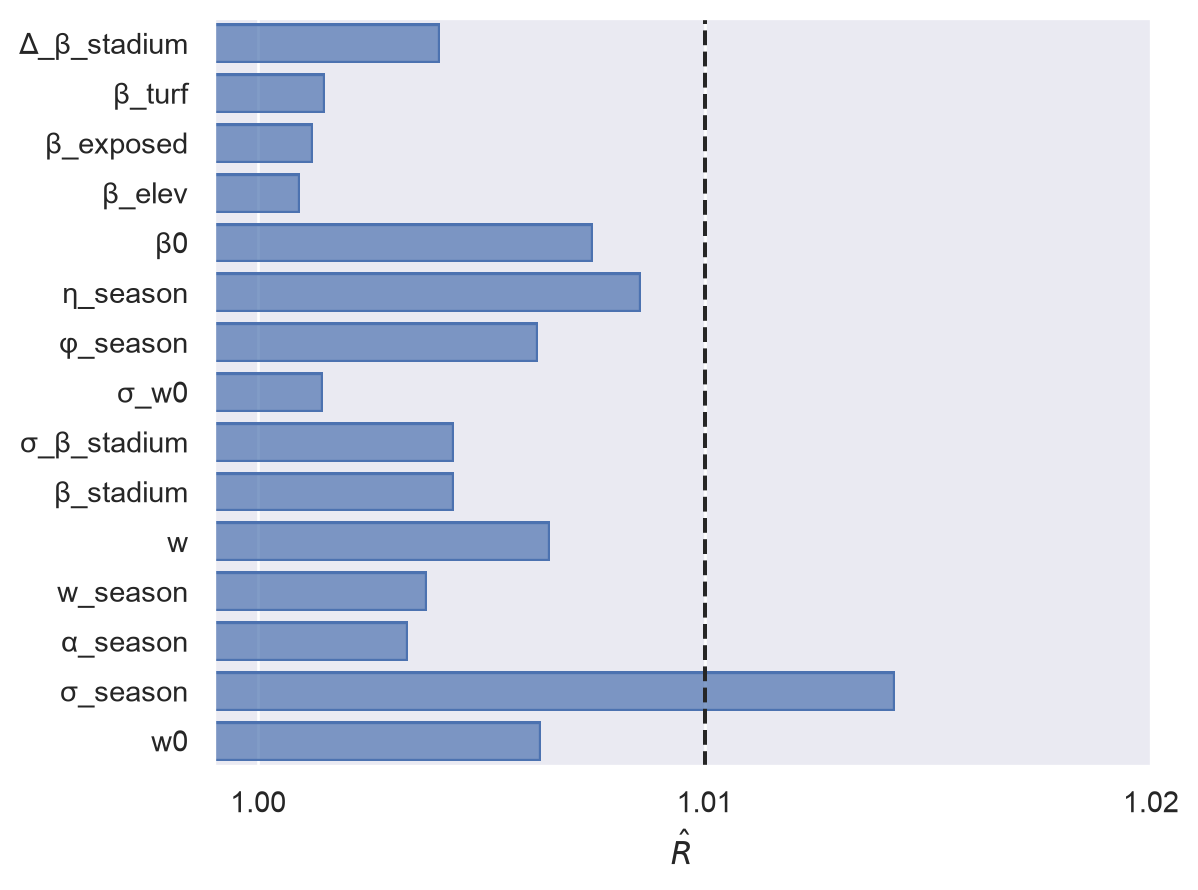

In [148]:
plot_rhat(traces["stadium"])

#### Residuals

Examining the binned residuals, we see that the per-stadium residuals are now indeed much more concentrated inside $\pm 2$.

In [149]:
fg_df = add_pred_resid("stadium", fg_df, traces["stadium"])

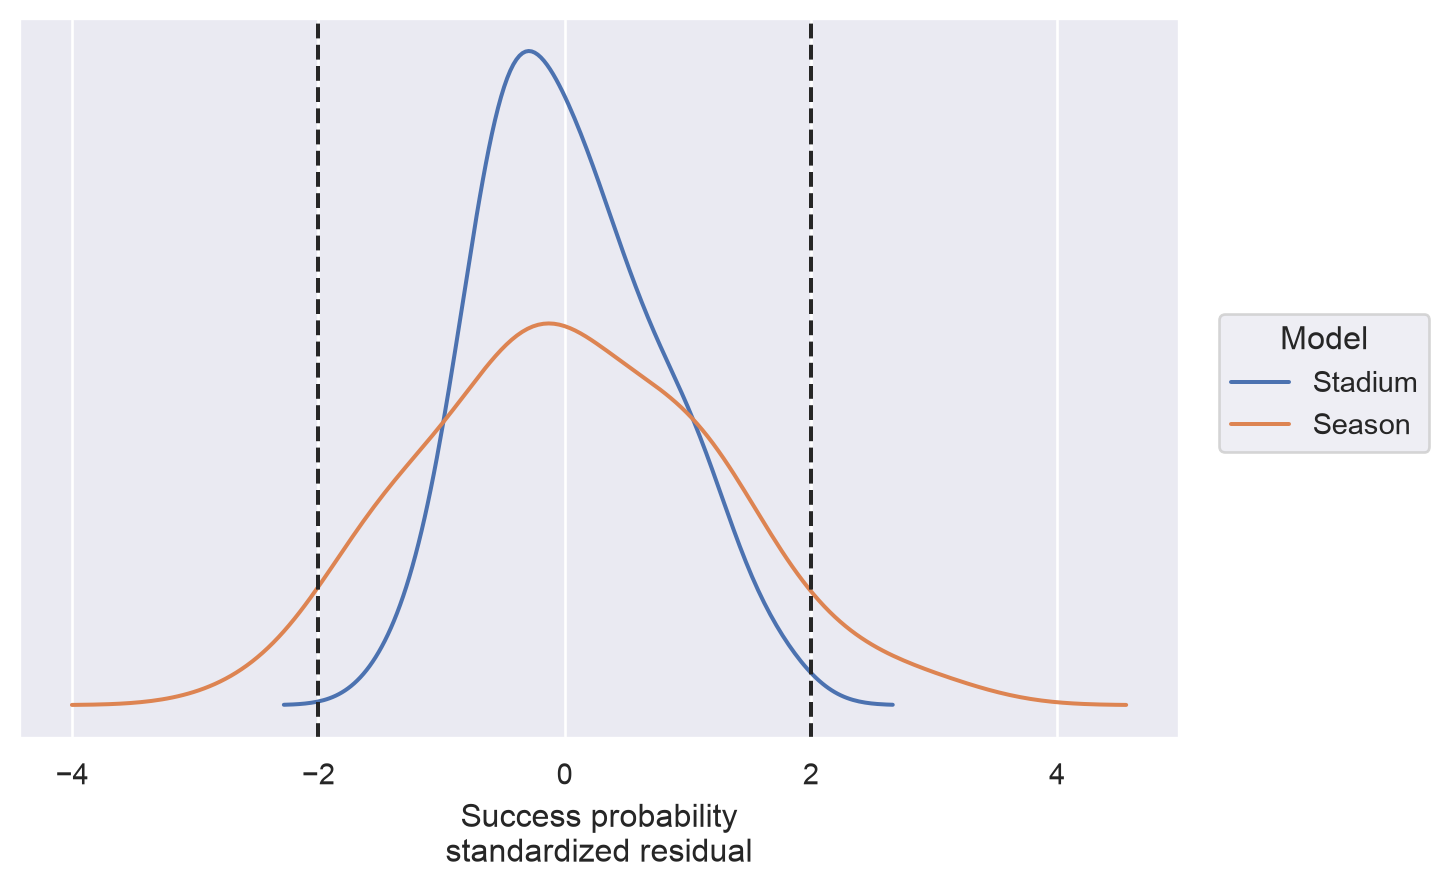

In [150]:
add_ax_lines(
    so.Plot(
        bin_resid("stadium", fg_df, by="stadium"),
        x="stadium_std_resid",
    )
    .add(so.Line(), so.KDE(), label="Stadium")
    .add(
        so.Line(color="C1"),
        so.KDE(),
        data=bin_resid("season", fg_df, by="stadium"),
        x="season_std_resid",
        label="Season",
    )
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=STD_RESID_LABEL, legend="Model")
    .plot(),
    horiz=False,
)

The binned residuals broken down by whether the kicker was iced show no obvious pattern, though this may be due to class imbalance, as relatively few kicks are iced.  We will explore the impact of icing the kicker more in the next and final model of this post.

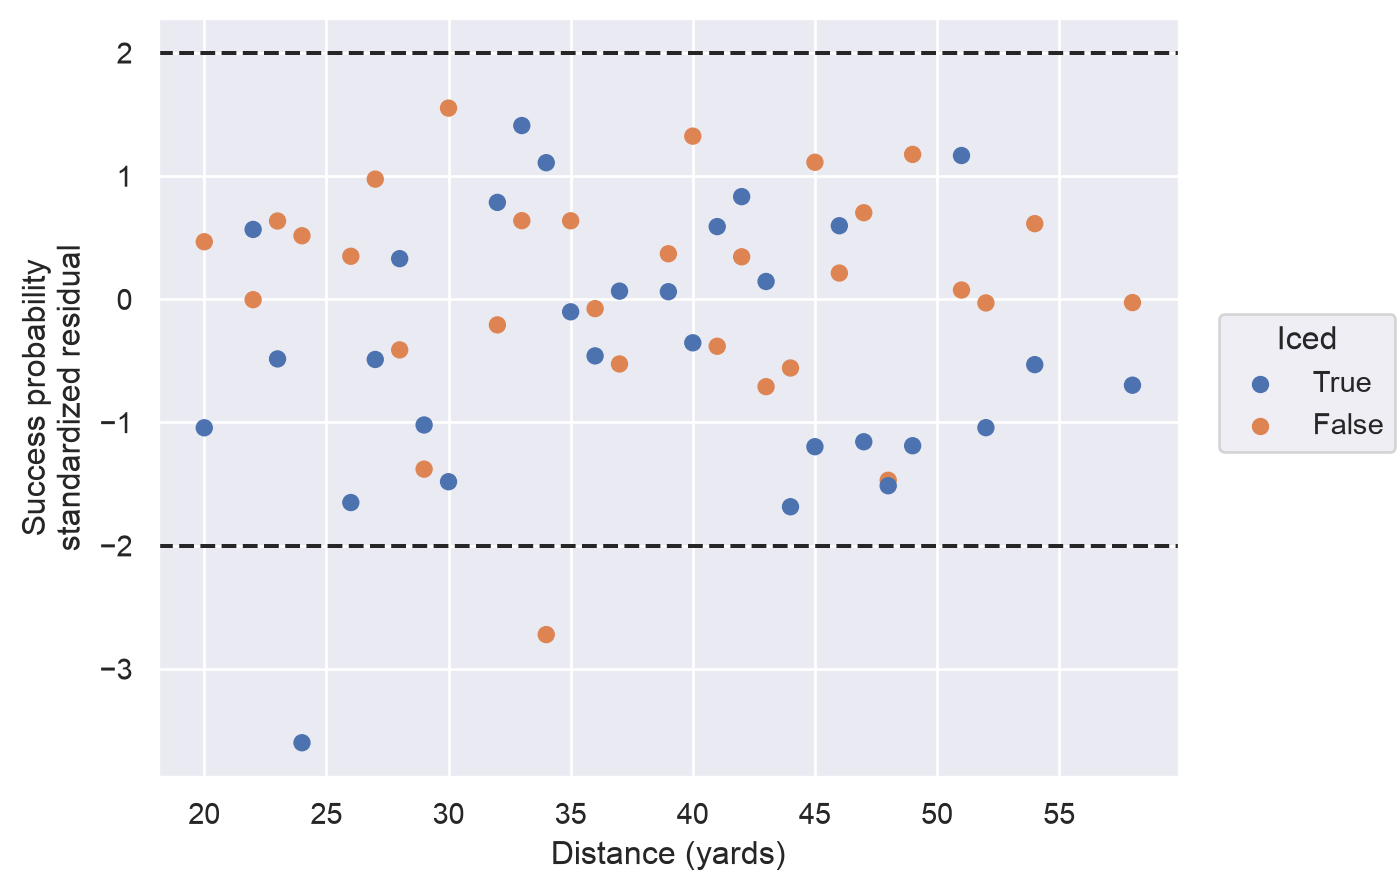

In [151]:
plot_std_resid("stadium", fg_df, color="iced", color_label="Iced")

#### Model comparison

We now compare our five models using LOO-CV again.

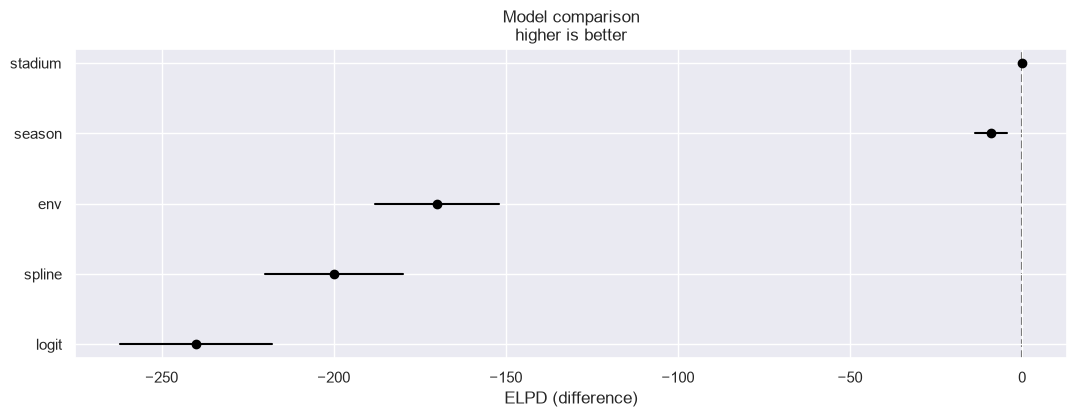

In [152]:
az.plot_compare(az.compare(loos));

We see that the stadium model is a slight improvement in ELPD over the season model.

#### Interpretation

Visualizing the posterior distribution of $\beta_{\text{elev}}$, we see that its posterior expected value is 0.01 and that zero is well within its 95% credible interval.

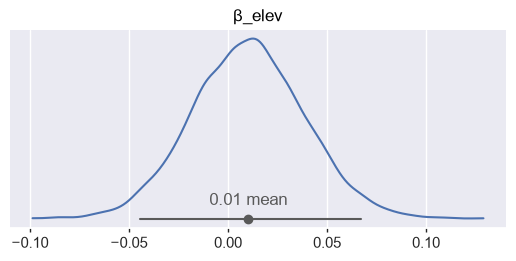

In [153]:
az.plot_dist(traces["stadium"], var_names="β_elev", ci_prob=0.95);

Plotting each stadium's random effect alongside its (log) elevation also shows no discernible pattern.

In [154]:
β_stadium_ev = traces["stadium"].posterior["β_stadium"].mean(dim=("chain", "draw"))

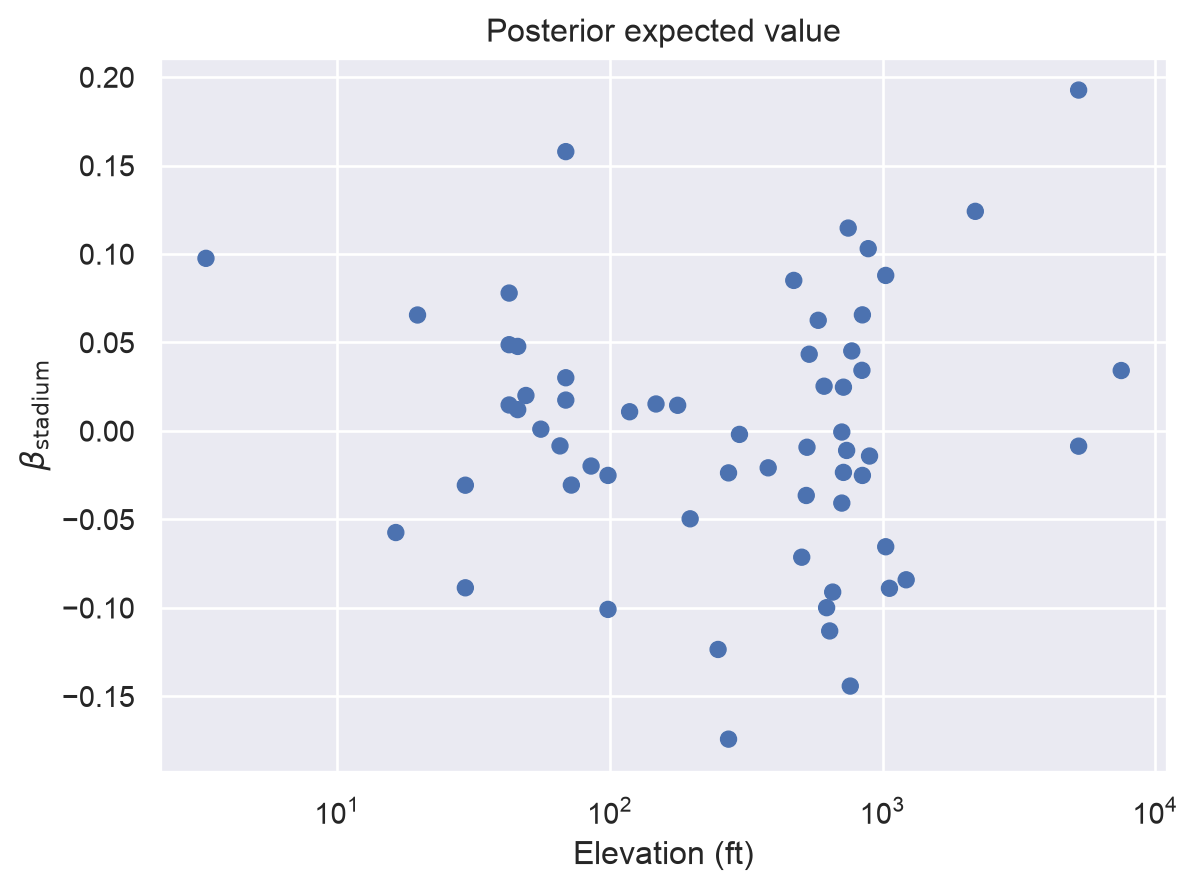

In [155]:
(
    so.Plot(
        β_stadium_ev.pipe(to_polars).join(stadium_df.unique("stadium"), on="stadium"),
        x="elevation_ft",
        y="β_stadium",
    )
    .add(so.Dot())
    .scale(x=ELEV_SCALE)
    .label(
        x=ELEV_LABEL, y=r"$\beta_{\text{stadium}}$", title="Posterior expected value"
    )
)

We therefore conclude that, unlike for home runs in baseball, there is no beneficial effect of stadium elevation on NFL placekicking.

We now visualize the top and bottom five stadiums by their random effect.

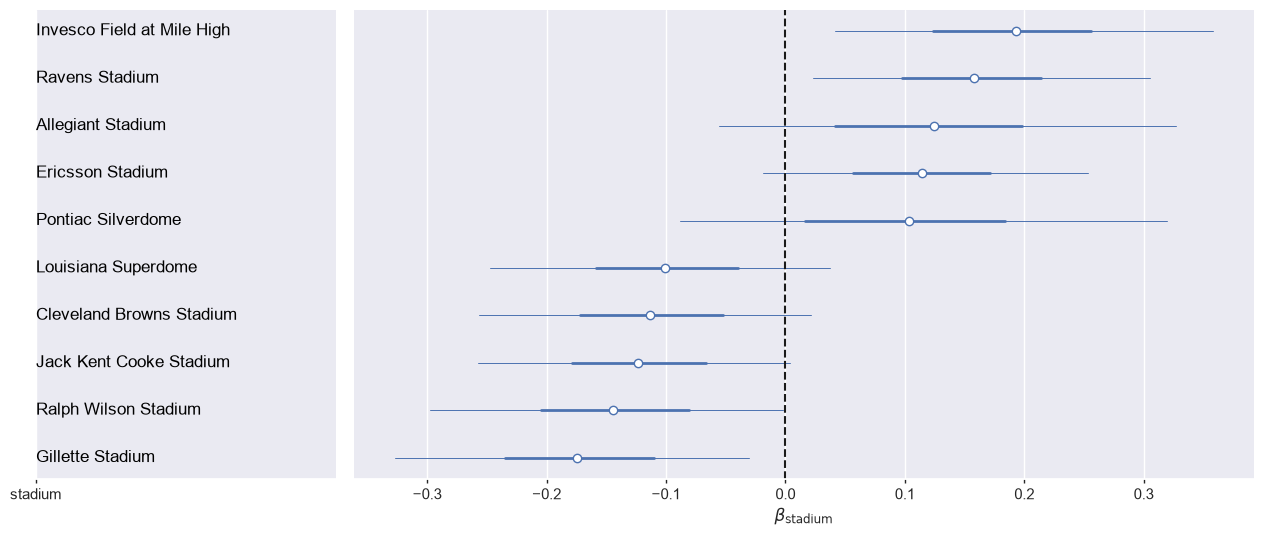

In [156]:
stadium_vals_sorted = β_stadium_ev.argsort().to_numpy()
stadiums_sorted = enums["stadium"].categories[stadium_vals_sorted]
plot_stadiums = pl.concat(
    [stadiums_sorted.head(5), stadiums_sorted.tail(5)]
).to_numpy()[::-1]

pc = az.plot_forest(
    traces["stadium"],
    var_names="β_stadium",
    coords={"stadium": plot_stadiums},
    combined=True,
    labels=["stadium"],
)

ax = pc.viz["plot"][1].item()
ax.axvline(0, c="k", ls="--")
ax.set_xlabel(r"$\beta_{\text{stadium}}$")
ax.figure.tight_layout()

We see that only three stadiums show clean separation from zero.  Interestingly, Invesco Field at Mile High has the highest random effect even though elevation shows no broad effect.  Looking at kick counts by elevation, altitude may well matter there, but no other comparably high stadium has enough kicks for the model to separate elevation from the stadium effects.

In [157]:
fg_df.group_by("stadium", "elevation_ft").len().sort(
    "elevation_ft", descending=True
).head()

stadium,elevation_ft,len
enum,f64,u32
"""Azteca Stadium""",7503.3,19
"""Invesco Field at Mile High""",5236.2,822
"""Mile High Stadium""",5236.2,61
"""Allegiant Stadium""",2188.3,218
"""Sun Devil Stadium""",1220.5,201


#### Predictions

We now visualize the difference in success rate between the stadiums with the largest and smallest random effects.

In [158]:
pp_df = make_pp_df(
    PP_DIST_DATA,
    enum_cols(enums["season"], "season", [enums["season"].categories[-1]]),
    {"exposed": [True]},
    {"turf": [False]},
    {"log_elev_std": [0.0]},
    enum_cols(enums["stadium"], "stadium", stadiums_sorted[[0, -1]]),
)

In [159]:
with stadium_model:
    set_data(pp_df)

    sample_posterior_predictive(
        traces["stadium"],
        coords=pp_df["dist", "stadium"].to_dict(as_series=False),
    )

Sampling: []


Output()

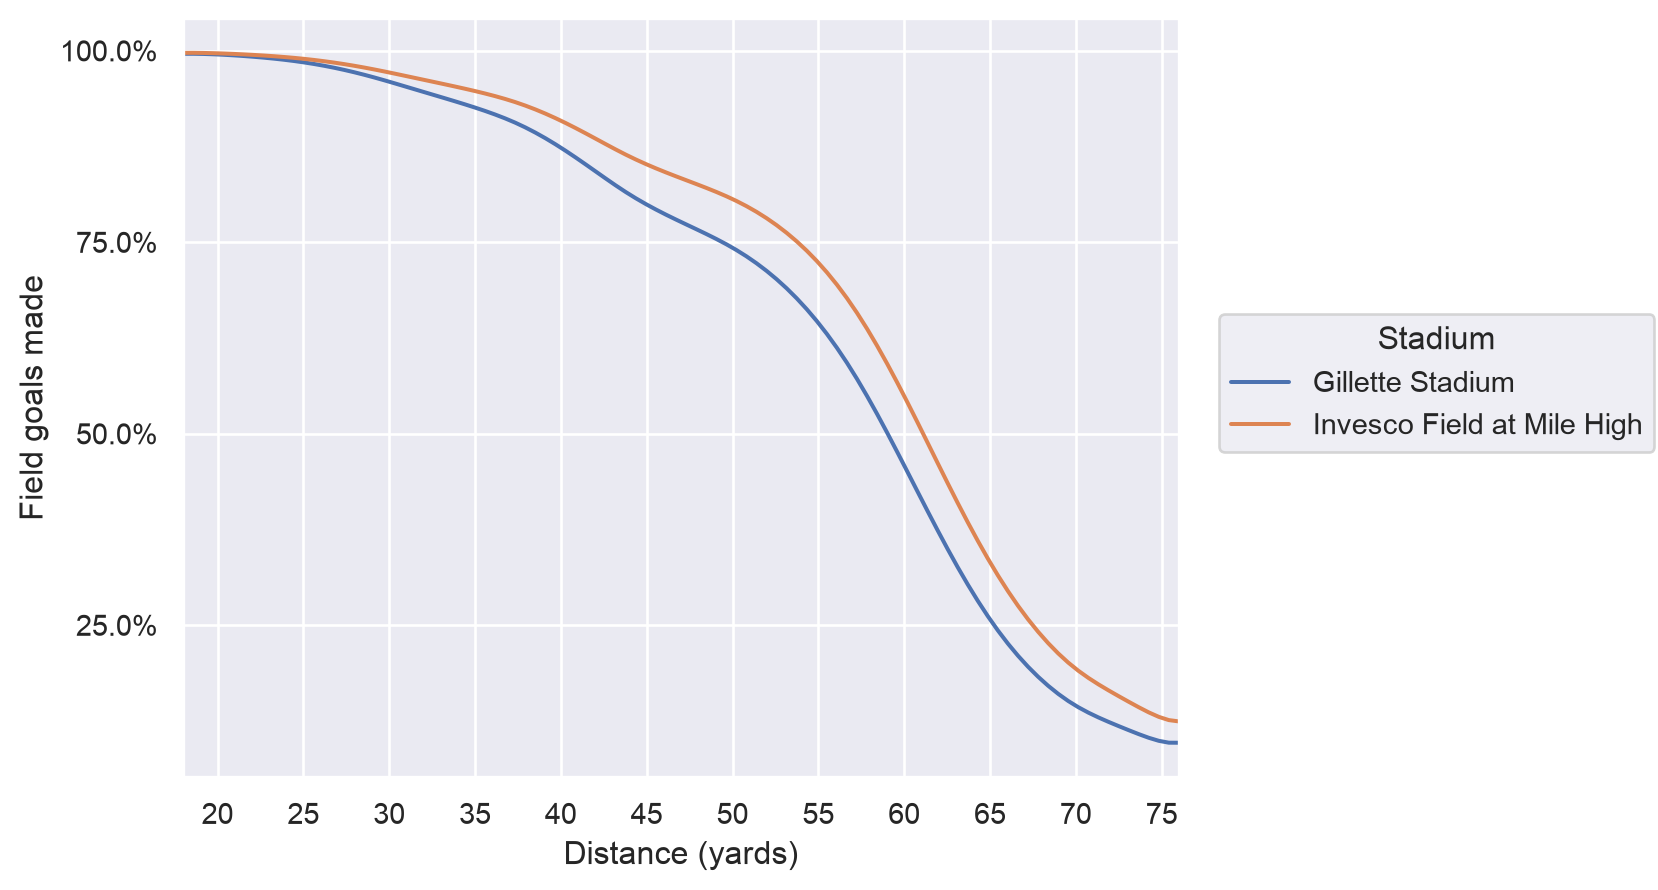

In [160]:
(
    so.Plot(
        traces["stadium"].predictions.pipe(to_polars),
        x="dist",
        y="p_made",
        color="stadium",
    )
    .add(so.Line(), so.Agg())
    .scale(
        x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()),
        y=so.Continuous().tick(locator=PCT_LOCATOR()).label(formatter=PCT_FORMATTER()),
    )
    .limit(x=(PP_DIST.min(), PP_DIST.max()))
    .label(x=DIST_LABEL, y=MADE_LABEL, color="Stadium")
)

We see that there is only a modest difference in the success rates between Gillette Stadium and Invesco Field at Mile High.

### Icing the kicker

Finally, we will investigate whether or not icing the kicker matters.  Since $\beta_{\text{elev}}$ did not make much of a difference in the last model, we will leave it out of this one.  All other elements of the last model remain, and we add a binary indicator for whether or not the kicker was iced, with coefficient

$$\beta_{\text{iced}} \sim N(0, 2.5^2).$$

In [161]:
DATA["iced"] = fg_df["iced"].to_numpy()

We also add a binary flag that will allow us to turn off the stadium effect when making predictions (essentially making predictions for the average stadium).

In [162]:
DATA["use_stadium"] = np.full(len(fg_df), True)

In [163]:
with pm.Model(coords=COORDS) as iced_model:
    data = make_data(**DATA)

    coefs = make_coefs("β0", "β_exposed", "β_turf", "β_iced")
    coefs["β_stadium"] = hierarchical_normal("β_stadium", μ=0, dims="stadium")

    w0 = dist_spline_coef("w0")
    w_season = deviation_coef("season", season_basis)

    w = pm.Deterministic("w", w0 + w_season, dims=("season", "dist_basis"))
    f_dist = (data["dist_basis_val"] * w[data["season_val"]]).sum(axis=1)

    # fmt: off
    η = sum([
        coefs["β0"],
        coefs["β_exposed"] * data["exposed"],
        coefs["β_iced"] * data["iced"],
        coefs["β_turf"] * data["turf"],
        data["use_stadium"] * coefs["β_stadium"][data["stadium_val"]],
        f_dist
    ])
    # fmt: on
    p_made = pm.Deterministic("p_made", pm.math.sigmoid(η), dims="obs")

    pm.Bernoulli("made_obs", p_made, observed=data["made"], dims="obs")

We now sample from the model's posterior distribution.

In [164]:
traces["iced"], loos["iced"] = sample(iced_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.13,447
,1400,0,0.12,191
,1400,0,0.12,95
,1400,0,0.11,191
,1400,0,0.11,31
,1400,0,0.12,191


The $\hat{R}$ value for $\sigma_{\text{season}}$ is slightly elevated, but it is not high enough to cause real concern.

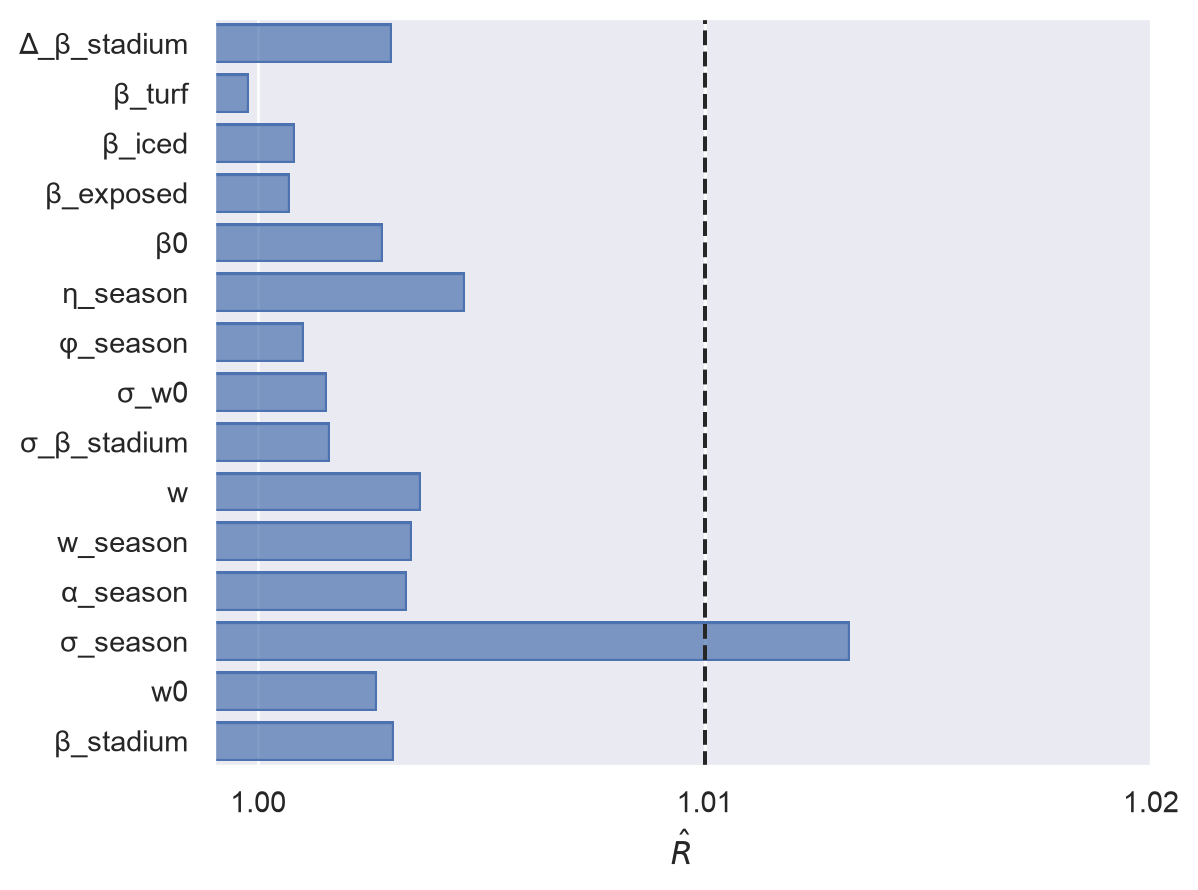

In [165]:
plot_rhat(traces["iced"])

#### Model comparison

We now compare all of our models using LOO-CV again.

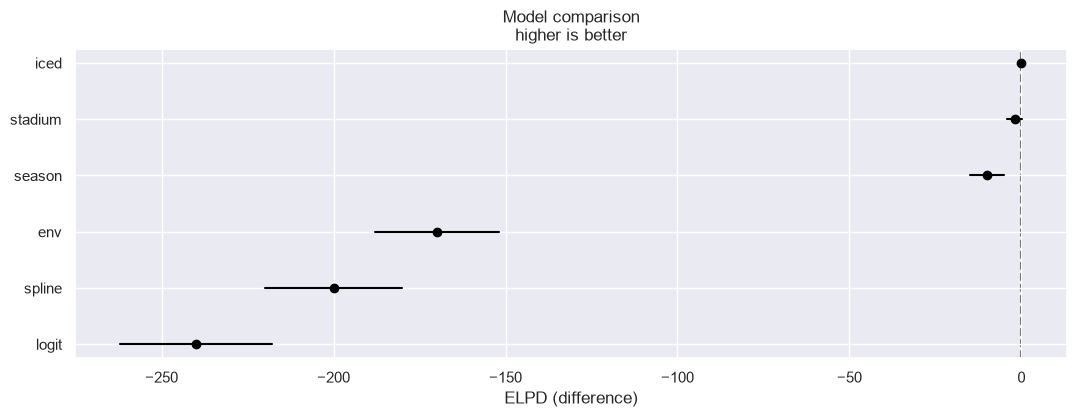

In [166]:
az.plot_compare(az.compare(loos));

We see that the final model, including a factor for icing the kicker, has a slightly better ELPD than the previous stadium model.

#### Interpretation

Visualizing the posterior distribution of $\beta_{\text{iced}}$, we see that its 95% credible interval just excludes zero, providing some evidence of an iced kicker effect.

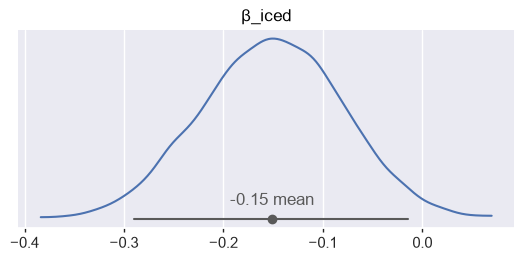

In [167]:
az.plot_dist(traces["iced"], var_names="β_iced", ci_prob=0.95);

#### Predictions

To visualize the magnitude of this effect, we sample from the model's posterior predictive distribution.

In [168]:
pp_df = make_pp_df(
    PP_DIST_DATA,
    enum_cols(enums["season"], "season", [enums["season"].categories[-1]]),
    {"exposed": [True]},
    {"turf": [False]},
    enum_cols(enums["stadium"], "stadium", [enums["stadium"].categories[0]]),
    {"use_stadium": [False]},
    {"iced": [False, True]},
)

In [169]:
with iced_model:
    set_data(pp_df)

    sample_posterior_predictive(
        traces["iced"],
        coords=pp_df["dist", "iced"].to_dict(as_series=False),
    )

Sampling: []


Output()

Now we visualize the difference in success probabilities between uniced and iced kicks.

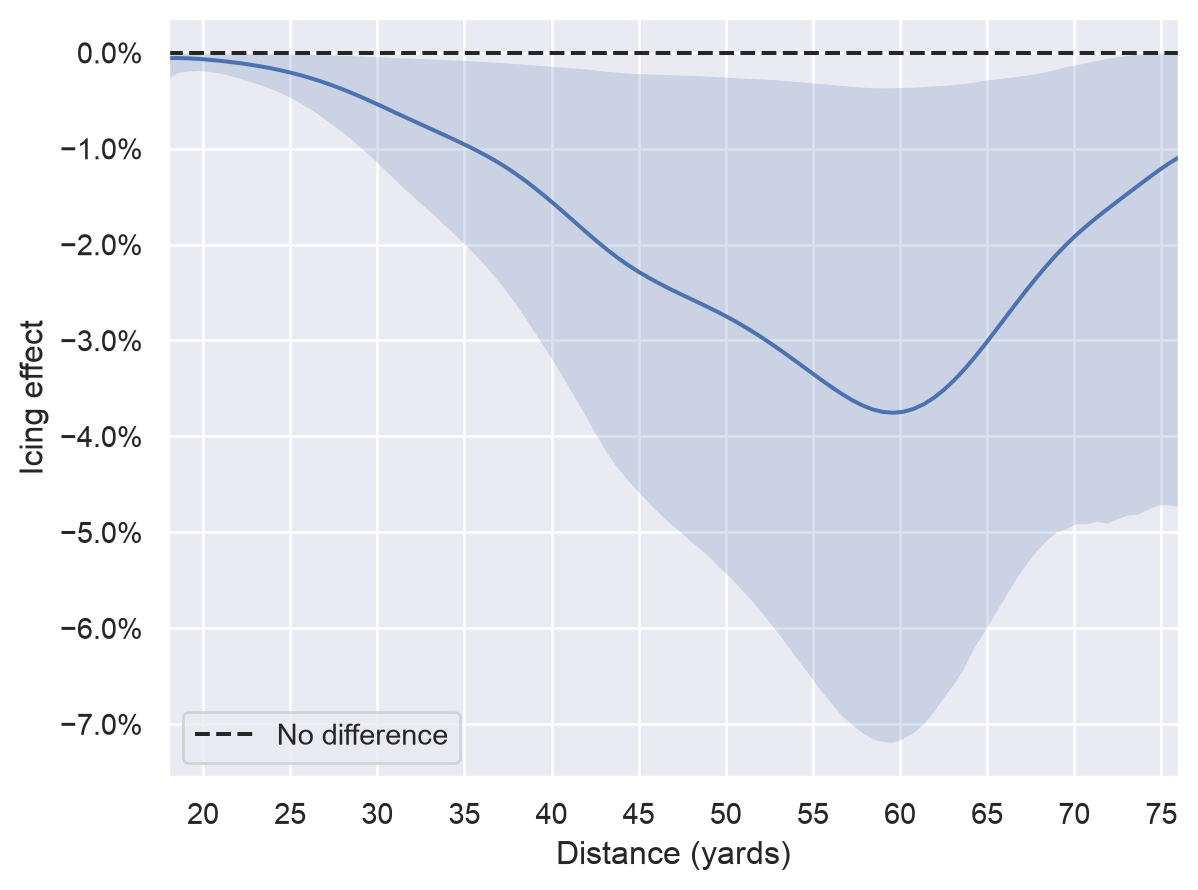

In [170]:
plot = so.Plot(
    traces["iced"]
    .predictions.pipe(to_polars)
    .pivot(index=["chain", "draw", "dist"], on="iced")
    .with_columns(diff=pl.col("true") - pl.col("false")),
    x="dist",
    y="diff",
)
plot = plot_axis_ticks(
    add_posterior_ev(plot)
    .scale(x=so.Continuous().tick(locator=DIST_MAJOR_LOCATOR()))
    .limit(x=(PP_DIST.min(), PP_DIST.max()))
    .label(x=DIST_LABEL, y="Icing effect"),
    y_formatter=PCT_FORMATTER(),
)

ax = plot_ax(plot)
ax.axhline(0, c="k", ls="--", label="No difference")
ax.legend()

plot

We see evidence of a small icing-the-kicker effect.

## Conclusion

Throughout this post we have identified the situational and environmental factors that impact field goal success. Our next post will use this model as a basis for building an item-response model of placekicker skill.

This post is available as a Jupyter notebook [here](https://github.com/AustinRochford/blog-nikola/blob/master/posts/bayes_fg.ipynb).

**AI usage transparency:** I have used various AI models to refine, simplify, and validate some of the mathematics and modeling in this post. I have also used AI to check spelling and grammar for correctness and quality. However, AI has not directly created, changed, or edited any of the prose in this post. It started with my writing and all AI suggestions were reviewed and incorporated manually by me.  Some of the code in this post was generated by AI.

In [171]:
%load_ext watermark
%watermark -n -u -v -iv

Last updated: Sun, 06 Sep 2026

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.1

arviz      : 1.3.0
humanize   : 4.16.0
logging    : 0.5.1.2
matplotlib : 3.11.1
nflreadpy  : 0.1.5
numpy      : 2.4.6
nutpie     : 0.16.11
polars     : 1.44.1
preliz     : 0.27.1
pymc       : 6.2.0
pymc_extras: 0.14.0
seaborn    : 0.13.2
sklearn    : 1.9.0
toolz      : 1.1.0

